## Matched filtering for tau



- test beam asymmetry error: convolve map with gaussian beam (known) -> add noise -> deconvolve and see the difference with the original singal, how well I can recover it. // convolve map with realistic beam  -> add noise ->  deconvolve with symmetrized beam (get the Cls from the beam map and use smoothing). How to add noise: we know that reasonably $\sigma_{N_1} = 20 \mu k \,\,1 arcmin$. We can then rescale it using the relation $\sigma_N\propto 1/\sqrt{N_{pix}}$ and get teh value for the pixel size of the map $\sigma_{N_{side}}^2= \sigma_{N_1}^2 (\Delta\Omega_{pix}/\Delta\Omega_{1})$. Then the noise map is an array of random variables with mean=0 and sigma=$\sigma_{N_{side}}$ with len=number of pixels (better method). Note: $\Delta\Omega$ should be in steradians. Another way is generating the angular power spectrum of the noise: $C_\ell^N = \sigma^2_N\Delta\Omega_{N}$. Cls noise should be of order $10^{-7}$ and constant, plus we should have. 
- recover tau with match filtering in both cases



-- modify CLASS/CAMB?



derive tau from the alms of the theoreticcal maps to see if it goes to zero


Test beam asymmetry error: convolve map with gaussian beam (known) -> add noise -> deconvolve and see the difference with the original singal, how well I can recover it. // convolve map with realistic beam  -> add noise ->  deconvolve with symmetrized beam (get the Cls from the beam map and use smoothing).


plot beam map from its Cls --> see symmetric beam


TO DO: 
- determine l_min, l_max for matched filtering: see when the ideal result becomes biased 
- need to repeat convolution without tau signal ??
- see if I manage to account for beam residuals in the map difference from 1) cross Cls 2) difference map
- Analytical computation to explain of: 1) Cls of difference map beam residuals 2) Cross Cls going to match filter, to see which systematics remain (some beam residuals should still correlate but not all)  ######divide difference map by Cls CMB --> shoudl find the auto power spectrum of beam errors
- Noise subtraction: try with matched filtering.  subtract noise from Cls_cross with matched filtering 
- later: think about a method to quantify the beam assimmetry and connect beam residuals to it --> would allow to estimate beam residuals and subtract them


I'm afraid that with deconvolution, beam residuals become correlated with CMB part, since both are divided by the same b_lm


ANALYSIS OF BEAM RESIDULAS

convolution: $b_{lm}^{true} a_{lm}$ --> deconvolution with symmetric beam ($b_{lm}^{true}=b_{l}^{symm}+\epsilon_{lm}$) : $\qquad a_{lm}^{dec}=\frac{b_{lm}^{true}}{b_{l}^{symm}} a_{lm} = (1+\epsilon_{lm})a_{lm}$




Deconvolved maps: 

$a_{lm}^0=(1+\epsilon_{lm}^0)a_{lm}^{CMB}$

$a_{lm}^1= [1-\tau_arrrr+(1-\tau_arr)\epsilon_{lm}^1]a_{lm}^{CMB}$ // $a_{lm}^1=(1+\epsilon_{lm}^1)a_{lm}^{CMB}$

$\delta a_{lm}^{dec}=[-\tau_arr+\epsilon_{lm}^1-\epsilon_{lm}^0-\tau_arrrr\epsilon_{lm}^1]a_{lm}^{CMB} $

- single out beam residuals at the alm level;

- derermine if beam residuals correlate (can I isolate $\langle\epsilon_{lm}^0 \epsilon_{lm}^1\rangle$ ?) - suntract $(1-\tau) a_{lm}^{CMB}$ --> $\langle (\epsilon_{lm}^0a_{lm}^{CMB})^* \epsilon_{lm}^1 a_{lm}^{CMB}\rangle = \langle(\epsilon_{lm}^0)^* \epsilon_{lm}^1\rangle C_l^{CMB} $  

- Isolate single beam residulas: $\langle (a_{lm}^{CMB})^* \epsilon_{lm}^0 a_{lm}^{CMB} \rangle = \langle \epsilon_{lm}^0 \rangle C_l^{CMB} $ (same for other map)

- Squared beam residulas $\langle (\epsilon_{lm}^0  a_{lm}^{CMB} )^* \epsilon_{lm}^0 a_{lm}^{CMB} \rangle = |\epsilon_{lm}^0|^2 C_l^{CMB} $ (same for other map)


EVENTUALLY: 
- repeat the analysis with correct tau damping on large scales (maybe computed from CAMB for that frequency)
- search for ways to do deconvolution (I think it's only possible from time-ordered data)
- modeling of asymmetric beams: read paper on bipolar spherical harmonic technique for Planck data: 1210.7318 - Revealing Non-circular beam effect in WMAP-7 CMB maps with BipoSH measures of Statistical Isotropy


DONE: 
- corrected the covariance matrix with difference of noise maps in E[tau] computation, checked that the noise difference is computed correctly. Does not change tau result by a lot and does not fix the bias we have.
- noiseless ideal case: cross-Cls change a lot, recover correct tau value. Doubt: I'm still using ClN but here it makes no sense
- found beam effects on Cls_diff (compare noiseless case realistic vs ideal)

NOTEBOOK CONTENT: 
- theoretical maps
- beams: cut below a certain threshold
- convolved maps 
- compute noise
- deconvolved maps 
- tau 

- Deconvolution and tau estimation with matched filtering for: 
    1) realistic beam + noise 
    2) realistic beam noiseless
    3) symmetrci beam + noise
    4) symmetric beam noiseless



## Defined quantities: 

| Variable | Description | Derivied quantities|
|----------|-------------|------------|
| `nside`   | same for all CMB and beam maps |
| `lmax`    | for maps Cls, derived from nside| `ll` array [0-lmax]|
| `lmax_PLA`| for theoretical PLA Cls |`llPLA` array [2-lmax_PLA] |
| `tau_th`  | input value for resonant scattering optical depth |  `tau_arr` [0-lmax], `tau_arrPLA` [2-lmax_PLA] |
| `lmax_beam`    | for deconvolved maps| `ll_cut` array [0-lmax_beam]|
| `sigma_pix30`| $\sigma_N [\mu K]$ noise in T-CMB units, scales to pixel  |   |






In [1]:
# %matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import importlib
import os

import functions_rot as frot
import functions_beams as fbeams
import functions_tau as ftau

In [2]:
importlib.reload(ftau)
importlib.reload(fbeams)
importlib.reload(frot)

<module 'functions_rot' from '/home/evanetti/BEAMS/beams_code/functions_rot.py'>

In [3]:
#### READ FILES ####
dir_="/home/evanetti/BEAMS/code_input/"

# original CMB maps
fcmb='convolved_maps/map0.fits'
map_cmb=hp.fitsfunc.read_map(dir_+fcmb, field=0)
fxi='convolved_maps/map_xi.fits'
map_xi=hp.fitsfunc.read_map(dir_+fxi, field=0)

# convolved CMB maps 
f0="convolved_maps/map0_convolved_map1024_fast_mpi.fits"
f1='convolved_maps/map_xi_convolved_map1024_fast_mpi.fits'
map0=hp.fitsfunc.read_map(dir_+f0, field=0) #30 GHz
map1=hp.fitsfunc.read_map(dir_+f1, field=0) #70 GHz

# beam maps
beam0, vc0 = fbeams.read_beam('30GHz', printtext=False)
beam1, vc1 = fbeams.read_beam('70GHz', printtext=False)
print('\n\n')

#Cls from PLA: 
fnamePLA='COM_PowerSpect_CMB-base-plikHM-TTTEEE-lowl-lowE-lensing-minimum-theory_R3.01.txt'  #read Cls from PLA - checked that this is lensed
lPLA, DlPLA = np.genfromtxt(dir_+fnamePLA, dtype="float", comments="#", usecols=(0,1), unpack=True)
normClPLA=lPLA*(lPLA+1)/(2*np.pi)
ClPLA=DlPLA/normClPLA

# SET Nside for maps:
nside0=hp.get_nside(map0)
nside1=hp.get_nside(map1)
nside_beam0=hp.get_nside(beam0)
nside_beam1=hp.get_nside(beam1)

nside=min(nside0, nside1, nside_beam0, nside_beam1)
nside_arr=np.array([nside0, nside1, nside_beam0, nside_beam1])
if len(set(nside_arr)) > 1: #set(array) removes duplicates --> this checks if there is a different element 
    print('WARNING: maps have different Nside!! Downgrading to lower resolution map: nside = ', nside)
    print('Nsides=', nside_arr)
    map0=hp.pixelfunc.ud_grade(map0, nside)
    map1=hp.pixelfunc.ud_grade(map1, nside)
    beam0=hp.pixelfunc.ud_grade(beam0, nside)
    beam1=hp.pixelfunc.ud_grade(beam1, nside)
else: 
    print(f'Common Nside = {nside}')

### lmax corresponding to nside: 
lmax = 3*nside-1 #for maps
print('lmax for maps: ', lmax, '\t(corresponding to Nside)')
ll=np.arange(lmax+1)

lmax_PLA=int(lPLA[-1])
print('\nlmax for PLA Cls: ', lmax_PLA)

Normalization factor =  0.9902671663946919
Normalized beam integral =  1.0
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998



Common Nside = 1024
lmax for maps:  3071 	(corresponding to Nside)

lmax for PLA Cls:  2508


In [4]:
def getnorm(option, l):
    if option=='Cls':
        norm=1.
        ylabel=r'$C_\ell\,[\mu K^2]$'
    elif option=='Dls':
        norm=l*(l+1)/(2*np.pi)
        ylabel=r'$\ell(\ell+1)/2\pi\,\,C_\ell\,[\mu K^2]$'

    return norm, ylabel

# Theoretical maps

lcut_tau =  30


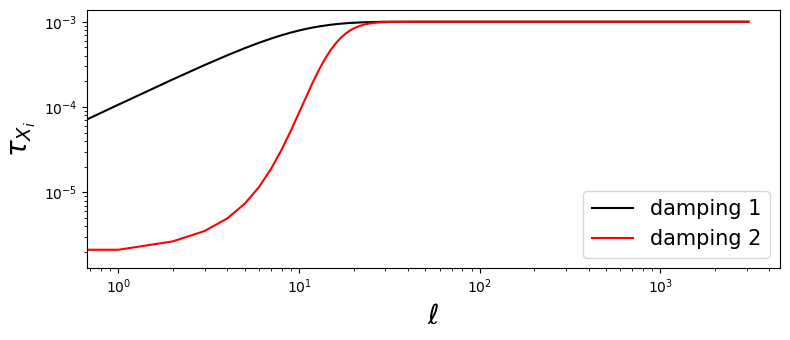

In [5]:
tau_th=1e-3
tau_arr, tau_arr2 = ftau.get_tau_arr(tau_th, lmax, plot=True)
tau_arrPLA=tau_arr[2:lmax_PLA+1]
tau_arr2PLA=tau_arr2[2:lmax_PLA+1]

In [6]:
## THEORETICAL MAPS Cls
# PLA + tau 
ClPLA_xi=(1-2*tau_arrPLA)*ClPLA
ClPLA_xi2=(1-2*tau_arr2PLA)*ClPLA

# theoretical realizations
Cls_map_cmb=hp.anafast(map_cmb, lmax=lmax, use_pixel_weights=True)
Cls_map_xi=hp.anafast(map_xi, lmax=lmax, use_pixel_weights=True)
mapdiff_th=map_cmb-map_xi
Cls_mapdiff_th=hp.anafast(mapdiff_th, lmax=lmax, use_pixel_weights=True)


In [7]:
Cls_cross_th = hp.anafast( mapdiff_th, map_cmb, lmax=lmax, use_pixel_weights=True)

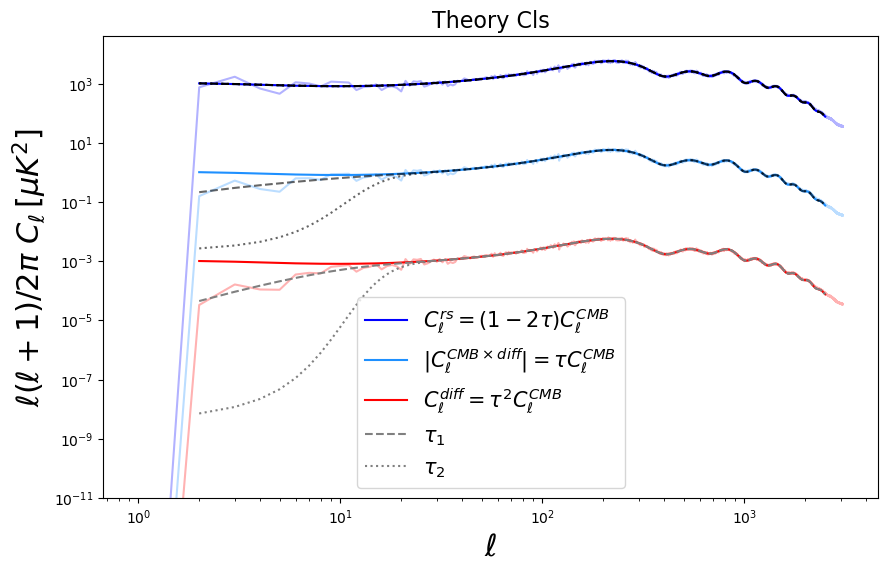

In [8]:
### PLOT suppression on different observables
normPLA, ylabel =getnorm('Dls', lPLA)  #options: Cls, Dls 
normmap, ylabel =getnorm('Dls', ll)

#Cls from maps
plt.figure(figsize=(10,6))

#regular CMB Cls 
plt.plot(ll, normmap*Cls_map_xi, color='blue', alpha=0.3)
plt.plot(lPLA, normPLA*(1-2*tau_th)*ClPLA, color='blue', ls='-', label=r'$C_\ell^{rs}=(1-2\tau)C_\ell^{CMB}$') #
plt.plot(lPLA, normPLA*(1-2*tau_arrPLA)*ClPLA,color='black', ls='--')
plt.plot(lPLA, normPLA*(1-2*tau_arr2PLA)*ClPLA,color='black', ls=':')


#difference between Cls
#plt.plot(ll, normmap*(Cls_map_cmb-Cls_map_xi), color='dodgerblue',  alpha=0.3)
#plt.plot(lPLA, normPLA*2*tau_th*ClPLA, color='dodgerblue', ls='-', label=r'$C_\ell^{CMB}-C_\ell^{rs}=(1-2\tau)C_\ell^{CMB}$')
#plt.plot(lPLA, normPLA*2*tau_arrPLA*ClPLA, color='black', alpha=0.6, ls='--')
#plt.plot(lPLA, normPLA*2*tau_arr2PLA*ClPLA, color='black', alpha=0.6, ls=':')


#|cross Cls|
plt.plot(ll, normmap*np.absolute(Cls_cross_th), color='dodgerblue', alpha=0.3)
plt.plot(lPLA, normPLA*tau_th*ClPLA, color='dodgerblue', alpha=1., ls='-', label=r'$|C_\ell^{CMB \times diff}|=\tau C_\ell^{CMB} $')
plt.plot(lPLA, normPLA*tau_arrPLA*ClPLA, color='black', alpha=0.6, ls='--')
plt.plot(lPLA, normPLA*tau_arr2PLA*ClPLA, color='black', alpha=0.6, ls=':')


#difference between maps
plt.plot(ll,   normmap*Cls_mapdiff_th, color='red',alpha=0.3)
plt.plot(lPLA, normPLA*tau_th**2*ClPLA, color='red', ls='-', label=r'$C_\ell^{diff}=\tau^2 C_\ell^{CMB}$')
plt.plot(lPLA, normPLA*tau_arrPLA*tau_arrPLA*ClPLA, color='gray', ls='--', label=r'$\tau_1$')
plt.plot(lPLA, normPLA*tau_arr2PLA*tau_arr2PLA*ClPLA, color='gray', ls=':', label=r'$\tau_2$')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-11, 4e4)
plt.xlabel(r'$\ell$', fontsize=22)
plt.ylabel(ylabel, fontsize=22)
plt.title('Theory Cls', fontsize=16)
plt.legend(fontsize=15)
plt.show()

# Beams

normalized so that $C_\ell^{beam}=1$ at large scales: <br>
beam map normalized to 1: $\sum_{pix} B_{pix} \Delta\Omega_{pix}[\rm{rad}^2]=1$   $\qquad$  should be normalized to $4\pi$ to get Cls=1<br>
further multiply: $C_l^{\rm{beam}}=4\pi \cdot$ hp.anafast(beam_map)

In [9]:
# CHECK beam normalization
pixArea_rad = hp.nside2pixarea(nside)
print('normalized beam = ', np.sum(beam0)*pixArea_rad, np.sum(beam1)*pixArea_rad)

normalized beam =  1.0 0.9999999999999998


l=0	 4pi*Cl=: 0.9999999983507629 	 Cl = 0.07957747141470556
max map_beam =  9925.020447545237 	max rad profile =  10212.122929266645
image pixels size =  2.938820493078256 times initial pixels


/home/evanetti/BEAMS/beams_code/functions_beams.py:244: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


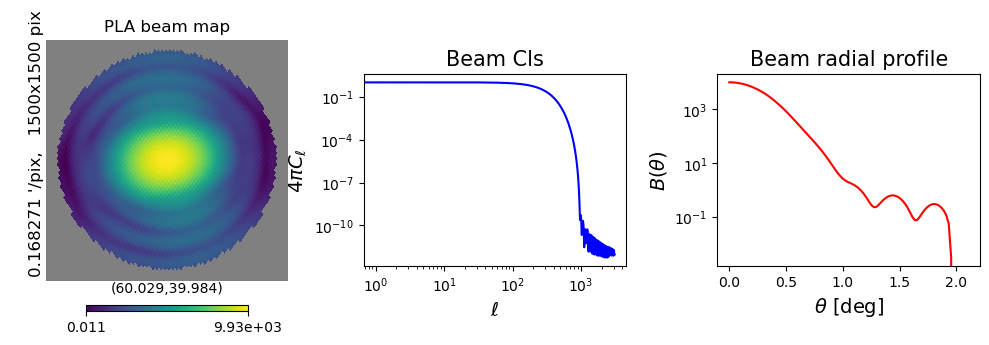

l=0	 4pi*Cl=: 0.9999999999982307 	 Cl = 0.07957747154580688
max map_beam =  59100.12206855254 	max rad profile =  59910.23888714125
image pixels size =  1.342771570837944 times initial pixels


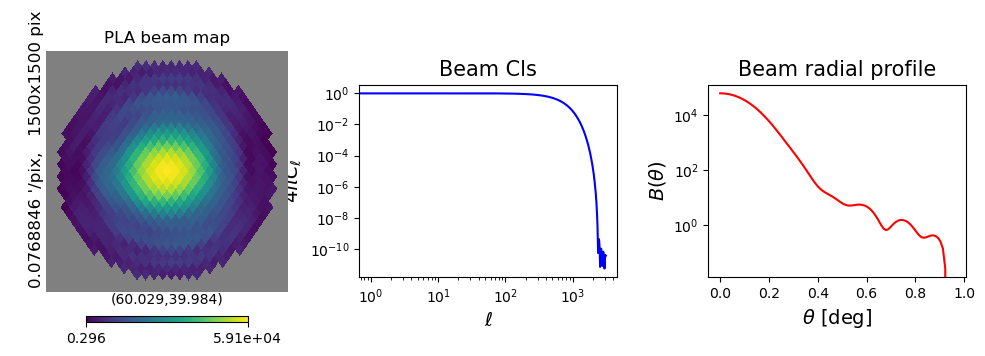

1

In [10]:
fbeams.plot_beam(beam0, vc0, opt_plot=True)
fbeams.plot_beam(beam1, vc1, opt_plot=True)

In [11]:
#### Beam Cls: on large scales Cls should be = 1 (check also in convolution code)
Cls_beam0=hp.anafast(beam0, use_pixel_weights=True)*4*np.pi  # symmetrized beams, up to lmax
Cls_beam1=hp.anafast(beam1, use_pixel_weights=True)*4*np.pi 

print('Check that beam Cls are =1 on large scales')
print(f'                l={ll[0]}           l={ll[5]}               l={ll[10]}')
print('beam0: ', Cls_beam0[0], Cls_beam0[5], Cls_beam0[10] )
print('beam1: ', Cls_beam1[0], Cls_beam1[5], Cls_beam1[10] )

Check that beam Cls are =1 on large scales
                l=0           l=5               l=10
beam0:  0.9999999983519358 0.9995113081889576 0.9982094225433674
beam1:  0.9999999999904328 0.9999161790156882 0.9996926958755954


cut beam below 0.001 : 	lmax_beam0 = 669 	lmax_beam1 =  1619


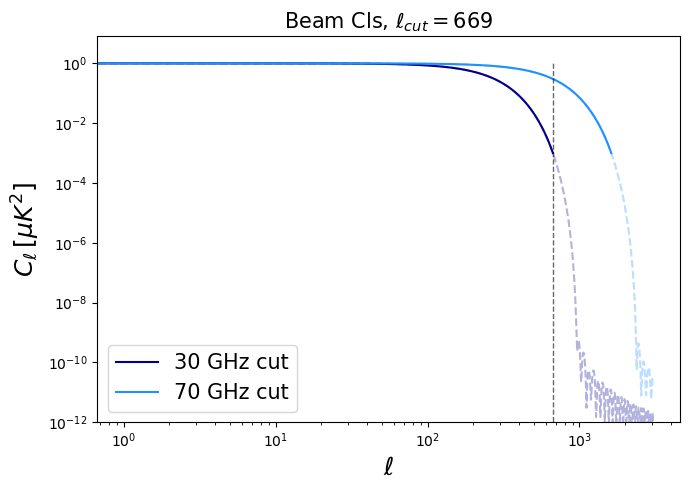

In [12]:
### CUT high beam multipoles
beam_thr=1e-3
idx_lmax_cut0 = np.where(Cls_beam0 < beam_thr)[0][0]
idx_lmax_cut1 = np.where(Cls_beam1 < beam_thr)[0][0]
lmax_beam0 = ll[idx_lmax_cut0]
lmax_beam1 = ll[idx_lmax_cut1]
print('cut beam below', beam_thr,': \tlmax_beam0 =', lmax_beam0, '\tlmax_beam1 = ', lmax_beam1)

lmax_beam=np.min([lmax_beam0, lmax_beam1])
Cls_beam0_cut=Cls_beam0[:lmax_beam+1]
Cls_beam1_cut=Cls_beam1[:lmax_beam+1]

ll_cut=ll[:lmax_beam+1]


plt.figure(figsize=(7,5))
plt.plot(ll, Cls_beam0, color='darkblue', ls='--', alpha=0.3)
plt.plot(ll, Cls_beam1, color='dodgerblue', ls='--', alpha=0.3)
plt.plot(ll[:lmax_beam0+1], Cls_beam0[:lmax_beam0+1], color='darkblue', ls='-', label='30 GHz cut')
plt.plot(ll[:lmax_beam1+1], Cls_beam1[:lmax_beam1+1], color='dodgerblue', ls='-', label='70 GHz cut')
plt.vlines(lmax_beam0, np.min(Cls_beam0), np.max(Cls_beam0), color='black', alpha=0.6, ls='--', lw=1)
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-12, 8)
plt.xlabel(r'$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.legend(fontsize=15)
plt.title(r'Beam Cls, $\ell_{cut}=$'+str(lmax_beam0), fontsize=15)
plt.tight_layout()
plt.show()


# Convolved maps

Expected: Cls of the convolved maps nearly coincide on large scales (since they are from the same realization), samped around the beam scale.

In [13]:
#create convolved maps with symmetric beam (in harmonic space)
map0symm=hp.sphtfunc.smoothing(map_cmb, beam_window=np.sqrt(Cls_beam0_cut), lmax=lmax_beam) #symmetric beam case
map1symm=hp.sphtfunc.smoothing(map_xi, beam_window=np.sqrt(Cls_beam1_cut), lmax=lmax_beam)

In [14]:
# convolved maps
Cls_map0=hp.anafast(map0, lmax=lmax, use_pixel_weights=True)
Cls_map1=hp.anafast(map1, lmax=lmax, use_pixel_weights=True)
Cls_map0symm=hp.anafast(map0symm, lmax=lmax, use_pixel_weights=True)
Cls_map1symm=hp.anafast(map1symm, lmax=lmax, use_pixel_weights=True)

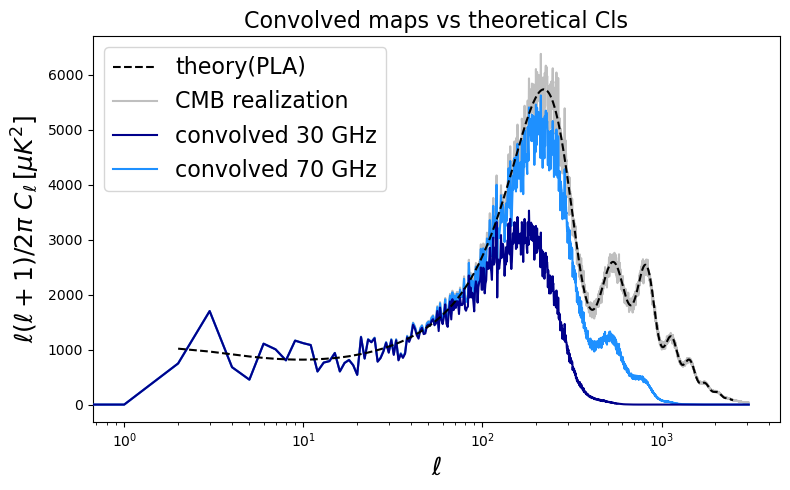

In [15]:
## PLOT convolved CLS
opt='Dls'
normPLA, ylabel =getnorm(opt, lPLA)  #options: Cls, Dls 
normmap, ylabel =getnorm(opt, ll)

plt.figure(figsize=(8,5))
plt.plot(lPLA, normPLA*ClPLA,color='black', ls='--', label='theory(PLA)',zorder=10)
plt.plot(ll, normmap*Cls_map_cmb, color='gray',alpha=0.5, ls='-', label='CMB realization')
plt.plot(ll, normmap*Cls_map0, color='darkblue', ls='-', label='convolved 30 GHz', zorder=6) # realistic convolution
plt.plot(ll, normmap*Cls_map1, color='dodgerblue', ls='-', label='convolved 70 GHz', zorder=4)
plt.xscale('log')
#plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=18)
plt.ylabel(ylabel, fontsize=18)
plt.title('Convolved maps vs theoretical Cls', fontsize=16)
plt.legend(fontsize=16)
plt.tight_layout()
plt.show()

# Noise

white noise map = array with len $=N_{pix}$ of random variables with mean $=0$, variance $=\sigma_{pix}^2$<br>
where $\sigma_{pix}^2$ is the variance of thermal noise inside the pixel area $\Delta\Omega_{\rm{pix}}$, in $\mu K$ (T-CMB units)<br>

Planck thermal noise data taken from Tab.2 of 1907.11642:  $\sigma_{pix}^T$ reported in [$\mu\rm{K}\cdot$ deg] in Rayleigh-Jeans temperature units<br>
$\longrightarrow$ convert to CMB temperature units (same as used CMB Cls): $\sigma_{\rm{RJ}}=\rm{factor}\cdot \sigma_{\rm{CMB}} $ $\qquad\rm{factor}=\frac{x^2e^x}{(e^x-1)^2}\quad x=\frac{h\nu}{k_B T_{\rm{CMB}}}$<br>
$\longrightarrow$ scale from 1 deg to pixel size:  $\sigma_{\rm{pix}}[\mu\rm{K}]=\frac{\sigma[\mu\rm{K\,\,deg}]}{\sqrt{\Delta\Omega_{\rm{pix}}[\rm{deg}]}}$<br>
$\qquad$ derivation:  the variance inside a certain area scales as $\sigma\propto\frac{1}{\sqrt{N}}$, where $N$ is the number of hits in the area (less noise for a bigger area)<br>
$\qquad$ assuming uniform scanning strategy, the number of hits increases with the area: $ N\propto \Delta\Omega_{pix} = \frac{4\pi}{N_{\rm{pix}}}= \frac{4\pi}{12 N_{\rm{side}}^2}\quad\longrightarrow\quad \sigma_{pix}\propto\frac{1}{\sqrt{\Delta\Omega_{pix} }}\propto\sqrt{N_{pix}}\propto N_{\rm{side}} $<br>
$\qquad$ For variance $\sigma_*$ defined over any area $\Delta\Omega_*$, use conversion $\sigma_{pix} = \sigma_*\sqrt{\frac{\Delta\Omega_*}{\Delta\Omega_{\rm{pix}}}}$<br>
Checked: computed Cls of noise map and averaged them, excluding highest ells to avoid pixelization effects --> obtain the expected Cls amplitude: $\sigma_{pix}^2 \Delta\Omega_{pix}[\rm{rad}^2]$ 


ALTERNATIVE: generate noise map from Cls<br>
White noise Cls are flat with amplitude $C_\ell^N = \sigma_{pix}^2 \Delta\Omega_{pix}[\rm{rad}^2]$ $\longrightarrow$ generate map from here with hp.synfact(Cls_noise)<br>
Problem: this method underestimates the variance because $\sigma^2=\sum_\ell \frac{2\ell+1}{4\pi}C_\ell $ with the sum truncated at $\ell_{max}$ numerically, while it should go to $\ell=\infty$

Expected Cls for white noise:
$C_\ell^N = \sigma_{pix}^2 \Delta\Omega_{pix}[\rm{rad}^2]$<br>
diff maps: $C_\ell^{N_{diff}} = (\sigma_{pix 1}^2+\sigma_{pix 2}^2) \Delta\Omega_{pix} = C_\ell^{N_1}+C_\ell^{N_2}$<br>

 

f[GHz]	σ_RJ[μK⋅deg]	σ_CMB[μK⋅deg]	σ_RJ[μK⋅pix]	σ_CMB[μK⋅pix]
30 	2.450 		 2.508		 42.79 		43.793
44 	2.570 		 2.701		 44.88 		47.176
70 	3.080 		 3.490		 53.79 		60.959
100 	1.000 		 1.287		 17.46 		22.473
143 	0.333 		 0.551		 5.82 		9.619
217 	0.261 		 0.781		 4.56 		13.640
353 	0.198 		 2.557		 3.46 		44.662
545 	0.086 		 13.680		 1.49 		238.910
857 	0.032 		 502.570		 0.56 		8777.275


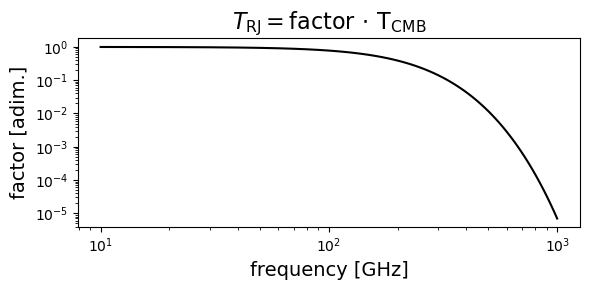

In [16]:
def Tunits(nu_in):
    """
    arg: frequency in GHz
    Returns: 
    correction factor (dimensionless) to convert between CMB and RJ temperature scales:  map_mK_RJ = map_mKCMB * factor
    """
    c = 299792458.      # speed of light [m/s]
    k = 1.3806488e-23   # Boltzmann constant [J/K]
    h = 6.62606957e-34  # Planck constant [J⋅s]
    T_cmb = 2.725       # CMB temperature [K]

    nu = nu_in * 1e9    # convert GHz to Hz
    x = h*nu/(k*T_cmb)  # dimensionless frequency
    
    factor=x**2*np.exp(x)/(np.exp(x) - 1.)**2

    return factor

nu=np.array([   30,     44,     70,     100,    143,    217,    353,    545,    857  ])
sigma_mukdeg_RJ=np.array([2.45,   2.57,   3.08,   1.00,   0.333,  0.261,  0.198,  0.0855, 0.0319 ])  ##thermal noise data from Tab.2 of 1907.11642

#convert to CMB T-units
sigma_mukdeg_CMB=sigma_mukdeg_RJ/Tunits(nu)

#scale noise to pixel size (CMB T-units)
pixArea_deg=hp.nside2pixarea(nside, degrees=True)
sigma_mukpix_RJ=sigma_mukdeg_RJ/np.sqrt(pixArea_deg)
sigma_mukpix_CMB=sigma_mukdeg_CMB/np.sqrt(pixArea_deg)

print('f[GHz]\tσ_RJ[μK⋅deg]\tσ_CMB[μK⋅deg]\tσ_RJ[μK⋅pix]\tσ_CMB[μK⋅pix]')
for ii in range(len(nu)):
    print(f'{nu[ii]:.0f} \t{sigma_mukdeg_RJ[ii]:.3f} \t\t {sigma_mukdeg_CMB[ii]:.3f}\t\t {sigma_mukpix_RJ[ii]:.2f} \t\t{sigma_mukpix_CMB[ii]:.3f}')

#corresponding Cls amplitude
NCls_level=pixArea_rad*sigma_mukpix_CMB**2  #theoretical Cls amplitude


#plot conversion factor 
plt.figure(figsize=(6,3))
nu_range=np.linspace(10, 1000, 100) #freq in GHz
factor_range=Tunits(nu_range)
plt.loglog(nu_range, factor_range, color='black', ls='-')
plt.title(r'$T_{\rm{RJ}}=\rm{factor}\,\cdot\,T_{CMB}$', fontsize=16)
plt.xlabel('frequency [GHz]', fontsize=14)
plt.ylabel('factor [adim.]', fontsize=14)
plt.tight_layout()
plt.show()


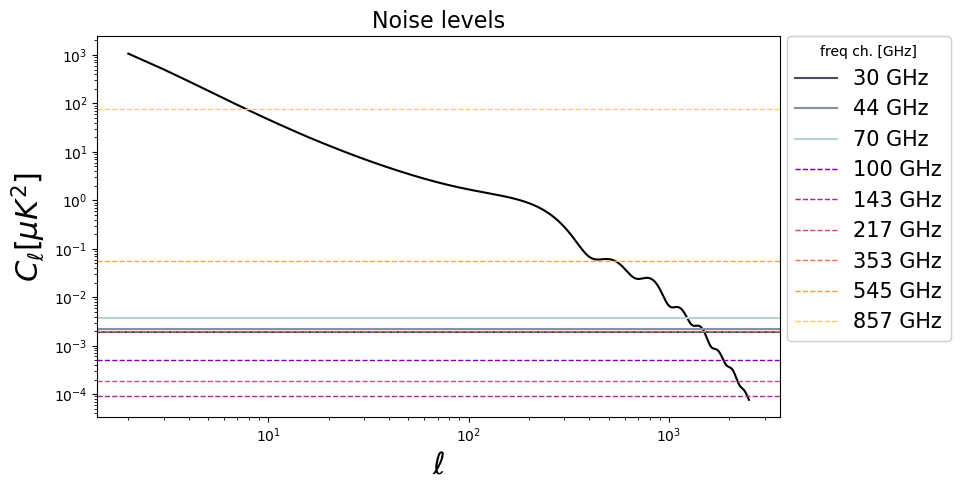

In [17]:
plt.figure(figsize=(8,5))
plt.plot(lPLA, ClPLA, color='black', ls='-', label='theory(PLA)')

nu_LFI = nu[:3]
nu_HFI = nu[3:]
cmap_LFI = plt.cm.bone
cmap_HFI = plt.cm.plasma
colors = np.concatenate([cmap_LFI(np.linspace(0.35, 0.8, 3)), cmap_HFI(np.linspace(0.25,0.93, 6))])

hlines = []
for freq, level, color in zip(nu_LFI, NCls_level[:3], colors[:3]):
    l, = plt.plot([], [], color=color, ls='-', label=f'{freq} GHz')  # dummy for legend
    hlines.append(l)
    plt.axhline(y=level, color=color, ls='-')

for freq, level, color in zip(nu_HFI, NCls_level[3:], colors[3:]):
    l, = plt.plot([], [], color=color, ls='--', lw=1., label=f'{freq} GHz')
    hlines.append(l)
    plt.axhline(y=level, color=color, ls='--', lw=1.)

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=22)
plt.ylabel(r'$C_\ell [\mu K^2]$', fontsize=22)
plt.title('Noise levels', fontsize=16)

# main legend (theory only)
plt.legend(fontsize=15)

# separate legend for frequency lines, outside the plot
freq_legend = plt.legend(handles=hlines, fontsize=15, title='freq ch. [GHz]', 
                         bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0.)
plt.gca().add_artist(plt.gca().get_legend())  # restore main legend

plt.tight_layout()
plt.show()

In [18]:
## func: convert sigma form table [μK⋅deg] in RJ T-units --> to [μK⋅pix] in CMB T-units   
def convert_sigma(nu_in, nside):

    #Planck noise: from table 2 of 1907.11642, in μK⋅deg and RJ T-units
    sigma_dict = {
        30:  2.45,
        44:  2.57,
        70:  3.08,
        100: 1.00,
        143: 0.333,
        217: 0.261,
        353: 0.198,
        545: 0.0855,
        857: 0.0319
    }   
    sigma_CMB=sigma_dict[nu_in]/Tunits(nu_in)  #CONVERT to CMB T-units
    pixArea_deg=hp.nside2pixarea(nside, degrees=True) #SCALE noise to pixel size (CMB T-units)
    sigma_CMB_pix=sigma_CMB/np.sqrt(pixArea_deg) 
    return sigma_CMB_pix

sigma_pix30=convert_sigma(30, nside)  #[μK⋅pix] CMB T-units  
sigma_pix70=convert_sigma(70, nside)  #[μK⋅pix] CMB T-units 

print('σ_pix(nu=30GHz) = ', sigma_pix30)
print('σ_pix(nu=70GHz) = ', sigma_pix70)

#Cls Aamplitudes
level_Clsnoise30=pixArea_rad*sigma_pix30**2  #theoretical Cls amplitude for 30 GHz
level_Clsnoise70=pixArea_rad*sigma_pix70**2  #theoretical Cls amplitude for 70 GHz
level_Clsnoise_diff=level_Clsnoise70+level_Clsnoise30

σ_pix(nu=30GHz) =  43.79342179514282
σ_pix(nu=70GHz) =  60.9592464135254


In [19]:
### create noise maps:
npix=hp.nside2npix(nside) # generate noise map
map_noise0 = np.random.normal(loc=0.0, scale=sigma_pix30, size=npix)
map_noise1 = np.random.normal(loc=0.0, scale=sigma_pix70, size=npix)
map_noise10=map_noise1-map_noise0  

## ADD NOISE to maps: 
map0_n=map0+map_noise0 #realistic beam case
map1_n=map1+map_noise1

map0symm_n=map0symm+map_noise0 #noise only case (maps convolved with symmetric beam)
map1symm_n=map1symm+map_noise1

In [21]:
#### CHECK: that noise is constant = sigma_pix² DeltaOmega_pix
Cls_map_noise0=hp.anafast(map_noise0, lmax=lmax_beam, use_pixel_weights=True)
Cls_map_noise1=hp.anafast(map_noise1, lmax=lmax_beam, use_pixel_weights=True)
Cls_map_noise10=hp.anafast(map_noise10, lmax=lmax_beam, use_pixel_weights=True)

In [22]:
avg_Cls0=np.mean(Cls_map_noise0)
avg_Cls1=np.mean(Cls_map_noise1)
avg_Cls10=np.mean(Cls_map_noise10)

print('Average Cls\tTh. Cls amplitude \trel. difference' )
print(f'{level_Clsnoise30:.3e}\t{avg_Cls0:.3e}\t\t{(avg_Cls0-level_Clsnoise30)/level_Clsnoise30*100:.3f} %')
print(f'{level_Clsnoise70:.3e}\t{avg_Cls1:.3e}\t\t{(avg_Cls1-level_Clsnoise70)/level_Clsnoise70*100:.3f} %')
print(f'{level_Clsnoise_diff:.3e}\t{avg_Cls10:.3e}\t\t{(avg_Cls10-level_Clsnoise_diff)/level_Clsnoise_diff*100:.3f} %')

Average Cls	Th. Cls amplitude 	rel. difference
1.915e-03	1.915e-03		-0.006 %
3.711e-03	3.724e-03		0.353 %
5.626e-03	5.629e-03		0.051 %


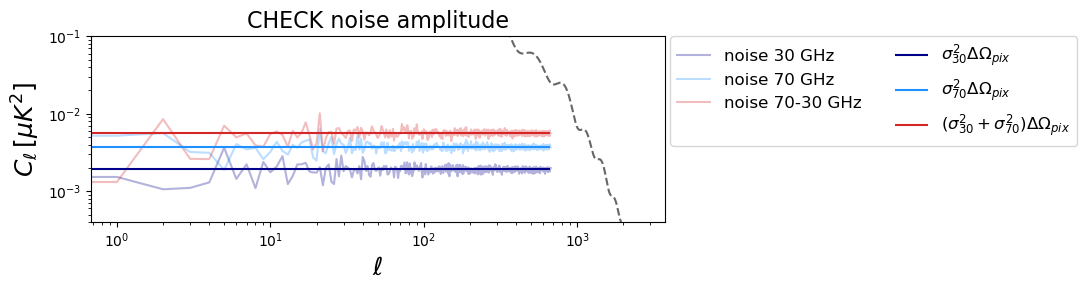

In [23]:
plt.figure(figsize=(11,3))
plt.plot(ll_cut, Cls_map_noise0, color='darkblue', alpha=0.3, ls='-', label='noise 30 GHz')
plt.plot(ll_cut, Cls_map_noise1, color='dodgerblue', alpha=0.3, ls='-', label='noise 70 GHz')
plt.plot(ll_cut, Cls_map_noise10, color='tab:red', alpha=0.3, ls='-', label='noise 70-30 GHz')
plt.hlines(level_Clsnoise30, ll_cut[0], ll_cut[-1], colors='darkblue', label=r'$\sigma_{30}^2\Delta\Omega_{pix}$')
plt.hlines(level_Clsnoise70, ll_cut[0], ll_cut[-1], colors='dodgerblue', label=r'$\sigma_{70}^2\Delta\Omega_{pix}$')
plt.hlines(level_Clsnoise_diff, ll_cut[0], ll_cut[-1], colors='tab:red', label=r'$(\sigma_{30}^2+\sigma_{70}^2)\Delta\Omega_{pix}$')
plt.plot(lPLA, ClPLA, color='black', ls='--', alpha=0.6, zorder=10)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=18)
plt.ylim(4e-4, 1e-1)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('CHECK noise amplitude', fontsize=16)
plt.legend(fontsize=12, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., ncols=2)
plt.tight_layout()
plt.show()

Cls30 conv. below noise30 at l >  466
Cls70 conv. below noise70 at l >  816


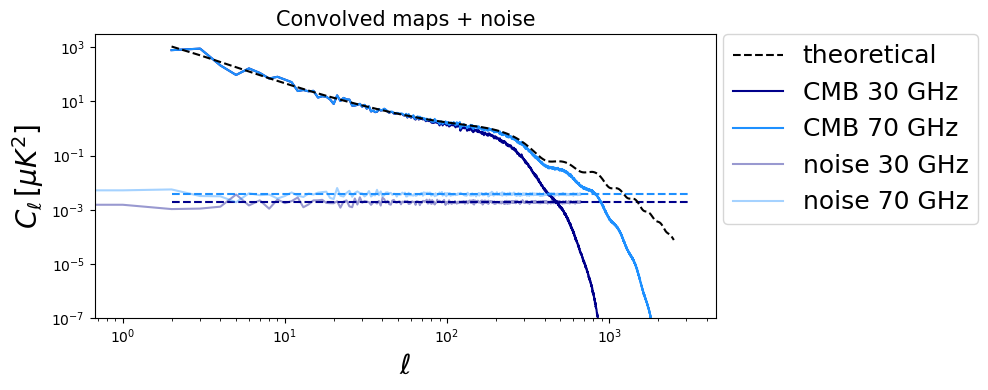

In [24]:
### find multipoles at which Cls_conv < nosie
idx30 = np.where(Cls_map0[2:] < level_Clsnoise30)[0]
idx70 = np.where(Cls_map1[2:] < level_Clsnoise70)[0]
print('Cls30 conv. below noise30 at l > ', ll[idx30[0]])
print('Cls70 conv. below noise70 at l > ', ll[idx70[0]])

plt.figure(figsize=(10,4))
plt.plot(lPLA, ClPLA,color='black', ls='--', label='theoretical', zorder=10)
plt.plot(ll[2:], Cls_map0[2:], color='darkblue', ls='-', label='CMB 30 GHz')
plt.plot(ll[2:], Cls_map1[2:], color='dodgerblue', ls='-', label='CMB 70 GHz')

plt.hlines(level_Clsnoise30, ll[2], ll[-1], colors='darkblue', ls='--')
plt.hlines(level_Clsnoise70, ll[2], ll[-1], colors='dodgerblue', ls='--')
plt.plot(ll_cut, Cls_map_noise0, color='darkblue', alpha=0.4, ls='-', label='noise 30 GHz')
plt.plot(ll_cut, Cls_map_noise1, color='dodgerblue', alpha=0.4, ls='-', label='noise 70 GHz')

plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-7, 3e3)
plt.xlabel(r'$\ell$', fontsize=20)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=20)
plt.title('Convolved maps + noise', fontsize=15)
plt.legend(fontsize=18, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., ncols=1)

plt.tight_layout()
plt.show()

#### Deconvolved noise

$C_\ell^{N(dec)} = C_\ell^N/C_\ell^{\rm{beam}}$

$C_\ell^{N_{diff}dec}= C_\ell^{N1_{dec}}+C_\ell^{N2_{dec}}= \left(\frac{\sigma_{pix1}^2}{C_\ell^{\rm{beam1}}}+\frac{\sigma_{pix2}^2}{C_\ell^{\rm{beam2}}}\right) \Delta\Omega_{pix} =  \frac{C_\ell^{N_1}}{C_\ell^{b_1}}+ \frac{C_\ell^{N_2}}{C_\ell^{b_2}}$ 

In [25]:
# DECONVOLVED NOISE

# deconvolved noise maps
map_noise0_dec=hp.sphtfunc.smoothing(map_noise0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  
map_noise1_dec=hp.sphtfunc.smoothing(map_noise1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map_noise_diff=map_noise0_dec-map_noise1_dec

Cls_map_noise0_dec=hp.anafast(map_noise0_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map_noise1_dec=hp.anafast(map_noise1_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map_noise_diff=hp.anafast(map_noise_diff, lmax=lmax_beam, use_pixel_weights=True)

In [26]:
# deconvolved noise th.
level_Clsnoise30_dec=level_Clsnoise30/Cls_beam0_cut
level_Clsnoise70_dec=level_Clsnoise70/Cls_beam1_cut
level_Clsnoise_diff_dec=level_Clsnoise30_dec+level_Clsnoise70_dec

<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_390496/1753522247.py:17: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


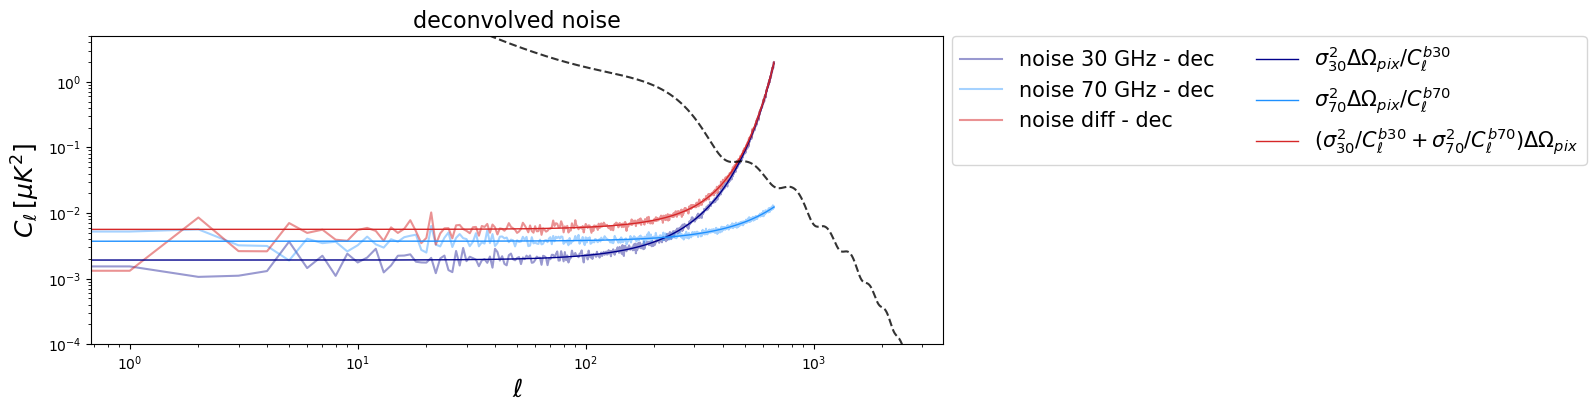

In [27]:
#### PLOT: deconvolved noise
plt.figure(figsize=(11,4))
plt.plot(ll_cut, Cls_map_noise0_dec, color='darkblue', alpha=0.4, ls='-', label='noise 30 GHz - dec')
plt.plot(ll_cut, Cls_map_noise1_dec, color='dodgerblue', alpha=0.4, ls='-', label='noise 70 GHz - dec')
plt.plot(ll_cut, Cls_map_noise_diff, color='tab:red', alpha=0.5, ls='-', label='noise diff - dec')

plt.plot(ll_cut, level_Clsnoise30_dec, color='darkblue', lw=1,  ls='-', label=r'$\sigma_{30}^2\Delta\Omega_{pix}/C_\ell^{b30}$')
plt.plot(ll_cut, level_Clsnoise70_dec, color='dodgerblue', lw=1, ls='-', label=r'$\sigma_{70}^2\Delta\Omega_{pix}/C_\ell^{b70}$')
plt.plot(ll_cut, level_Clsnoise_diff_dec, color='tab:red', lw=1,  ls='-', label=r'$(\sigma_{30}^2/C_\ell^{b30}+\sigma_{70}^2/C_\ell^{b70})\Delta\Omega_{pix}$')

plt.plot(lPLA, ClPLA,color='black', ls='--', alpha=0.8,zorder=10)


plt.ylim(1e-4, 5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('deconvolved noise', fontsize=16)
plt.legend( bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., ncols=2, fontsize=15)
plt.show()

The noise is amplified on small scales by beam deconvolution. The effect is more noticeable for the 30 GHz map, even if the noise variance is lower, because the beam is larger therefore its Cls are lower at $\ell_{\rm{beam}}$

# Deconvolution

Performed with a symmertryzed beams: $a_{lm}^{\rm{dec}}=a_{lm}^{\rm{conv}}/\sqrt{C_l^{\rm{beam}}}\qquad\longrightarrow\qquad C_l^{\rm{dec}}=C_l^{\rm{conv}}/C_l^{\rm{beam}}$<br>
- normalize beams (PLA beam maps are already normalized in steradians but not very precisely) $\quad\longrightarrow\quad C_l^{\rm{beam}}=4\pi$ hp.anafast(beam_map)     should be $=1$ on large scales (checked)
- cut high bultipoles: $C_l^{\rm{beam}}<$ threshold
- deconvolve: deconvolved Cls should coincide with the theoretical ones. If they don't these are beam and noise effects.  

Expected result from a deconvolved noisy maps:  $C_l^{dec}=C_l^{PLA}+C_l^{N}/C_l^{\rm{beam}}$  (neglecting asymm. beam residuals)

Analyze 4 cases: 
1) realistic beam + noise
2) realistic beam, noiseless
3) symmetric beam + noise
4) symmetric beam, noiseless


Observables: 
1) difference map: map_diff=map30-map70 $\quad\longrightarrow\quad C_\ell^{\rm{diff}}=\tau_{\rm{rs}}^2 C_\ell^{\rm{CMB}} + C_\ell^{N_1(\rm{dec})}+ C_\ell^{N_2(\rm{dec})}$
2) difference between Cls: map30 $\;\rightarrow\; C_\ell^{30}$,  map70 $\;\rightarrow\; C_\ell^{70}$ $\quad\longrightarrow\quad C_\ell^{30}-C_\ell^{70}= 2 \tau_{\rm{rs}} C_\ell^{\rm{CMB}} + C_\ell^{N_1(\rm{dec})} - C_\ell^{N_2(\rm{dec})}$
3) cross map_diff $\times$ map30   $\quad\longrightarrow\quad C_\ell=\tau_{\rm{rs}} C_\ell^{\rm{CMB}} + C_\ell^{N_1(\rm{dec})}$ 
4) cross map_diff $\times$ map70   $\quad\longrightarrow\quad C_\ell=\tau_{\rm{rs}} C_\ell^{\rm{CMB}} - \tau_{\rm{rs}}^2 C_\ell^{\rm{CMB}} - C_\ell^{N_2(\rm{dec})}$ 
4) cross mapp_diff $\times$ mapCMB  $\quad\longrightarrow\quad C_\ell=\tau_{\rm{rs}} C_\ell^{\rm{CMB}}$ 

In [28]:
##### DECONVOLVE with hp.smoothing 

#realistic beam + noise 
map0_n_dec=hp.sphtfunc.smoothing(map0_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolved noisy maps
map1_n_dec=hp.sphtfunc.smoothing(map1_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10_n=map0_n_dec-map1_n_dec

Cls_map0_n_dec=hp.anafast(map0_n_dec, lmax=lmax_beam, use_pixel_weights=True) 
Cls_map1_n_dec=hp.anafast(map1_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10_n=hp.anafast(map10_n, lmax=lmax_beam, use_pixel_weights=True)

#realistic beam (noiseless)
map0_dec=hp.sphtfunc.smoothing(map0, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolved noisy maps
map1_dec=hp.sphtfunc.smoothing(map1, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10=map0_dec-map1_dec

Cls_map0_dec=hp.anafast(map0_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map1_dec=hp.anafast(map1_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10=hp.anafast(map10, lmax=lmax_beam, use_pixel_weights=True)

#symmetric beam + noise
map0symm_n_dec=hp.sphtfunc.smoothing(map0symm_n, beam_window=1/np.sqrt(Cls_beam0_cut), lmax=lmax_beam)  # deconvolved noisy maps
map1symm_n_dec=hp.sphtfunc.smoothing(map1symm_n, beam_window=1/np.sqrt(Cls_beam1_cut), lmax=lmax_beam)
map10symm_n=map0symm_n_dec-map1symm_n_dec

Cls_map0symm_n_dec=hp.anafast(map0symm_n_dec, lmax=lmax_beam, use_pixel_weights=True) 
Cls_map1symm_n_dec=hp.anafast(map1symm_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_map10symm_n=hp.anafast(map10symm_n, lmax=lmax_beam, use_pixel_weights=True)

#last case: theory maps


#noise subtraction attempts 
Cls_map10_n_=Cls_map10_n-level_Clsnoise_diff_dec   ## --> ok in part of the range of interest
Cls_map10symm_n_=Cls_map10symm_n-level_Clsnoise_diff_dec ## not successfull since signal << noise

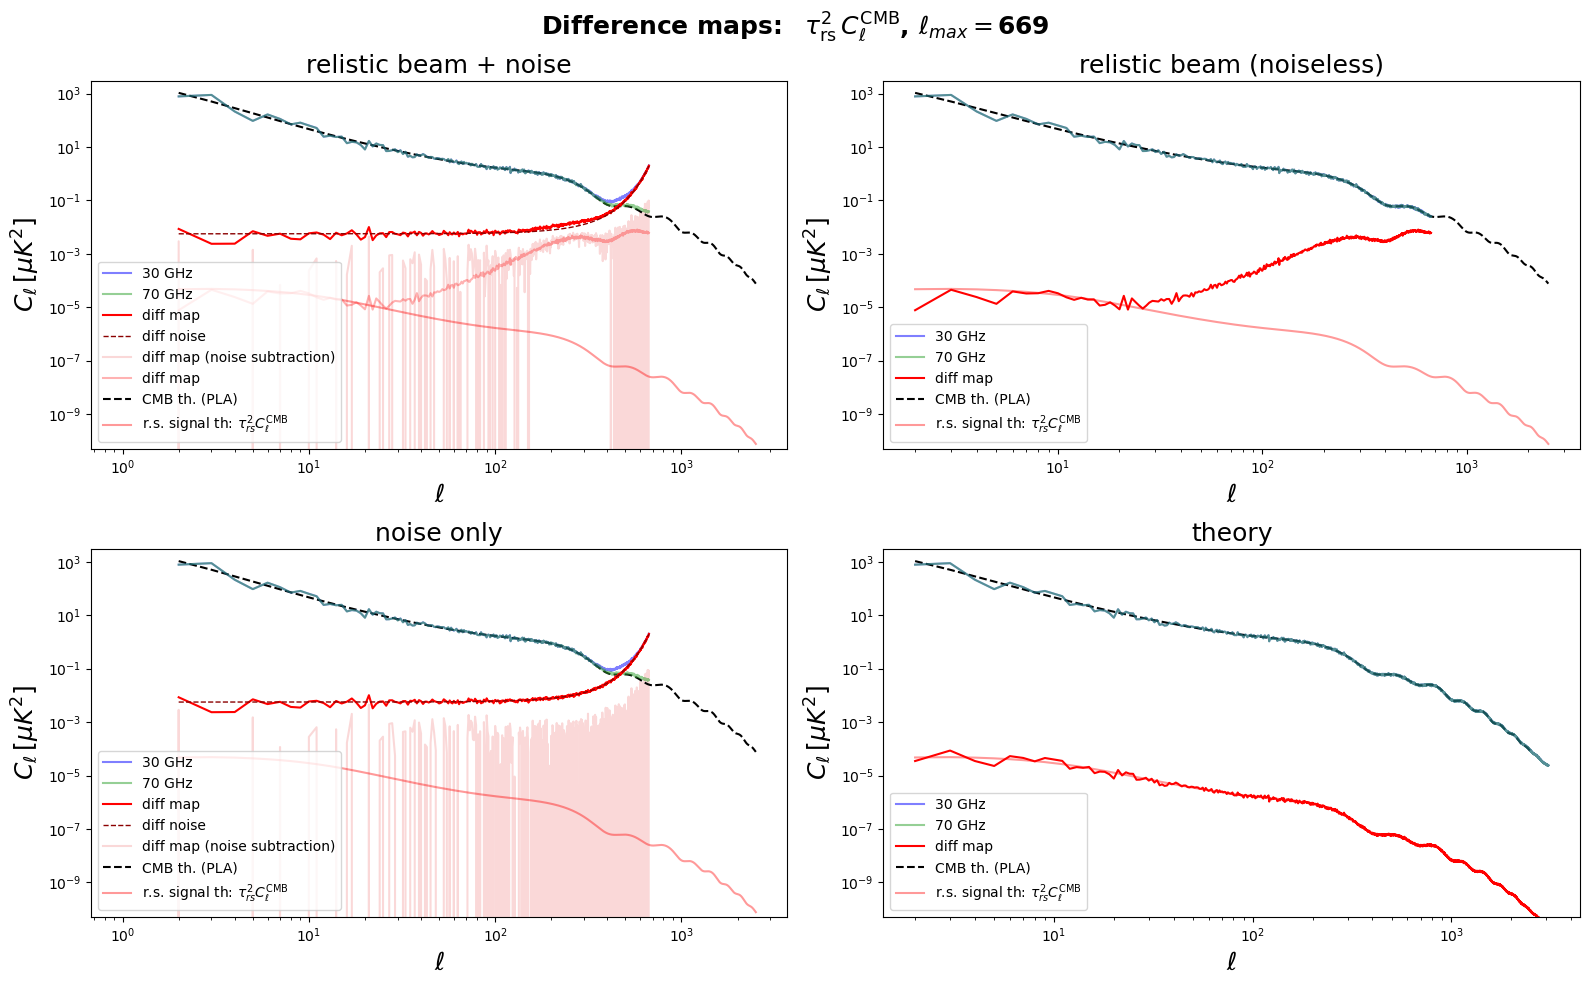

In [29]:
### PLOT difference map
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#deconvolved maps
ax[0].plot(ll_cut[2:], Cls_map0_n_dec[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[0].plot(ll_cut[2:], Cls_map1_n_dec[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[1].plot(ll_cut[2:], Cls_map0_dec[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[1].plot(ll_cut[2:], Cls_map1_dec[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[2].plot(ll_cut[2:], Cls_map0symm_n_dec[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') 
ax[2].plot(ll_cut[2:], Cls_map1symm_n_dec[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')
ax[3].plot(ll[2:], Cls_map_cmb[2:], color='blue', ls='-', alpha=0.5, label='30 GHz') #theory
ax[3].plot(ll[2:], Cls_map_xi[2:], color='tab:green', ls='-', alpha=0.5, label='70 GHz')

#difference maps
ax[0].plot(ll_cut[2:], Cls_map10_n[2:], color='red', ls='-',  label='diff map') 
ax[1].plot(ll_cut[2:], Cls_map10[2:], color='red', ls='-',  label='diff map') 
ax[2].plot(ll_cut[2:], Cls_map10symm_n[2:], color='red', ls='-',  label='diff map') 
ax[3].plot(ll[2:], Cls_mapdiff_th[2:], color='red', ls='-',  label='diff map') 

#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], level_Clsnoise_diff_dec[2:], color='darkred', ls='--', lw=1,   label='diff noise') 

#noise subtraction attempts 
ax[0].plot(ll_cut,Cls_map10_n_ , color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[2].plot(ll_cut, Cls_map10symm_n_, color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[0].plot(ll_cut[2:], Cls_map10[2:], color='red', alpha=0.3, ls='-',  label='diff map') 

#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)
ax[3].set_title('theory', fontsize=18)

for i in range(4):
    ax[i].plot(lPLA, ClPLA, color='black', ls='--', label='CMB th. (PLA)', zorder=0)  #PLA CMB Cls 
    ax[i].plot(lPLA, tau_arr[2:lmax_PLA+1]**2*ClPLA, color='red', alpha=0.4, ls='-',  label=r'r.s. signal th: $\tau_{rs}^2 C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_yscale('log')
    #ax[i].set_yscale('symlog', linthresh=1e-8)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Difference maps: $\;\;\tau_{\rm{rs}}^2 \,C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

res. scatt. signal from difference maps ($\propto\tau_{rs}^2$) is orders of magnitude below Planck LFI noise everywhere and orders of magnitude below beam residulas in the multipole range of inetersted.  

Beam residuals: $\sim 0$ at $\ell\lesssim 20$, after the go about as $\sim \tau_{rs}^4 \ell^4 C_\ell^{cmb}$

Further needed test: see if nosie allows to recontruct the zero at low multipoles

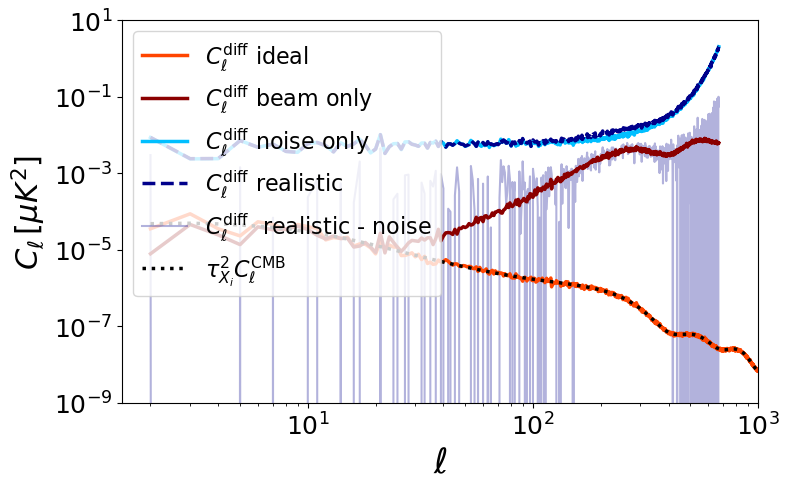

In [30]:
### PLOT FOR PAPER - Cls of DIFFERENCE MAP - 4 cases
fig = plt.figure(1, figsize=(8, 5))
#difference maps
plt.plot(ll[2:], Cls_mapdiff_th[2:], color='orangered', ls='-', lw=2.5 , label=r'$C_\ell^{\rm{diff}}$ ideal') # ideal 
plt.plot(ll_cut[2:], Cls_map10[2:], color='darkred', ls='-', lw=2.5, label=r'$C_\ell^{\rm{diff}}$ beam only') # realistic beam, noiseless
plt.plot(ll_cut[2:], Cls_map10symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{\rm{diff}}$ noise only')  #noise only, summ beam
plt.plot(ll_cut[2:], Cls_map10_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{\rm{diff}}$ realistic')  #realistic beam + noise
plt.plot(ll_cut[2:], Cls_map10_n_[2:], color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'$C_\ell^{\rm{diff}}$  realistic - noise ', zorder=0)  # realistic beam + noise, with noise model subtraction
plt.plot(lPLA, tau_arr[2:int(lmax_PLA+1)]**2*ClPLA,color='black', ls=':', lw=2.5, label=r'$\tau_{X_i}^2 C_\ell^{\rm{CMB}}$')  #theoretical from PLA
 
#attempt of modeling beam residuals
#fit_attempt=tau_arr[2:int(lmax_PLA+1)]**2*ClPLA  +  lPLA**4*tau_arr[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='tab:purple', alpha=0.7, ls='-', zorder=0, lw=2, label=r'$\tau^2C_\ell^{\rm{CMB}}+ \tau^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='upper left')
plt.tight_layout()


plt.savefig("/home/evanetti/BEAMS/paper_figures/Clsdiff_all.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [31]:
## DIFFERENCE between Cls (subtract noise first)
Cls_map0_n_dec_=Cls_map0_n_dec-level_Clsnoise30_dec #subtract from initial maps
Cls_map1_n_dec_=Cls_map1_n_dec-level_Clsnoise70_dec
Cls_map0symm_n_dec_=Cls_map0symm_n_dec-level_Clsnoise30_dec
Cls_map1symm_n_dec_=Cls_map1symm_n_dec-level_Clsnoise70_dec

level_Clsdiff_noise=level_Clsnoise30_dec-level_Clsnoise70_dec

Cls10_diff_n_=Cls_map0_n_dec_-Cls_map1_n_dec_
Cls_map10symm_n_=Cls_map0symm_n_dec_-Cls_map1symm_n_dec_

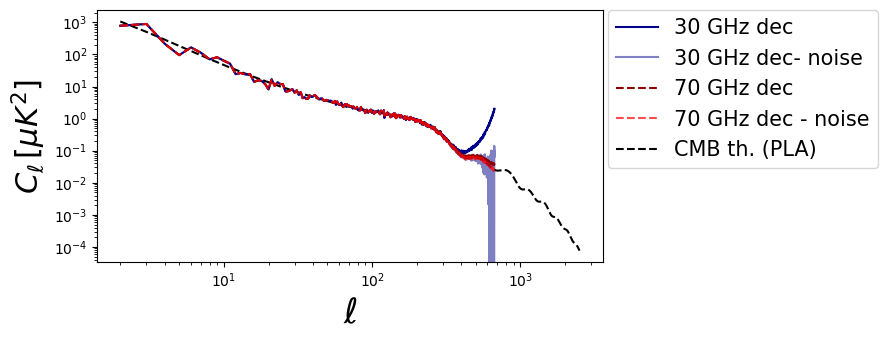

In [32]:
#noise subtraction on initial deconvolved maps
fig=plt.figure(1, figsize=(9, 3.5))
plt.plot(ll_cut[2:], Cls_map0_n_dec[2:], color='darkblue', ls='-', label='30 GHz dec') 
plt.plot(ll_cut[2:], Cls_map0_n_dec_[2:], color='darkblue', ls='-', alpha=0.5, label='30 GHz dec- noise') 

plt.plot(ll_cut[2:], Cls_map1_n_dec[2:], color='darkred', ls='--', label='70 GHz dec') 
plt.plot(ll_cut[2:], Cls_map1_n_dec_[2:], color='red', ls='--', alpha=0.7, label='70 GHz dec - noise') 

plt.plot(lPLA, ClPLA, color='black', ls='--', label='CMB th. (PLA)', zorder=0) 

plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.legend( bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0., fontsize=15)
fig.tight_layout()
plt.show()

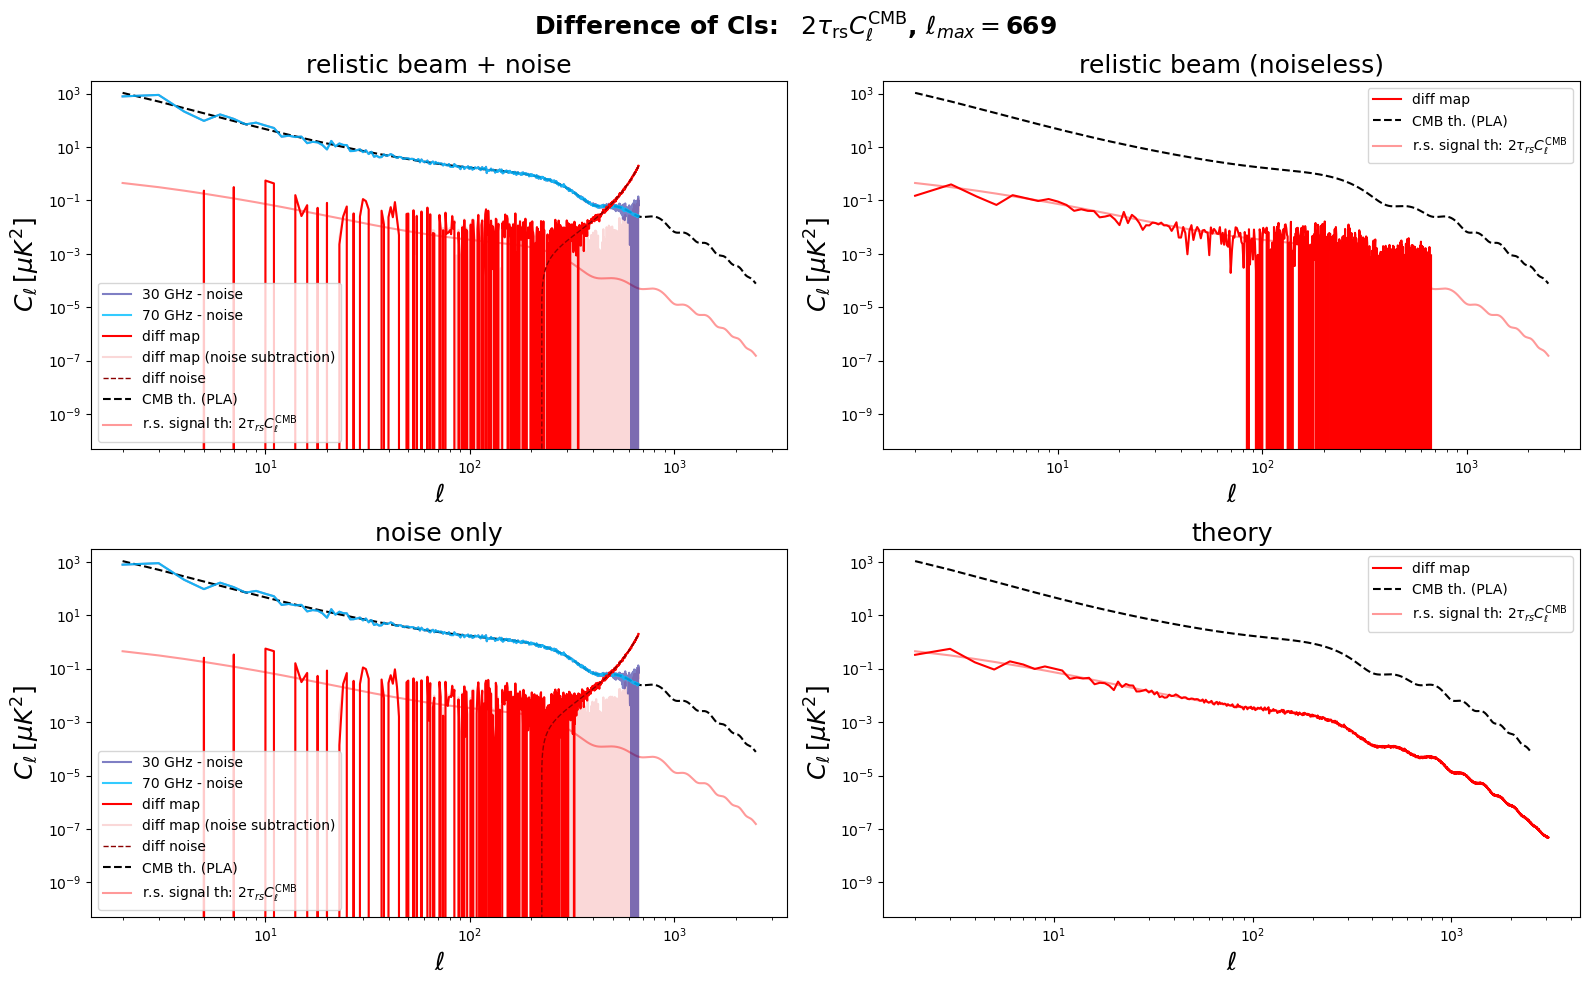

In [33]:
### Difference of Cls: 
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

ax[0].plot(ll_cut[2:], Cls_map0_n_dec_[2:], color='darkblue', ls='-', alpha=0.5, label='30 GHz - noise') 
ax[0].plot(ll_cut[2:], Cls_map1_n_dec_[2:], color='deepskyblue', ls='-', alpha=0.8, label='70 GHz - noise')
ax[2].plot(ll_cut[2:], Cls_map0symm_n_dec_[2:], color='darkblue', ls='-', alpha=0.5, label='30 GHz - noise') 
ax[2].plot(ll_cut[2:], Cls_map1symm_n_dec_[2:], color='deepskyblue', ls='-', alpha=0.8, label='70 GHz - noise')


#Cls difference (no noise subtraction) 
ax[0].plot(ll_cut[2:], Cls_map0_n_dec[2:]-Cls_map1_n_dec[2:], color='red', ls='-',  label='diff map') 
ax[1].plot(ll_cut[2:], Cls_map0_dec[2:]-Cls_map1_dec[2:], color='red', ls='-',  label='diff map') 
ax[2].plot(ll_cut[2:], Cls_map0symm_n_dec[2:]-Cls_map1symm_n_dec[2:], color='red', ls='-',  label='diff map') 
ax[3].plot(ll[2:], Cls_map_cmb[2:]-Cls_map_xi[2:], color='red', ls='-',  label='diff map') 

#noise subtraction attempts 
ax[0].plot(ll_cut[2:], Cls10_diff_n_[2:] , color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
ax[2].plot(ll_cut[2:], Cls_map10symm_n_[2:], color='lightcoral', alpha=0.3, ls='-', lw=1.5, label='diff map (noise subtraction)', zorder=0)
#ax[0].plot(ll_cut[2:], Cls_map10[2:], color='red', alpha=0.3, ls='-',  label='diff map') 


#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], level_Clsdiff_noise[2:], color='darkred', ls='--', lw=1,   label='diff noise') 


#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)
ax[3].set_title('theory', fontsize=18)

for i in range(4):
    ax[i].plot(lPLA, ClPLA, color='black', ls='--', label='CMB th. (PLA)', zorder=0)  #PLA CMB Cls 
    ax[i].plot(lPLA, 2*tau_arr[2:lmax_PLA+1]*ClPLA, color='red', alpha=0.4, ls='-',  label=r'r.s. signal th: $2\tau_{rs}C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_yscale('log')
    #ax[i].set_yscale('symlog', linthresh=1e-5)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Difference of Cls: $\;\;2\tau_{\rm{rs}}C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

Subtraction between Cls is more noisy. Seems less promising, even if the amplitude of the signal is higher. 

Attempt fit or averaging? to see if we can recontruct the amplitude?

In [34]:
## CROSS: diff map x 30 GHz map
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_beam, use_pixel_weights=True)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_beam, use_pixel_weights=True)

## noise subtraction
Cls_cross_real_n_ = Cls_cross_real_n-level_Clsnoise30_dec
Cls_cross_symm_n_ = Cls_cross_symm_n-level_Clsnoise30_dec

In [35]:
## CROSS: diff map x 70 GHz map
Cls_cross70_real_n = hp.anafast(map10_n, map1_n_dec, lmax=lmax_beam)
Cls_cross70_real = hp.anafast(map10, map1_dec, lmax=lmax_beam)
Cls_cross70_symm_n = hp.anafast(map10symm_n, map1symm_n_dec, lmax=lmax_beam)
Cls_cross70_th = hp.anafast(mapdiff_th, map_xi, lmax=lmax_beam)

## noise subtraction
Cls_cross70_real_n_ = Cls_cross70_real_n+level_Clsnoise70_dec
Cls_cross70_symm_n_ = Cls_cross70_symm_n+level_Clsnoise70_dec

In [36]:
## CROSS: diff map x CMB map  (noise component should cancel out in the cross corr.)
Cls_crossCMB_real_n = hp.anafast(map10_n, map_cmb, lmax=lmax_beam)
Cls_crossCMB_real = hp.anafast(map10, map_cmb, lmax=lmax_beam)
Cls_crossCMB_symm_n = hp.anafast(map10symm_n, map_cmb, lmax=lmax_beam)

2507 2507 3072 671.0


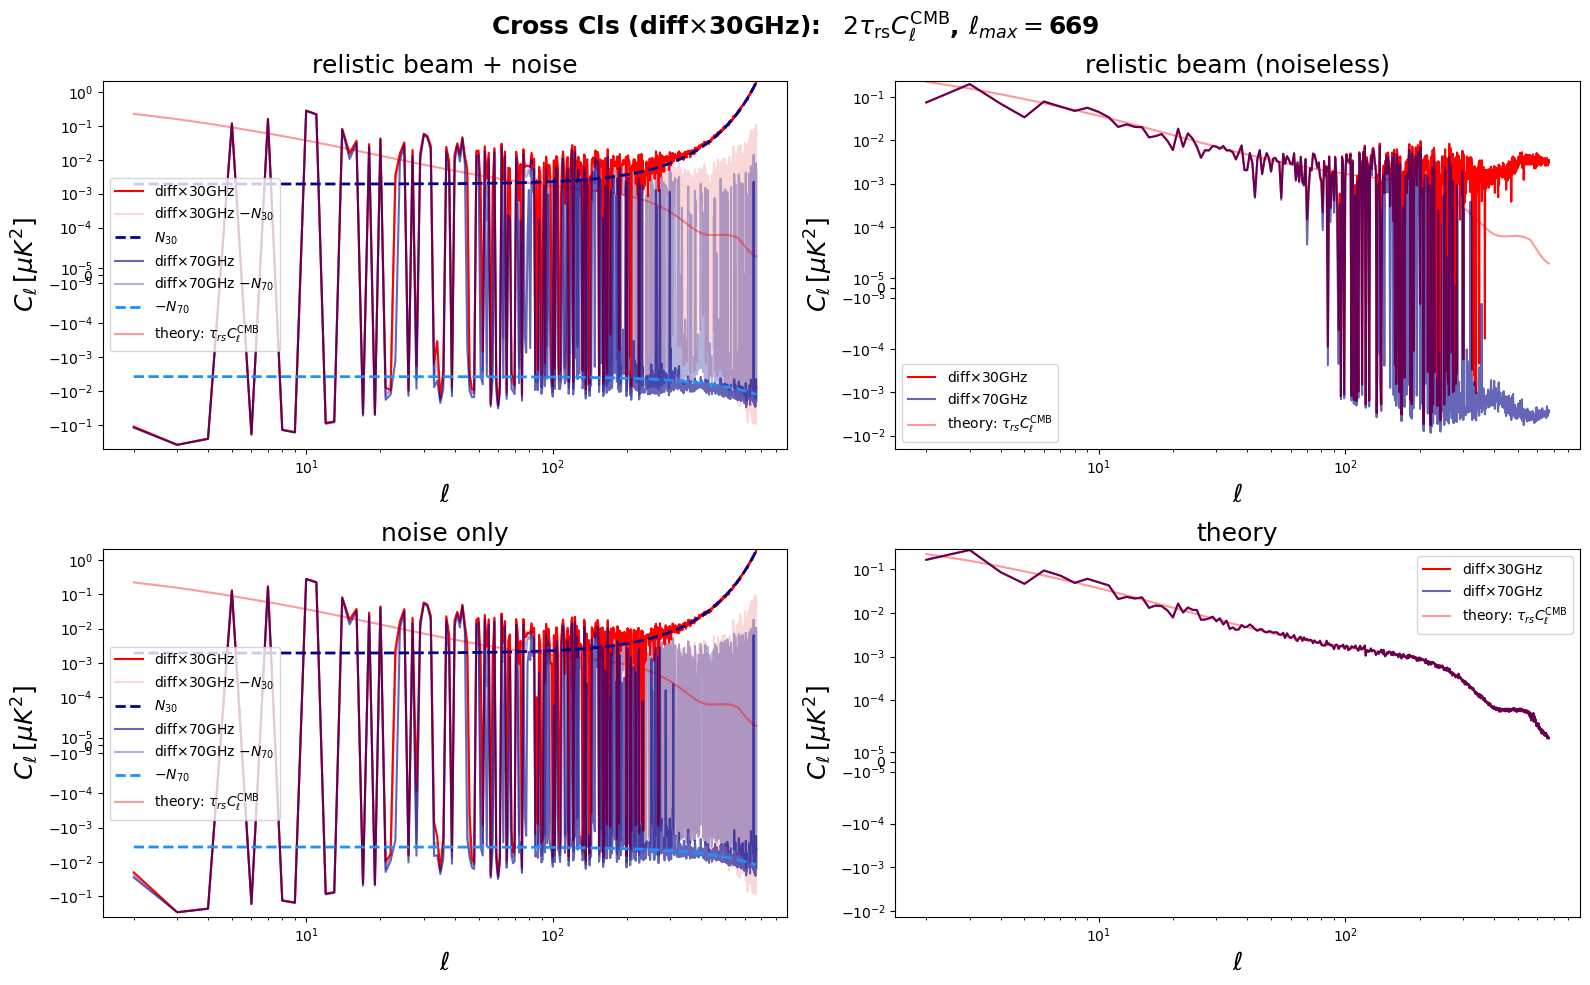

In [37]:
### CROSS Cls: 
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#cross maps (diff X 30GHz) 
ax[0].plot(ll_cut[2:], Cls_cross_real_n[2:], color='red', ls='-',  label=r'diff$\times$30GHz') 
ax[1].plot(ll_cut[2:], Cls_cross_real[2:], color='red', ls='-',  label=r'diff$\times$30GHz') 
ax[2].plot(ll_cut[2:], Cls_cross_symm_n[2:], color='red', ls='-',  label=r'diff$\times$30GHz') 
ax[3].plot(ll_cut[2:], Cls_cross_th[2:], color='red', ls='-',  label=r'diff$\times$30GHz') 
#noise subtraction attempts 
ax[0].plot(ll_cut[2:], Cls_cross_real_n_[2:] , color='lightcoral', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$30GHz $-N_{30}$', zorder=0)
ax[2].plot(ll_cut[2:], Cls_cross_symm_n_[2:], color='lightcoral', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$30GHz $-N_{30}$', zorder=0)
#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], level_Clsnoise30_dec[2:], color='darkblue', ls='--', lw=2.,   label=r'$N_{30}$') 


#cross maps (diff X 30GHz) 
ax[0].plot(ll_cut[2:], Cls_cross70_real_n[2:], color='darkblue', ls='-', alpha=0.6, label=r'diff$\times$70GHz') 
ax[1].plot(ll_cut[2:], Cls_cross70_real[2:], color='darkblue', ls='-', alpha=0.6,  label=r'diff$\times$70GHz') 
ax[2].plot(ll_cut[2:], Cls_cross70_symm_n[2:], color='darkblue', ls='-', alpha=0.6,  label=r'diff$\times$70GHz') 
ax[3].plot(ll_cut[2:], Cls_cross70_th[2:], color='darkblue', ls='-', alpha=0.6,  label=r'diff$\times$70GHz') 
#noise subtraction attempts 
ax[0].plot(ll_cut[2:], Cls_cross70_real_n_[2:] , color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$70GHz $-N_{70}$', zorder=0)
ax[2].plot(ll_cut[2:], Cls_cross70_symm_n_[2:], color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$70GHz $-N_{70}$', zorder=0)
#noise
for i in [0, 2]: 
    ax[i].plot(ll_cut[2:], -level_Clsnoise70_dec[2:], color='dodgerblue', ls='--', lw=2.,   label=r'$-N_{70}$') 
    #ax[i].plot(ll_cut[2:], level_Clsnoise70_dec[2:], color='dodgerblue', ls='--', lw=1) 


#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)
ax[3].set_title('theory', fontsize=18)


print(len(lPLA), len(ClPLA), len(tau_arr), lPLA[lmax_beam])

for i in range(4):
    ax[i].plot(lPLA[:lmax_beam-2], tau_arr[2:lmax_beam]*ClPLA[:lmax_beam-2], color='red', alpha=0.4, ls='-',  label=r'theory: $\tau_{rs}C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    #ax[i].plot(lPLA[:lmax_beam-2], tau_arr[2:lmax_beam]*(1-tau_arr[2:lmax_beam])*ClPLA[:lmax_beam-2], color='red', alpha=0.4, ls='-',  label=r'r.s. signal th: $\tau_{rs}C_\ell^{\rm{CMB}}-\tau_{rs}^2 C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    #ax[i].set_ylim(5e-11, 3e3)
    #ax[i].set_yscale('log')
    ax[i].set_yscale('symlog', linthresh=5e-5)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Cross Cls (diff$\times$30GHz): $\;\;2\tau_{\rm{rs}}C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

Cross Cls that go into matched filer: higerh almpitude than difference map ($\propto \tau_{rs}$)

Tried cross with: 
1) 30GHz map: lower noise but amplified more by beam
2) 70 GHz map: higher noise but less amplified by beam
3) CMB map, here neglecting its ubcertainties (in the real case, the one obtained from component separation, which has its own uncertainties)

2507 2507 3072 671.0


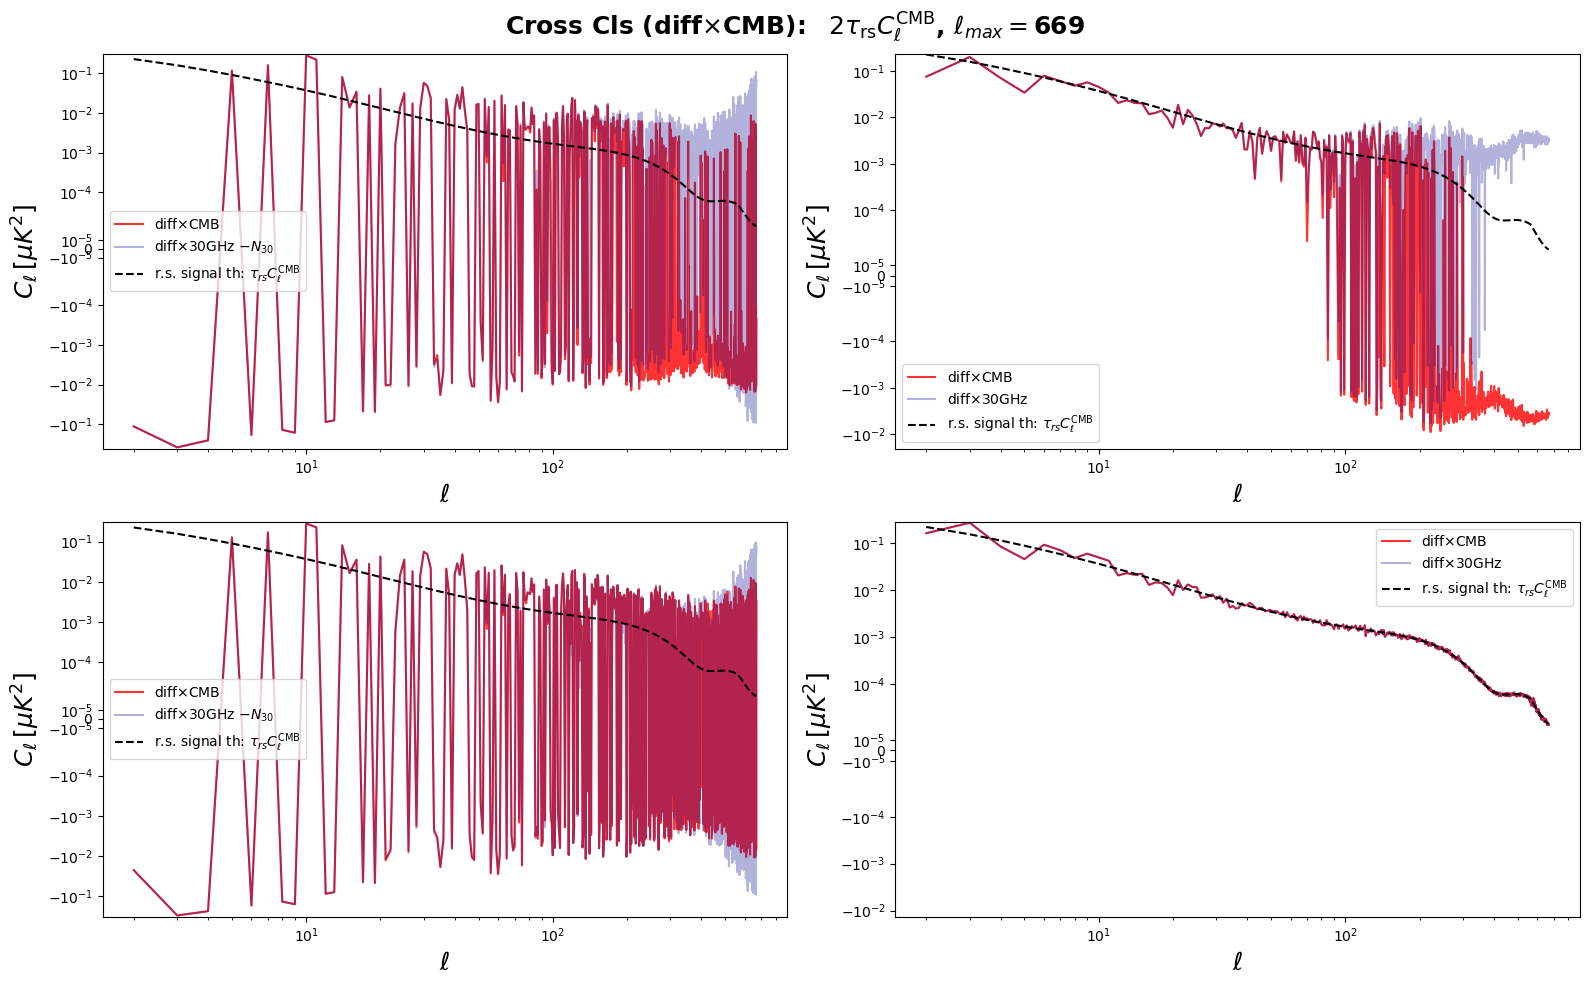

In [38]:
### CROSS Cls: 
fig, ax = plt.subplots(2, 2, figsize=(16, 10))
ax = ax.flatten()

#cross maps (diff X CMB) 
ax[0].plot(ll_cut[2:], Cls_crossCMB_real_n[2:], color='red', ls='-',  label=r'diff$\times$CMB', alpha=0.8) 
ax[1].plot(ll_cut[2:], Cls_crossCMB_real[2:], color='red', ls='-',  label=r'diff$\times$CMB', alpha=0.8) 
ax[2].plot(ll_cut[2:], Cls_crossCMB_symm_n[2:], color='red', ls='-',  label=r'diff$\times$CMB', alpha=0.8  )  
ax[3].plot(ll_cut[2:], Cls_cross_th[2:], color='red', ls='-',  label=r'diff$\times$CMB', alpha=0.8) 


#diff x 30GHz: noise subtraction attempts 
ax[0].plot(ll_cut[2:], Cls_cross_real_n_[2:] , color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$30GHz $-N_{30}$')
ax[2].plot(ll_cut[2:], Cls_cross_symm_n_[2:], color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'diff$\times$30GHz $-N_{30}$')

ax[1].plot(ll_cut[2:], Cls_cross_real[2:], color='darkblue', ls='-', alpha=0.3, label=r'diff$\times$30GHz') 
ax[3].plot(ll_cut[2:], Cls_cross_th[2:], color='darkblue', ls='-',  alpha=0.3,label=r'diff$\times$30GHz') 

print(len(lPLA), len(ClPLA), len(tau_arr), lPLA[lmax_beam])

for i in range(4):
    ax[i].plot(lPLA[:lmax_beam-2], tau_arr[2:lmax_beam]*ClPLA[:lmax_beam-2], color='black', alpha=1., ls='--',  label=r'r.s. signal th: $\tau_{rs}C_\ell^{\rm{CMB}}$', zorder=10) #theoretical map difference

    #ax[i].set_ylim(5e-11, 3e3)
    ax[i].set_xscale('log')
    #ax[i].set_yscale('log')
    ax[i].set_yscale('symlog', linthresh=5e-5)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
    ax[i].legend(fontsize=10)

fig.suptitle(r'Cross Cls (diff$\times$CMB): $\;\;2\tau_{\rm{rs}}C_\ell^{\rm{CMB}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

In [ ]:
#### CROSS Cls: 3 subplots
# 1) beam: 3 templates
# 2) noise: 3 templates
# 3) noise + beam: 3 templates

In [ ]:
#### CROSS Cls: 3 subplots
# 1) template 1: 3 cases
# 2) template 2: 3 cases
# 3) template 3: 3 cases

# Matched filtering

$E[\tau] = \frac{(\textbf{T}_{\rm{diff}})^T C^{-1}\textbf{T}_{\rm{CMB}}}{(\textbf{T}_{\rm{CMB}})^T C^{-1}\textbf{T}_{\rm{CMB}}} 
= \frac{\sum_{\hat{n}, \hat{n}'} T^T_{\rm{diff}}(\hat{n}) C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}') }{\sum_{\hat{n}, \hat{n}'}T_{\rm{CMB}}^T(\hat{n})C^{-1}_{\hat{n}, \hat{n}'}T_{\rm{CMB}}(\hat{n}')}$   
where: 
- $\textbf{T}_{\rm{diff}}=\textbf{T}_s+\textbf{T}_N$ is the data: r.s. sigmal + noise
- $\textbf{T}_{\rm{CMB}}$ is the template
- $C$ is the covariance matrix $C=\langle (\textbf{T}_{\rm{diff}}-\textbf{T}_s)(\textbf{T}_{\rm{diff}}-\textbf{T}_s)^T \rangle = \langle \textbf{T}_N \textbf{T}_N^T \rangle$, 

In Fourier space
$E[\tau]=\frac{\sum_\ell (2\ell+1) C_\ell^{\rm{diff}\times\rm{CMB}} C_\ell^{-1}}{\sum_\ell  (2\ell+1)  C_\ell^{\rm{CMB}} C_\ell^{-1}}$

where: 
- $C_\ell^{\rm{diff}\times\rm{CMB}}$ is the cross-spectrum between the difference map (data) and the template (CMB)
- $C_\ell$ is the associated to the covariance matrix. Should be the Cls of the map(data-signal), but in the real case the signal is unknown  
- NOTE: this assumes that the covariance is diagonal

Harmonic space covariance matrix: 
1. APPROX: $C_\ell\simeq C_\ell^{\rm{data}}=C_\ell^{\rm{diff}}\quad$ valid if signal $\ll$ nosie $\; \longrightarrow \; \textbf{n}=\textbf{d}-\textbf{s}\simeq \textbf{d}$  -- need to check if this is valid in this case. Check approx: compare $E[\tau_{rs}]$ extracted using covariance $C_\ell^{\rm{data}}$ or  $C_\ell^{\rm{data}-\rm{signal}}$
2. $C_\ell=C_\ell^{N}$ estimate the noise from its known statistics (account for cross-correlations between different noise components)
3. just to compare:  $C_\ell=C_\ell^{\rm{data}}-C_\ell^{\rm{signal}}=C_\ell^{\rm{diff}}-\tau_{\rm{rs}}^2 C_\ell^{\rm{CMB}}$ not possible in the real case since $\tau_{\rm{rs}}$ is unkown. Try just to see how this unkown affects the final result.

QUESTIONS: 
- how to account for uncertainties in the template? 
- in noise subtraction during match filter: noise is subtracted from Cl_cross (can't from data??) --> how do I accound for noise subtraction in the covariance?

IDEAS: 
- if we establish that different templates bias in different wasy we could use this in some way

#### 1. APPROX covariance with data

In [39]:
map_cov10_n=map10_n-mapdiff_th
map_cov10=map10-mapdiff_th
map_cov10symm_n=map10symm_n-mapdiff_th

Clscov10_n=hp.anafast(map_cov10_n, lmax=lmax_beam) #subtract signal at the map level
Clscov10=hp.anafast(map_cov10, lmax=lmax_beam)
Clscov10symm_n=hp.anafast(map_cov10symm_n, lmax=lmax_beam)

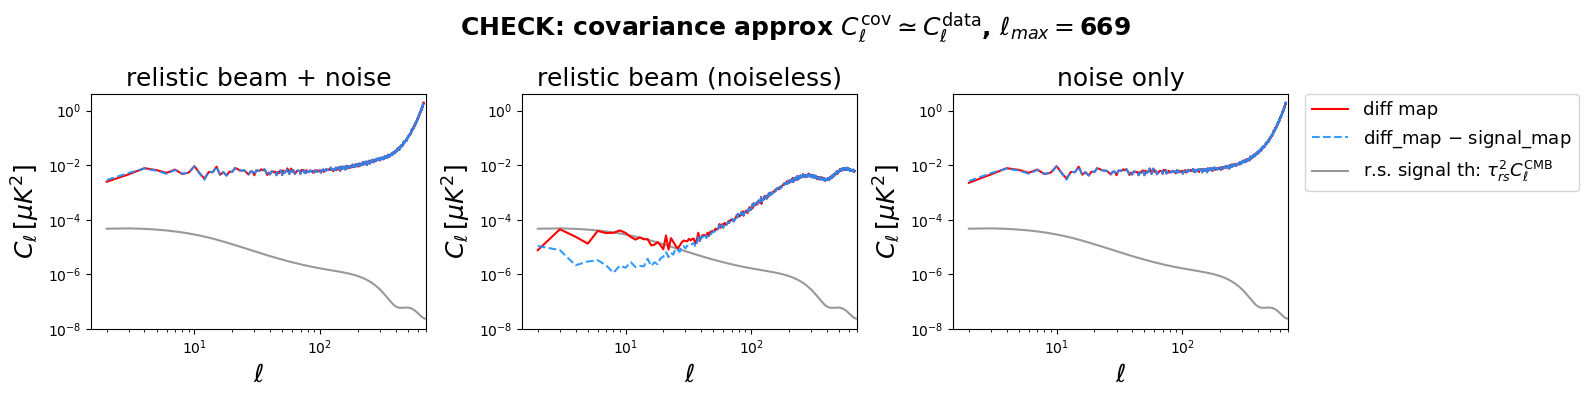

In [39]:
### PLOT difference map
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax = ax.flatten()

#difference maps
ax[0].plot(ll_cut[2:], Cls_map10_n[2:], color='red', ls='-',  label='diff map') 
ax[1].plot(ll_cut[2:], Cls_map10[2:], color='red', ls='-',  label='diff map') 
ax[2].plot(ll_cut[2:], Cls_map10symm_n[2:], color='red', ls='-',  label='diff map') 

#data-singal   done at map level
ax[0].plot(ll_cut[2:], Clscov10_n[2:], color='dodgerblue', ls='--',  label='diff_map $-$ signal_map', alpha=0.9)  
ax[1].plot(ll_cut[2:], Clscov10[2:], color='dodgerblue', ls='--',  label='diff_map $-$ signal_map', alpha=0.9) 
ax[2].plot(ll_cut[2:], Clscov10symm_n[2:], color='dodgerblue', ls='--',  label='diff_map $-$ signal_map', alpha=0.9) 

#plot titles
ax[0].set_title('relistic beam + noise', fontsize=18)
ax[1].set_title('relistic beam (noiseless)', fontsize=18)
ax[2].set_title('noise only', fontsize=18)

for i in range(3):
    ax[i].plot(lPLA, tau_arr[2:lmax_PLA+1]**2*ClPLA, color='black', alpha=0.4, ls='-',  label=r'r.s. signal th: $\tau_{rs}^2 C_\ell^{\rm{CMB}}$', zorder=1) #theoretical map difference
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlim(1.5, 700)
    ax[i].set_ylim(1e-8, 4.)
    ax[i].set_xlabel(r'$\ell$', fontsize=18)
    ax[i].set_ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)

plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=13)

fig.suptitle(r'CHECK: covariance approx $C_\ell^{\rm{cov}}\simeq C_\ell^{\rm{data}}$, $\ell_{max}=$'+str(lmax_beam), fontsize=18, fontweight='bold')
fig.tight_layout()
plt.show()

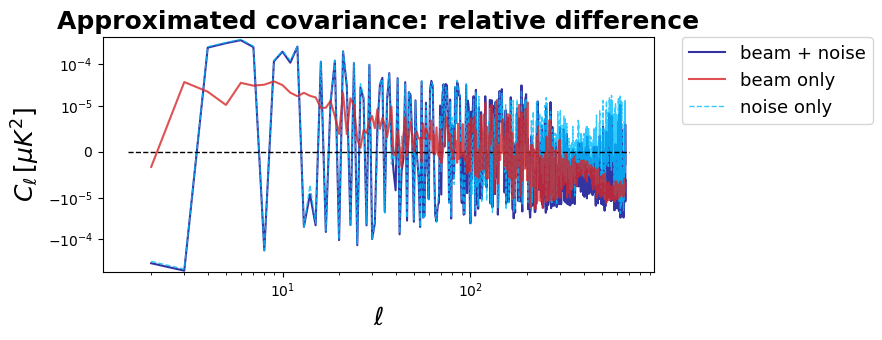

In [40]:
### PLOT difference map
fig=plt.figure(1, figsize=(9, 3.5)) 
plt.plot(ll_cut[2:], Cls_map10_n[2:]-Clscov10_n[2:], color='darkblue', ls='-',  label='beam + noise', alpha=0.8) 
plt.plot(ll_cut[2:], Cls_map10[2:]-Clscov10[2:], color='tab:red', ls='-',  label='beam only', alpha=0.8, zorder=4) 
plt.plot(ll_cut[2:], Cls_map10symm_n[2:]-Clscov10symm_n[2:], color='deepskyblue', ls='--', lw=1.,  label='noise only', alpha=0.8) 
plt.hlines(0, 1.5, 700, color='black', ls='--', lw=1)

plt.xscale('log')
plt.yscale('symlog', linthresh=1e-5)
plt.xlabel(r'$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=13)
plt.title(r'Approximated covariance: relative difference', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [41]:
#1) covariance approx. by the data   [checked that the approx is ok]

def tau_estimate(map_data, map_template, lmin_tau, lmax_tau, Cls_cov=None, Cls_noise=None, plot=False):
    '''
    Args: 
    - map_data: difference map between 2 different frequency channels, containing signal+noise+sysrematics+foregrouds
    - map_template: opt.1) map for a clean frequency    opt.2) CMB map obtained from component separation
    - lmin_tau, lmax_tau: multipole range for tau estimation
    - (opt)Cls_cov: covariance for the matched filter. If not provided, use Cls_data (APPROX)  
    - (opt)Cls_noise: noise for Cls_cross (data x template). If not provided, no noise subtraction is applied.
    '''

    Cl_template=hp.anafast(map_template, lmax=lmax_tau)  #TEMPLATE: Cls of clean map // Cls CMB
    Cl_data=hp.anafast(map_data, lmax=lmax_tau)      #DATA: difference map between two frequencies
    Cl_cross=hp.anafast(map_data, map_template, lmax=lmax_tau)     #cross-Cls of DATA x TEMPLATE
    
    if Cls_cov is None: 
        cov=Cl_data #default: 1) approx Cl_cov=Cl_data (if covariance is not provided)   
        cov_info='Cls_cov=Cls_data'

    else: 
        cov=Cls_cov[:lmax_tau+1] #if Cls_cov is provided use that. Cases 2)use known noise statistics and 3)test with real data covariance
        cov_info='Cls_cov=Provided'

    sn=''
    if Cls_noise is not None:  #noise subtraction
        Cl_cross=Cl_cross-Cls_noise[:lmax_tau+1]
        sn=' noise subtracted'
    

    l=np.arange(lmax_tau+1)   
    
    #matched filter equation:Cls_noise
    nom_l=(2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:]
    denom_l=(2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:]
    tauE=sum(nom_l)/sum(denom_l)
    sigma_tauE=np.sqrt(1/sum(denom_l))

    #compute sigma distance: 
    tau_th=1e-3
    sigma_dist=abs(tauE-tau_th)/sigma_tauE
    print(f'E[tau] = ({tauE*1e3:.3f}±{sigma_tauE*1e3:.3f})x10⁻³  \t sigma dist: {sigma_dist:.3f}\t err. interval: [{(tauE-sigma_tauE)*1e3:.3f}-{(tauE+sigma_tauE)*1e3:.3f}]x10⁻³ {sn}, {cov_info}')


    if plot==True:

        print(f'nom={sum(nom_l):.3e} \t denom={sum(denom_l):.3e}')

        plt.figure(figsize=(11,3.5))
        #plt.plot(l[lmin_tau:], Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='tab:red', ls='--')
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_cross[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{cross}}/C_\ell^{\rm{cov}}$', color='red') 
        plt.hlines(sum(nom_l), l[lmin_tau] , l[-1], color='red', ls=':', lw=2.,  alpha=0.3)  

        #plt.plot(l[lmin_tau:], Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='darkblue', ls='--')  #deconvolved 30GHz map
        plt.plot(l[lmin_tau:], (2*l[lmin_tau:]+1)*Cl_template[lmin_tau:]/cov[lmin_tau:], label=r'$(2\ell+1)C_\ell^{\rm{temp}}/C_\ell^{\rm{cov}}$', color='blue', ls='-')
        plt.hlines(sum(denom_l), l[lmin_tau] , l[-1], color='blue', ls=':', lw=2., alpha=0.3)  


        plt.hlines(0., l[lmin_tau] , l[-1], color='black', ls='--', lw=1) 

        plt.xscale('linear')
        plt.yscale('symlog', linthresh=1e-5)
        plt.xlabel(r'$\ell$', fontsize=18)
        plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
        plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=13)
        plt.tight_layout()
        plt.show()

    return tauE, sigma_tauE

In [42]:
lmin_tau=50
lmax_tau=250
tauBN_70, sigma_tauBN=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau, plot=False)  
tauBN_70subtr, sigma_tauBN=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau, Cls_noise=-level_Clsnoise70_dec, plot=False)  

E[tau] = (-3.163±0.336)x10⁻³  	 sigma dist: 12.398	 err. interval: [-3.499--2.828]x10⁻³ , Cls_cov=Cls_data
E[tau] = (0.028±0.336)x10⁻³  	 sigma dist: 2.895	 err. interval: [-0.308-0.364]x10⁻³  noise subtracted, Cls_cov=Cls_data


In [43]:
print('Match filter with covariance approx. by Cls(data): 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise')
lmin_tau=50
lmax_tau=250

# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
tauB_cmb, sigma_tauB_cmb=tau_estimate(map10, map_cmb, lmin_tau, lmax_tau)
tauB_30, sigma_tauB_30=tau_estimate(map10, map0_dec, lmin_tau, lmax_tau)
tauB_70, sigma_tauB_70=tau_estimate(map10, map1_dec, lmin_tau, lmax_tau)

# SYMMETRIC NOISE
print('\nSymmetric noise only')
tauN_cmb, sigma_tauN_cmb=tau_estimate(map10symm_n, map_cmb, lmin_tau,  lmax_tau)
tauN_30, sigma_tauN_30=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau)
tauN_30subtr, sigma_tauN_30subtr=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=level_Clsnoise30_dec)
tauN_70, sigma_tauN_70=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau)
tauN_70subtr, sigma_tauN_70subtr=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau,  lmax_tau, Cls_noise=-level_Clsnoise70_dec)

# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
tauBN_cmb, sigma_tauBN_cmb=tau_estimate(map10_n, map_cmb, lmin_tau, lmax_tau)  
tauBN_30, sigma_tauBN_30=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau)  
tauBN_30subtr, sigma_tauBN_30subtr=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau, Cls_noise=level_Clsnoise30_dec)  
tauBN_70, sigma_tauBN_70=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau)  
tauBN_70subtr, sigma_tauBN_70subtr=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau, Cls_noise=-level_Clsnoise70_dec)  


### ADD: ideal case for check
'''
### SYMMETRIC BEAM, NOISELESS
print('\nSymmetric beam (noiseless)')
tau0, sigma_tau0=tau_estimate(mapdiff_th, map_cmb, lmin_tau, lmax_tau)
'''

### saw that noise realization shifts results by non-negligible amount --> need to average over multiple noise realizations. 

## optimal range should be different depending on the case ---> try to understand if there is a way to determine that: visual? colormap like Giacomo's code? 

Match filter with covariance approx. by Cls(data): 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise

Realistic beam (noiseless)
E[tau] = (0.806±0.066)x10⁻³  	 sigma dist: 2.952	 err. interval: [0.741-0.872]x10⁻³ , Cls_cov=Cls_data
E[tau] = (1.097±0.066)x10⁻³  	 sigma dist: 1.482	 err. interval: [1.032-1.163]x10⁻³ , Cls_cov=Cls_data
E[tau] = (0.839±0.066)x10⁻³  	 sigma dist: 2.458	 err. interval: [0.773-0.904]x10⁻³ , Cls_cov=Cls_data

Symmetric noise only
E[tau] = (0.644±0.314)x10⁻³  	 sigma dist: 1.133	 err. interval: [0.330-0.958]x10⁻³ , Cls_cov=Cls_data
E[tau] = (3.264±0.314)x10⁻³  	 sigma dist: 7.212	 err. interval: [2.950-3.578]x10⁻³ , Cls_cov=Cls_data
E[tau] = (0.593±0.314)x10⁻³  	 sigma dist: 1.296	 err. interval: [0.279-0.907]x10⁻³  noise subtracted, Cls_cov=Cls_data
E[tau] = (-2.701±0.314)x10⁻³  	 sigma dist: 11.784	 err. interval: [-3.015--2.387]x10⁻³ , Cls_cov=Cls_data
E[tau] = (0.655±0.314)x10⁻³  	 sigma dist: 1.100	 err. interval: [0.341-0.969]

"\n### SYMMETRIC BEAM, NOISELESS\nprint('\nSymmetric beam (noiseless)')\ntau0, sigma_tau0=tau_estimate(mapdiff_th, map_cmb, lmin_tau, lmax_tau)\n"

In [44]:
from tabulate import tabulate
import pandas as pd

    Template            beam only                           noise only                           beam+noise                
                    E[tau][×10⁻³] b[×10⁻³] σ_dist        E[tau][×10⁻³] b[×10⁻³] σ_dist        E[tau][×10⁻³] b[×10⁻³] σ_dist
0        CMB        0.806 ± 0.066    -0.19   2.95        0.644 ± 0.314    -0.36   1.13       -0.141 ± 0.336    -1.14   3.39
1      30GHz        1.097 ± 0.066     0.10   1.48        3.264 ± 0.314     2.26   7.21        3.657 ± 0.336     2.66   7.91
2      70GHz        0.839 ± 0.066    -0.16   2.46       -2.701 ± 0.314    -3.70  11.78       -3.163 ± 0.336    -4.16  12.40
3    30GHz-N            nan ± nan      nan    nan        0.593 ± 0.314    -0.41   1.30        1.177 ± 0.336     0.18   0.53
4    70GHz-N            nan ± nan      nan    nan        0.655 ± 0.314    -0.35   1.10        0.028 ± 0.336    -0.97   2.89


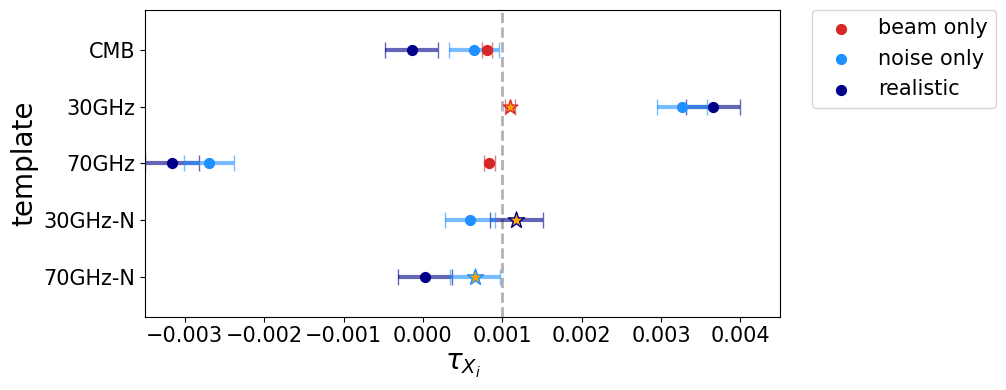

In [45]:
### visualize results 
cases = ["CMB", "30GHz", "70GHz", "30GHz-N", "70GHz-N"]

tauB=np.array([tauB_cmb, tauB_30, tauB_70, np.nan, np.nan])
tauN=np.array([tauN_cmb, tauN_30, tauN_70, tauN_30subtr, tauN_70subtr])
tauBN=np.array([tauBN_cmb, tauBN_30, tauBN_70, tauBN_30subtr, tauBN_70subtr])

sigma_tauB=np.array([sigma_tauB_cmb, sigma_tauB_30, sigma_tauB_70, np.nan, np.nan])
sigma_tauN=np.array([sigma_tauN_cmb, sigma_tauN_30, sigma_tauN_70, sigma_tauN_30subtr, sigma_tauN_70subtr])
sigma_tauBN=np.array([sigma_tauBN_cmb, sigma_tauBN_30, sigma_tauBN_70, sigma_tauBN_30subtr, sigma_tauBN_70subtr])

result_B_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauB, sigma_tauB)]
result_N_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauN, sigma_tauN)]
result_BN_ = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauBN, sigma_tauBN)]

tau_true=0.001
biasB=tauB-tau_true
biasN=tauN-tau_true
biasBN=tauBN-tau_true

sigmadistB=np.abs(biasB)/sigma_tauB
sigmadistN=np.abs(biasN)/sigma_tauN
sigmadistBN=np.abs(biasBN)/sigma_tauBN

idxB = np.nanargmin(sigmadistB)
idxN = np.nanargmin(sigmadistN)
idxBN = np.nanargmin(sigmadistBN)

arrays = [
    ["Template", "beam only",    "beam only",    "beam only",    "noise only",   "noise only",   "noise only",   "beam+noise", "beam+noise", "beam+noise"],
    ["",         "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",     "b[×10⁻³]",       "σ_dist"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, result_B_, biasB*1e3, sigmadistB, result_N_, biasN*1e3, sigmadistN, result_BN_, biasBN*1e3, sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
for group in ["beam only", "noise only", "beam+noise"]:
    df[group, "b[×10⁻³]"]   = df[group, "b[×10⁻³]"].map(lambda x: f"{x:.2f}")
    df[group, "σ_dist"] = df[group, "σ_dist"].map(lambda x: f"{x:.2f}")

print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

### PLOT results
colors = ["tab:red", "dodgerblue", "darkblue"]  #beam only, noise only, realistic

y = np.arange(len(cases))
y=y/10

fig, ax = plt.subplots(figsize=(8,4))
for i in range(len(cases)):
    ax.errorbar( tauB[i], y[i], xerr=sigma_tauB[i], color=colors[0], ecolor=colors[0], markersize=8, elinewidth=3, capsize=6, alpha=0.6, zorder=2 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxB:
        ax.scatter( tauB[idxB], y[idxB], facecolors='orange', edgecolors=colors[0], s=120, marker='*', zorder=5, label='noise only' if i==0 else '_nolegend_') 
    else:
        ax.scatter( tauB[i], y[i], color=colors[0], s=50, zorder=2, label='beam only'  if i==0 else '_nolegend_')


    ax.errorbar( tauN[i], y[i], xerr=sigma_tauN[i], color=colors[1], ecolor=colors[1], elinewidth=3, capsize=6, alpha=0.6, zorder=1 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxN:
        ax.scatter( tauN[idxN], y[idxN], facecolors='orange', edgecolors=colors[1], s=150, marker='*', zorder=4, label='noise only' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauN[i], y[i], color=colors[1], s=50,  zorder=1, label='noise only' if i==0 else '_nolegend_')

    ax.errorbar( tauBN[i], y[i], xerr=sigma_tauBN[i], color=colors[2], ecolor=colors[2],  elinewidth=3, capsize=6, alpha=0.6, zorder=0 ) #fmt='none'  #err bar options: width, lateral bar size, transparency
    if i==idxBN:
        ax.scatter( tauBN[idxBN], y[idxBN], facecolors='orange', edgecolors=colors[2], s=150, marker='*', zorder=3, label='realistic' if i==0 else '_nolegend_')
    else:
        ax.scatter( tauBN[i], y[i], color=colors[2], s=50,  zorder=0, label='realistic' if i==0 else '_nolegend_' )
    



ax.set_xticks([- 0.004, -0.003, -0.002, -0.001, 0., 0.001, 0.002, 0.003, 0.004])
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(y)
ax.set_yticklabels(cases, fontsize=15)
ax.set_xlabel(r"$\tau_{X_i}$", fontsize=20)
ax.set_ylabel(r"template", fontsize=20)

ax.set_xlim(- 0.0035, 0.0045) 
ax.set_ylim(y[0]-0.07, y[-1]+0.07)
ax.axvline(1e-3, color='black', linestyle='--', linewidth=2, alpha=0.3)  # Vertical reference line
ax.invert_yaxis()
fig.tight_layout()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=15)

plt.savefig("/home/evanetti/BEAMS/paper_figures/matched_filtering.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [46]:
tau_cmb=np.array([tauB_cmb, tauN_cmb, tauBN_30])
tau_30=np.array([tauB_30, tauN_30, tauBN_30])
tau_70=np.array([tauB_70, tauN_70, tauBN_70])
tau_30_subtr=np.array([None, tauN_30subtr, tauBN_30subtr])
tau_70_subtr=np.array([None, tauN_70subtr, tauBN_30subtr])

sigma_tau_cmb=np.array([sigma_tauB_cmb, sigma_tauN_cmb, sigma_tauBN_cmb])
sigma_tau_30=np.array([sigma_tauB_30, sigma_tauN_30, sigma_tauBN_30])
sigma_tau_70=np.array([sigma_tauB_70, sigma_tauN_70, sigma_tauBN_70])
sigma_tau_30_subtr=np.array([None, sigma_tauN_30subtr, sigma_tauBN_30subtr])
sigma_tau_70_subtr=np.array([None, sigma_tauN_70subtr, sigma_tauBN_70subtr])   

In [47]:
### TABLE with results
result_B = [f"({v*1e3:.3f} ± {e*1e3:.3f})×10⁻³" for v, e in zip(tauB, sigma_tauB)]
result_N = [f"({v*1e3:.3f} ± {e*1e3:.3f})×10⁻³" for v, e in zip(tauN, sigma_tauN)]
result_BN = [f"({v*1e3:.3f} ± {e*1e3:.3f})×10⁻³" for v, e in zip(tauBN, sigma_tauBN)]
print(tabulate({ "Template": cases, "E[tau] beam only": result_B, "E[tau] noise only": result_N, "E[tau] beam + noise": result_BN }, headers="keys", tablefmt="fancy_grid"))  #tablefmt="grid", "fancy_grid", "rounded_outline"

╒════════════╤══════════════════════╤═══════════════════════╤═══════════════════════╕
│ Template   │ E[tau] beam only     │ E[tau] noise only     │ E[tau] beam + noise   │
╞════════════╪══════════════════════╪═══════════════════════╪═══════════════════════╡
│ CMB        │ (0.806 ± 0.066)×10⁻³ │ (0.644 ± 0.314)×10⁻³  │ (-0.141 ± 0.336)×10⁻³ │
├────────────┼──────────────────────┼───────────────────────┼───────────────────────┤
│ 30GHz      │ (1.097 ± 0.066)×10⁻³ │ (3.264 ± 0.314)×10⁻³  │ (3.657 ± 0.336)×10⁻³  │
├────────────┼──────────────────────┼───────────────────────┼───────────────────────┤
│ 70GHz      │ (0.839 ± 0.066)×10⁻³ │ (-2.701 ± 0.314)×10⁻³ │ (-3.163 ± 0.336)×10⁻³ │
├────────────┼──────────────────────┼───────────────────────┼───────────────────────┤
│ 30GHz-N    │ (nan ± nan)×10⁻³     │ (0.593 ± 0.314)×10⁻³  │ (1.177 ± 0.336)×10⁻³  │
├────────────┼──────────────────────┼───────────────────────┼───────────────────────┤
│ 70GHz-N    │ (nan ± nan)×10⁻³     │ (0.655 ± 0.314)×

### 3. CHECK covariance matrix approx
Compute E[$\tau$] with the covariance matrix = data-signal = true noise





In [48]:
#3) covariance matrix with signal subtracted (not possible in real case) --> CHECK approx in 1.
tauBN_30_check, sigma_tauBN_30_check=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau, Cls_cov=Clscov10_n)  

E[tau] = (3.668±0.336)x10⁻³  	 sigma dist: 7.946	 err. interval: [3.332-4.003]x10⁻³ , Cls_cov=Provided


In [49]:
print('Match filter with true covariance (subtract signal at the map level): 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise')
lmin_tau=50
lmax_tau=250


# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
tauB_cmb_cov, sigma_tauB_cmb_cov=tau_estimate(map10, map_cmb, lmin_tau, lmax_tau,  Cls_cov=Clscov10)
tauB_30_cov, sigma_tauB_30_cov=tau_estimate(map10, map0_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10)
tauB_70_cov, sigma_tauB_70_cov=tau_estimate(map10, map1_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10)

# SYMMETRIC NOISE
print('\nSymmetric noise only')
tauN_cmb_cov, sigma_tauN_cmb_cov=tau_estimate(map10symm_n, map_cmb, lmin_tau, lmax_tau,  Cls_cov=Clscov10symm_n)
tauN_30_cov, sigma_tauN_30_cov=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10symm_n)
tauN_30subtr_cov, sigma_tauN_30subtr_cov=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10symm_n, Cls_noise=level_Clsnoise30_dec)
tauN_70_cov, sigma_tauN_70_cov=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10symm_n)
tauN_70subtr_cov, sigma_tauN_70subtr_cov=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10symm_n, Cls_noise=-level_Clsnoise70_dec)

# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
tauBN_cmb_cov, sigma_tauBN_cmb_cov=tau_estimate(map10_n, map_cmb, lmin_tau, lmax_tau,  Cls_cov=Clscov10_n)  
tauBN_30_cov, sigma_tauBN_30_cov=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10_n)  
tauBN_30subtr_cov, sigma_tauBN_30subtr_cov=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau ,  Cls_cov=Clscov10_n, Cls_noise=level_Clsnoise30_dec)  
tauBN_70_cov, sigma_tauBN_70_cov=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10_n)  
tauBN_70subtr_cov, sigma_tauBN_70subtr_cov=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau,  Cls_cov=Clscov10_n, Cls_noise=-level_Clsnoise70_dec)  


Match filter with true covariance (subtract signal at the map level): 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise

Realistic beam (noiseless)
E[tau] = (0.825±0.065)x10⁻³  	 sigma dist: 2.700	 err. interval: [0.761-0.890]x10⁻³ , Cls_cov=Provided
E[tau] = (1.109±0.065)x10⁻³  	 sigma dist: 1.680	 err. interval: [1.044-1.173]x10⁻³ , Cls_cov=Provided
E[tau] = (0.857±0.065)x10⁻³  	 sigma dist: 2.212	 err. interval: [0.792-0.922]x10⁻³ , Cls_cov=Provided

Symmetric noise only
E[tau] = (0.654±0.314)x10⁻³  	 sigma dist: 1.102	 err. interval: [0.339-0.968]x10⁻³ , Cls_cov=Provided
E[tau] = (3.274±0.314)x10⁻³  	 sigma dist: 7.243	 err. interval: [2.960-3.588]x10⁻³ , Cls_cov=Provided
E[tau] = (0.603±0.314)x10⁻³  	 sigma dist: 1.265	 err. interval: [0.289-0.917]x10⁻³  noise subtracted, Cls_cov=Provided
E[tau] = (-2.691±0.314)x10⁻³  	 sigma dist: 11.754	 err. interval: [-3.005--2.377]x10⁻³ , Cls_cov=Provided
E[tau] = (0.664±0.314)x10⁻³  	 sigma dist: 1.070	 err. inte

In [50]:

tauB_cov=np.array([tauB_cmb_cov, tauB_30_cov, tauB_70_cov, np.nan, np.nan])
tauN_cov=np.array([tauN_cmb_cov, tauN_30_cov, tauN_70_cov, tauN_30subtr_cov, tauN_70subtr_cov])
tauBN_cov=np.array([tauBN_cmb_cov, tauBN_30_cov, tauBN_70_cov, tauBN_30subtr_cov, tauBN_70subtr_cov])

sigma_tauB_cov=np.array([sigma_tauB_cmb_cov, sigma_tauB_30_cov, sigma_tauB_70_cov, np.nan, np.nan])
sigma_tauN_cov=np.array([sigma_tauN_cmb_cov, sigma_tauN_30_cov, sigma_tauN_70_cov, sigma_tauN_30subtr_cov, sigma_tauN_70subtr_cov])
sigma_tauBN_cov=np.array([sigma_tauBN_cmb_cov, sigma_tauBN_30_cov, sigma_tauBN_70_cov, sigma_tauBN_30subtr_cov, sigma_tauBN_70subtr_cov])

result_B_cov = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauB_cov, sigma_tauB_cov)]
result_N_cov = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauN_cov, sigma_tauN_cov)]
result_BN_cov = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauBN_cov, sigma_tauBN_cov)]

tau_true=0.001
biasB_cov=tauB_cov-tau_true
biasN_cov=tauN_cov-tau_true
biasBN_cov=tauBN_cov-tau_true

sigmadistB_cov=np.abs(biasB_cov)/sigma_tauB_cov
sigmadistN_cov=np.abs(biasN_cov)/sigma_tauN_cov
sigmadistBN_cov=np.abs(biasBN_cov)/sigma_tauBN_cov 



In [51]:
print('Results with correct covariance matrix')
arrays = [
    ["Template", "beam only",    "beam only",    "beam only",    "noise only",   "noise only",   "noise only",   "beam+noise", "beam+noise", "beam+noise"],
    ["",         "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",     "b[×10⁻³]",       "σ_dist"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, result_B_cov, biasB_cov*1e3, sigmadistB_cov, result_N_cov, biasN_cov*1e3, sigmadistN_cov, result_BN_cov, biasBN_cov*1e3, sigmadistBN_cov))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
for group in ["beam only", "noise only", "beam+noise"]:
    df[group, "b[×10⁻³]"]   = df[group, "b[×10⁻³]"].map(lambda x: f"{x:.3f}")
    df[group, "σ_dist"] = df[group, "σ_dist"].map(lambda x: f"{x:.3f}")

print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))





print('\n Results with realistically reconstructed covariance matrix (APPROX. Cls-cov=Cls_data)')
arrays = [
    ["Template", "beam only",    "beam only",    "beam only",    "noise only",   "noise only",   "noise only",   "beam+noise", "beam+noise", "beam+noise"],
    ["",         "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",  "b[×10⁻³]",    "σ_dist",  "E[tau][×10⁻³]",     "b[×10⁻³]",       "σ_dist"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, result_B_, biasB*1e3, sigmadistB, result_N_, biasN*1e3, sigmadistN, result_BN_, biasBN*1e3, sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
for group in ["beam only", "noise only", "beam+noise"]:
    df[group, "b[×10⁻³]"]   = df[group, "b[×10⁻³]"].map(lambda x: f"{x:.3}")
    df[group, "σ_dist"] = df[group, "σ_dist"].map(lambda x: f"{x:.3f}")

print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

Results with correct covariance matrix
    Template            beam only                           noise only                            beam+noise                 
                    E[tau][×10⁻³] b[×10⁻³] σ_dist        E[tau][×10⁻³] b[×10⁻³]  σ_dist        E[tau][×10⁻³] b[×10⁻³]  σ_dist
0        CMB        0.825 ± 0.065   -0.175  2.700        0.654 ± 0.314   -0.346   1.102       -0.129 ± 0.336   -1.129   3.360
1      30GHz        1.109 ± 0.065    0.109  1.680        3.274 ± 0.314    2.274   7.243        3.668 ± 0.336    2.668   7.946
2      70GHz        0.857 ± 0.065   -0.143  2.212       -2.691 ± 0.314   -3.691  11.754       -3.152 ± 0.336   -4.152  12.365
3    30GHz-N            nan ± nan      nan    nan        0.603 ± 0.314   -0.397   1.265        1.187 ± 0.336    0.187   0.558
4    70GHz-N            nan ± nan      nan    nan        0.664 ± 0.314   -0.336   1.070        0.039 ± 0.336   -0.961   2.862

 Results with realistically reconstructed covariance matrix (APPROX. Cls-cov=C

In [52]:
diff_tauB=tauB-tauB_cov
diff_tauN=tauN-tauN_cov
diff_tauBN=tauBN-tauBN_cov
diff_sigma_tauB=sigma_tauB-sigma_tauB_cov
diff_sigma_tauN=sigma_tauN-sigma_tauN_cov
diff_sigma_tauBN=sigma_tauBN-sigma_tauBN_cov

diff_sigmadistB=sigmadistB-sigmadistB_cov
diff_sigmadistN=sigmadistN-sigmadistN_cov
diff_sigmadistBN=sigmadistBN-sigmadistBN_cov


print('Difference: results from approx covariance - results from correct covariance')
arrays = [
    ["Template", "beam only",    "beam only",  "beam only",  "noise only",   "noise only", "noise only", "beam+noise", "beam+noise",  "beam+noise"],
    ["",         "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]", "σ-dist diff",  "E[𝜏]diff[x10⁻³] ",  "σ_𝜏 diff[x10⁻³]","σ-dist diff",  "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]" , "σ-dist diff"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauB*1e3, diff_sigma_tauB*1e3, diff_sigmadistB, diff_tauN*1e3, diff_sigma_tauN*1e3, diff_sigmadistN, diff_tauBN*1e3, diff_sigma_tauBN*1e3, diff_sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
def _fmt_pct(x):
    try:    
        return f"{float(x)*100:.2f}%"
    except Exception:
        return str(x)
print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))


print('\n\nRelative difference: results from approx covariance - results from correct covariance')
arrays = [
    ["Template", "beam only",    "beam only",  "beam only",  "noise only",   "noise only", "noise only", "beam+noise", "beam+noise",  "beam+noise"],
    ["",         "E[𝜏] diff(%)",  "σ_𝜏 diff(%)", "σ-dist diff(%)",  "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)","σ-dist diff(%)",  "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)" , "σ-dist diff(%)"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauB/tauB*100, diff_sigma_tauB/sigma_tauB*100, diff_sigmadistB/sigmadistB*100, diff_tauN/tauN*100, diff_sigma_tauN/sigma_tauN*100, diff_sigmadistN/sigmadistN*100, diff_tauBN/tauBN*100, diff_sigma_tauBN/sigma_tauBN*100, diff_sigmadistBN/sigmadistBN*100))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
def _fmt_pct(x):
    try:    
        return f"{float(x)*100:.2f}%"
    except Exception:
        return str(x)
print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

Difference: results from approx covariance - results from correct covariance
    Template            beam only                                       noise only                                       beam+noise                            
                  E[𝜏]diff[x10⁻³] σ_𝜏 diff[x10⁻³] σ-dist diff     E[𝜏]diff[x10⁻³]  σ_𝜏 diff[x10⁻³] σ-dist diff      E[𝜏]diff[x10⁻³] σ_𝜏 diff[x10⁻³] σ-dist diff
0        CMB            -0.019078        0.000944    0.252059            -0.009520    2.416476e-06    0.030277            -0.011048       -0.000019    0.033054
1      30GHz            -0.011410        0.000945   -0.198236            -0.009555    3.621261e-06   -0.030517            -0.010542       -0.000017   -0.031005
2      70GHz            -0.018265        0.000945    0.246440            -0.009349    6.451261e-07    0.029745            -0.011063       -0.000020    0.033696
3    30GHz-N                  NaN             NaN         NaN            -0.009482    3.621261e-06    0.030188            -

Approx. covariance is larger than correct one
- overestimates the error $\sigma_{\tau_{rs}}$ by $<0.01$ % for cases noisy cases, $\sim 1.5$% for beam only. Not problematic because uncertainty is overestimated. 
- gives lower $\tau$ in most cases (positive, closer to zero) --> approx. leads to a systematic negative bias. Could be a problem. 
- $\sigma$-distance is affected...???


#### 3. Model covariance from known noise statistics 

--> other method is better

In [53]:
print('Match filter with covariance estimated from statistics: 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise')
lmin_tau=50
lmax_tau=250

'''
# REALISTIC BEAM + NOISE
print('Realistic beam + noise')
tauBN2_cmb, sigma_tauBN2_cmb=tau_estimate(map10_n, map_cmb, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec+Cls_beamres)  
tauBN2_30, sigma_tauBN2_30=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec+Cls_beamres)  
tauBN2_30subtr, sigma_tauBN2_30subtr=tau_estimate(map10_n, map0_n_dec, lmin_tau, lmax_tau ,  Cls_cov=level_Clsnoise_diff_dec+Cls_beamres, Cls_noise=level_Clsnoise30_dec)  
tauBN2_70, sigma_tauBN2_70=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec+Cls_beamres)  
tauBN2_70subtr, sigma_tauBN2_70subtr=tau_estimate(map10_n, map1_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec+Cls_beamres, Cls_noise=-level_Clsnoise70_dec)  

# REALISTIC BEAM, NOISELESS
print('\nRealistic beam (noiseless)')
tauB2_cmb, sigma_tauB2_cmb=tau_estimate(map10, map_cmb, lmin_tau, lmax_tau,  Cls_cov=Cls_beamres)
tauB2_30, sigma_tauB2_30=tau_estimate(map10, map0_dec, lmin_tau, lmax_tau,  Cls_cov=Cls_beamres)
tauB2_70, sigma_tauB2_70=tau_estimate(map10, map1_dec, lmin_tau, lmax_tau,  Cls_cov=Cls_beamres)
'''

# SYMMETRIC NOISE --> COV = diff map noise
print('\nSymmetric noise only')
tauN2_cmb, sigma_tauN2_cmb=tau_estimate(map10symm_n, map_cmb, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec)
tauN2_30, sigma_tauN2_30=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec)
tauN2_30subtr, sigma_tauN2_30subtr=tau_estimate(map10symm_n, map0symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec, Cls_noise=level_Clsnoise30_dec)
tauN2_70, sigma_tauN2_70=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec)
tauN2_70subtr, sigma_tauN2_70subtr=tau_estimate(map10symm_n, map1symm_n_dec, lmin_tau, lmax_tau,  Cls_cov=level_Clsnoise_diff_dec, Cls_noise=-level_Clsnoise70_dec)


Match filter with covariance estimated from statistics: 1. diffxCMB, 2. diffx30GHz, 3.diffxCMB-noise, 4.diffx70GHz, 5.diffx70GHz-noise

Symmetric noise only
E[tau] = (0.637±0.316)x10⁻³  	 sigma dist: 1.148	 err. interval: [0.322-0.953]x10⁻³ , Cls_cov=Provided
E[tau] = (3.269±0.315)x10⁻³  	 sigma dist: 7.194	 err. interval: [2.954-3.584]x10⁻³ , Cls_cov=Provided
E[tau] = (0.601±0.315)x10⁻³  	 sigma dist: 1.266	 err. interval: [0.285-0.916]x10⁻³  noise subtracted, Cls_cov=Provided
E[tau] = (-2.724±0.315)x10⁻³  	 sigma dist: 11.803	 err. interval: [-3.039--2.408]x10⁻³ , Cls_cov=Provided
E[tau] = (0.628±0.315)x10⁻³  	 sigma dist: 1.178	 err. interval: [0.313-0.944]x10⁻³  noise subtracted, Cls_cov=Provided


In [ ]:
tauN2=np.array([tauN2_cmb, tauN2_30, tauN2_70, tauN2_30subtr, tauN2_70subtr])
sigma_tauN2=np.array([sigma_tauN2_cmb, sigma_tauN2_30, sigma_tauN2_70, sigma_tauN2_30subtr, sigma_tauN2_70subtr])
result_N2 = [f"{v*1e3:.3f} ± {e*1e3:.3f}" for v, e in zip(tauN2, sigma_tauN2)]

tau_true=0.001
biasN2=tauN2-tau_true
sigmadistN2=np.abs(biasN2)/sigma_tauN2

print('Difference with correct covariance: ')
diff_tauN2=tauN2-tauN_cov
diff_sigma_tauN2=sigma_tauN2-sigma_tauN_cov
diff_sigmadistN2=sigmadistN2-sigmadistN_cov
arrays = [
    ["Template", "noise only",   "noise only", "noise only", "noise only",   "noise only", "noise only"],
    ["",         "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]", "σ-dist diff", "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)","σ-dist diff(%)"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauN2*1e3, diff_sigma_tauN2*1e3, diff_sigmadistN2, diff_tauN2/tauN_cov*100, diff_sigma_tauN2/sigma_tauN_cov*100, diff_sigmadistN2/sigmadistN_cov*100))   
df = pd.DataFrame(data, columns=multi_col)
print(df.to_string())


print('\n\nDifference with correct covariance: ')
diff_tauN2_=tauN2-tauN
diff_sigma_tauN2_=sigma_tauN2-sigma_tauN
diff_sigmadistN2_=sigmadistN2-sigmadistN
arrays = [
    ["Template", "noise only",   "noise only", "noise only", "noise only",   "noise only", "noise only"],
    ["",         "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]", "σ-dist diff", "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)","σ-dist diff(%)"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauN2_*1e3, diff_sigma_tauN2_*1e3, diff_sigmadistN2_ , diff_tauN2_/tauN*100, diff_sigma_tauN2_/sigma_tauN*100, diff_sigmadistN2_/sigmadistN*100))   
df = pd.DataFrame(data, columns=multi_col)
print(df.to_string())


########################################################################################
print('\n\n#########################################################################\n')

print('Difference: results from approx covariance - results from correct covariance')
arrays = [
    ["Template", "beam only",    "beam only",  "beam only",  "noise only",   "noise only", "noise only", "beam+noise", "beam+noise",  "beam+noise"],
    ["",         "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]", "σ-dist diff",  "E[𝜏]diff[x10⁻³] ",  "σ_𝜏 diff[x10⁻³]","σ-dist diff",  "E[𝜏]diff[x10⁻³]",  "σ_𝜏 diff[x10⁻³]" , "σ-dist diff"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauB*1e3, diff_sigma_tauB*1e3, diff_sigmadistB, diff_tauN*1e3, diff_sigma_tauN*1e3, diff_sigmadistN, diff_tauBN*1e3, diff_sigma_tauBN*1e3, diff_sigmadistBN))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
def _fmt_pct(x):
    try:    
        return f"{float(x)*100:.2f}%"
    except Exception:
        return str(x)
print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))


print('\n\nRelative difference: results from approx covariance - results from correct covariance')
arrays = [
    ["Template", "beam only",    "beam only",  "beam only",  "noise only",   "noise only", "noise only", "beam+noise", "beam+noise",  "beam+noise"],
    ["",         "E[𝜏] diff(%)",  "σ_𝜏 diff(%)", "σ-dist diff(%)",  "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)","σ-dist diff(%)",  "E[𝜏] diff(%) ",  "σ_𝜏 diff(%)" , "σ-dist diff(%)"] 
    ]
multi_col = pd.MultiIndex.from_arrays(arrays)
data = list(zip(cases, diff_tauB/tauB*100, diff_sigma_tauB/sigma_tauB*100, diff_sigmadistB/sigmadistB*100, diff_tauN/tauN*100, diff_sigma_tauN/sigma_tauN*100, diff_sigmadistN/sigmadistN*100, diff_tauBN/tauBN*100, diff_sigma_tauBN/sigma_tauBN*100, diff_sigmadistBN/sigmadistBN*100))   
df = pd.DataFrame(data, columns=multi_col)

# format bias and sigma_dist columns
def _fmt_pct(x):
    try:    
        return f"{float(x)*100:.2f}%"
    except Exception:
        return str(x)
print(df.to_string(col_space=[10, 20, 8, 6, 20, 8, 6, 20, 8, 6]))

Difference with correct covariance: 
  Template      noise only                                                                     
           E[𝜏]diff[x10⁻³] σ_𝜏 diff[x10⁻³] σ-dist diff E[𝜏] diff(%)  σ_𝜏 diff(%) σ-dist diff(%)
0      CMB        0.009139        0.001763   -0.032149      1.115182    0.561509      -5.592068
1    30GHz        0.013698        0.001761   -0.000662      0.394043    0.561611      -0.008387
2    70GHz       -0.004181        0.001764   -0.048701      0.168731    0.562091      -0.439409
3  30GHz-N        0.024037        0.001761   -0.079816      3.012563    0.561611     -12.386386
4  70GHz-N       -0.013994        0.001764    0.042306     -1.580541    0.562091      11.579463


Difference with correct covariance: 
  Template      noise only                                                                     
           E[𝜏]diff[x10⁻³] σ_𝜏 diff[x10⁻³] σ-dist diff E[𝜏] diff(%)  σ_𝜏 diff(%) σ-dist diff(%)
0      CMB        0.018768        0.001747   -0.062781      

## PLOTS for paper

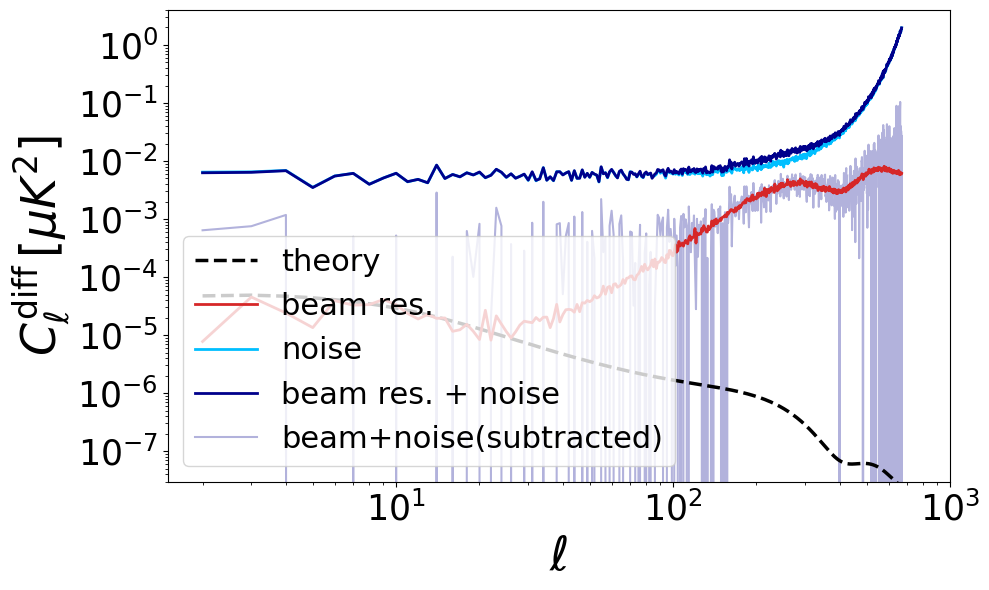

In [353]:
### PLOT FOR PAPER
fig = plt.figure( figsize=(10, 6))

#attempt of modeling beam residuals
plt.plot(lPLA, tau_arr[2:int(lPLA[-1]+1)]**2*ClPLA,color='black', ls='--', lw=2.5, label=r'theory')  #theoretical from PLA


#difference maps
#plt.plot(ll[2:], Cls_mapdiff_th[2:], color='lightgray', ls='-', lw=2.5 , label=r'ideal') #diff map - initial relaization
plt.plot(ll_cut[2:], Cls_map10[2:], color='tab:red', ls='-', lw=2, label=r'beam res.') #diff map - realistic beam
plt.plot(ll_cut[2:], Cls_map10symm_n[2:], color='deepskyblue', ls='-', lw=2, label=r'noise') #diff map - realistic beam
plt.plot(ll_cut[2:], Cls_map10_n[2:], color='darkblue', ls='-', lw=2, label=r'beam res. + noise') #diff map - realistic beam
plt.plot(ll_cut[2:], Cls_map10_n_[2:], color='darkblue', alpha=0.3, ls='-', lw=1.5, label=r'beam+noise(subtracted)', zorder=0)  # realistic beam + noise, with noise model subtraction


#fit_attempt=tau_arr[2:int(lPLA[-1]+1)]**2*ClPLA  +  lPLA**4*tau_arr[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='lightsteelblue', alpha=1., ls='-', zorder=0, lw=2.5, label=r'$\tau_{X_i}^2C_\ell^{\rm{CMB}}+ \tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

plt.ylim(3e-8, 4)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=22)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xlabel(r'$\ell$', fontsize=34)
plt.ylabel(r'$C_\ell^{\rm diff}\,[\mu K^2]$', fontsize=34) 

plt.tight_layout()

plt.savefig('ClsCMB.png',dpi=300, bbox_inches='tight',  format='png')

plt.savefig("/home/evanetti/BEAMS/paper_figures/Clsdiff_realbeam", dpi=300, bbox_inches="tight")

plt.show()

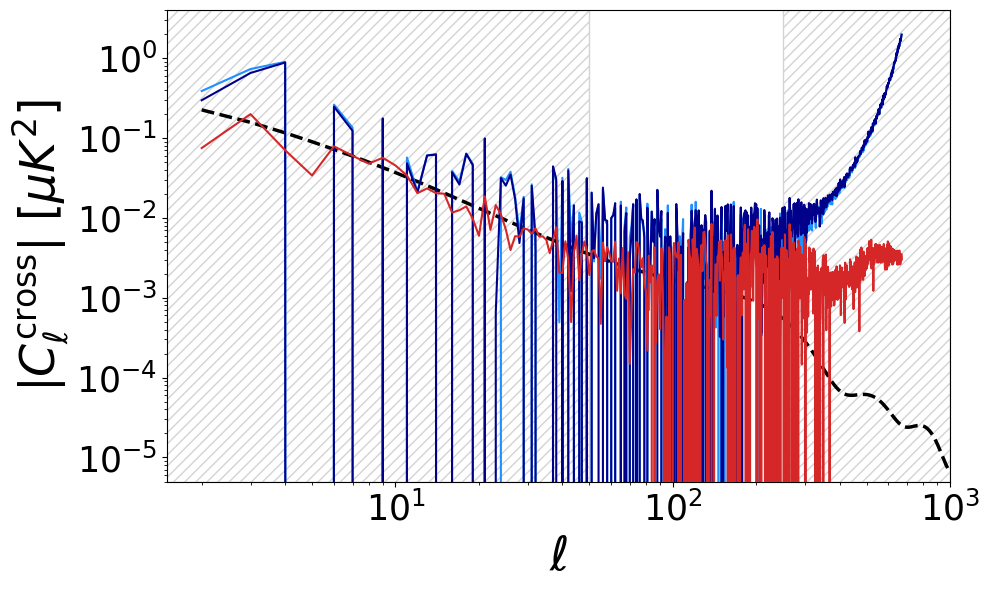

In [431]:
## PLOT FOR PAPER
fig = plt.figure( figsize=(10, 6))

#attempt of modeling beam residuals
plt.plot(lPLA, tau_arr[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls='--', lw=2.5, label=r'theory')  #theoretical from PLA


#difference maps
#plt.plot(ll_cut[2:], np.absolute(Cls_cross_th[2:]), color='lightgray', ls='-', lw=2.5 , label=r'ideal') #diff map - initial relaization
plt.plot(ll_cut[2:], -Cls_cross_real[2:], color='tab:red', ls='-', lw=1.5, label=r'beam res.', zorder=10) #diff map - realistic beam
plt.plot(ll_cut[2:], -Cls_cross_symm_n[2:], color='dodgerblue', ls='-', lw=1.5, label=r'noise') #diff map - realistic beam
plt.plot(ll_cut[2:], -Cls_cross_real_n[2:], color='darkblue', ls='-', lw=1.5, label=r'beam res. + noise') #diff map - realistic beam

plt.axvspan(0, 50, hatch='///', fill=False, edgecolor='lightgray')
plt.axvspan(250, 1e3, hatch='///', fill=False, edgecolor='lightgray')

#fit_attempt=tau_arr[2:int(lPLA[-1]+1)]**2*ClPLA  +  lPLA**4*tau_arrrr[2:int(lPLA[-1]+1)]**4*ClPLA
#plt.plot(lPLA, fit_attempt ,color='lightsteelblue', alpha=1., ls='-', zorder=0, lw=2.5, label=r'$\tau_{X_i}^2C_\ell^{\rm{CMB}}+ \tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}}$')  #theoretical from PLA

plt.ylim(5e-6, 4)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.yscale('log')
#plt.legend(fontsize=22)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.xlabel(r'$\ell$', fontsize=34)
plt.ylabel(r'$|C_\ell^{\rm{cross}}|\,\,[\mu K^2]$', fontsize=34) 

plt.tight_layout()

plt.savefig('ClsCMB.png',dpi=300, bbox_inches='tight',  format='png')


plt.savefig("/home/evanetti/BEAMS/paper_figures/Clscross_dash", dpi=300, bbox_inches="tight")

plt.show()

### Expected departure from theoretical Cls, due to noise only

Compute theoretical deconvolved Cls: $\quad C_l^{\rm{dec}}=C_l^{PLA}+C_l^N/C_l^b\quad$   
neglects accidental correlations between noise and CMB

Difference with ideal case: $\quad C_l^{\rm{dec}}-C_l^{PLA} = C_l^N/C_l^b$ $\qquad\qquad$ Relative difference: $\quad C_l^N/(C_l^b C_l^{PLA}) $ 

Result from smooth analytical spectra:
- large scales: the 70 GHz plot is above since the noise variance is higher
- small scales: the 30 GHz noise is higher becasue of the larger 30 GHz beam which boosts the noise more (beam Cls have lower amplitude at ell_cut)

Verified that the actual maps follow the same trend. Beam effects are subdominant. 


// At which $\ell$ the difference becomes larger than a certain threshold $th$?

$th$   $\qquad  10^{-4} \quad 10^{-3} \quad 5\times 10^{-3} \quad 10^{-2}$   
30 GHz: $\quad 17 \qquad  81 \qquad 216\qquad 256 $   
70 GHz:  $\quad 13 \qquad  58 \qquad 231\qquad 284 $  

DIFFERENCE MAP:  
Theoretical: $a_{\ell m}^{diff}=-\tau\, a_{\ell m}^{cmb} \quad\rightarrow\quad C_\ell^{diff}=\tau^2 C_\ell^{cmb(PLA)} $ 

With noise: $a_{\ell m}^{diff}=a_{\ell m}^{70, dec}-a_{\ell m}^{30, dec}=[(1-\tau)a_{\ell m}^{cmb}+a_{\ell m}^{N_2}/b_\ell^{70}]- [a_{\ell m}^{cmb}+a_{\ell m}^{N_1}/b_\ell^{30}] = -\tau a_{\ell m}^{cmb}+a_{\ell m}^{N_2}/b_\ell^{70} - a_{\ell m}^{N_1}/b_\ell^{30}$

$\longrightarrow \qquad C_\ell^{diff+N}=\tau^2 C_\ell^{cmb(PLA)}+C_\ell^{N_1}/C_\ell^{b70}+C_\ell^{N_2}/C_\ell^{b30}$ neglecting accidental correlation between CMB, N1 and N2

With noise and beam errors: there is a difference in the same area shown in plots above

<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:33: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10589/2196262102.py:33: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)
/tmp/ipykernel_10589/2196262102.py:35: SyntaxWarning: invalid escape sequence '\e'
  plt.title('rel. diff. from PLA due to deconvolved noise, $\ell_{max}=$'+str(lmax_cut0), fontsize=15)


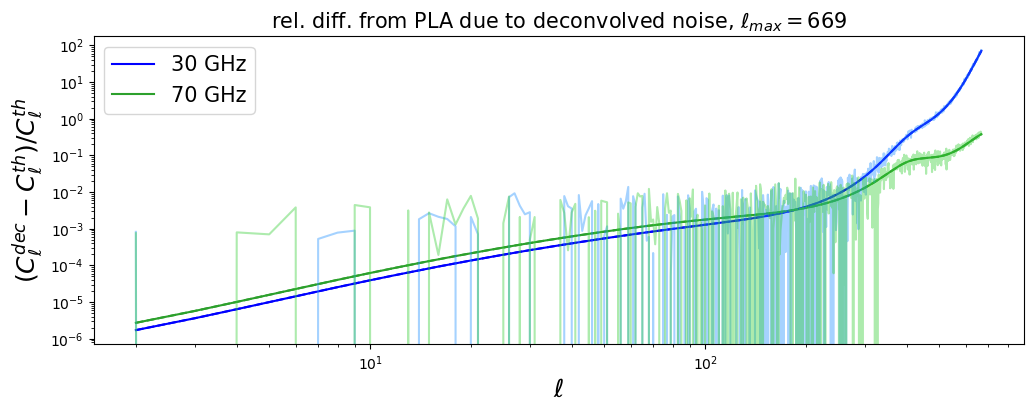

th= 0.0001 	 ll_cut_value= 13
th= 0.001 	 ll_cut_value= 58
th= 0.005 	 ll_cut_value= 231
th= 0.01 	 ll_cut_value= 284


In [ ]:
## deviation from theoretical Cls due to noise
# difference between: deconvolved Cls vs Cls PLA (expected) --> only accounts for difference due to noise
plt.figure(figsize=(12,4))

#theoretical case (smooth analytical spectra)
plt.plot(ll_cut[2:], (Cls0n_dec_th-ClPLA[:lmax_cut0-2])/ClPLA[:lmax_cut0-2] , color='blue', ls='-', label='30 GHz') # this neglects asymmetric beam effects. It's the deviation due to noise
plt.plot(ll_cut[2:], (Cls1n_dec_th-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] , color='tab:green', ls='-', label='70 GHz')
plt.plot(ll_cut[2:], Cls_noise0_dec_th[2:]/ClPLA[:lmax_cut0-2], color='blue', ls='--') 
plt.plot(ll_cut[2:], Cls_noise1_dec_th[2:]/ClPLA_xi[:lmax_cut0-2], color='tab:green', ls='--')


# symmetric beam + noise
plt.plot(ll_cut[2:], (Cls_map0symm_n_dec[2:lmax_cut0]-Cls_map_cmb[2:lmax_cut0])/Cls_map_cmb[2:lmax_cut0],color='dodgerblue', ls='-', alpha=0.4)
plt.plot(ll_cut[2:], (Cls_map1symm_n_dec[2:lmax_cut0]-Cls_map_xi[2:lmax_cut0])/Cls_map_xi[2:lmax_cut0],color='limegreen', ls='-', alpha=0.4)
plt.hlines(0,ll_cut[2], ll_cut[-1], color='k', alpha=0.7, ls='--')

# realistic beam + noise
#plt.plot(ll_cut[2:], (Cls_map0_n_dec[2:]-ClPLA[:lmax_cut0-2])/ClPLA[:lmax_cut0-2] , color='dodgerblue', ls='-', alpha=0.4) # this neglects asymmetric beam effects. It's the deviation due to noise
#plt.plot(ll_cut[2:], (Cls_map1_n_dec[2:]-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] , color='limegreen', ls='-', alpha=0.4)


#difference map: 
'''
Cls_diff_th=tau_arr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2]+Cls_noise0_dec_th[2:]+Cls_noise1_dec_th[2:]
plt.plot(ll_cut[2:], (Cls_noise0_dec_th[2:]+Cls_noise1_dec_th[2:])/(tau_arr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2]) , color='tab:red', ls='-', label='70-30 GHz diff.' )
plt.plot(ll_cut[2:],(Cls_map10symm_n[2:]-tau_arrrr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])/(tau_arrrr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])  , color='red', ls='-',alpha=0.4,  label='70-30 GHz diff.')
plt.plot(ll_cut[2:],(Cls_map10_n[2:]-tau_arr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])/(tau_arr[2:lmax_cut0]**2*ClPLA[:lmax_cut0-2])  , color='magenta', ls='-',alpha=0.4,  label='70-30 GHz diff.')
'''

plt.xscale('log')
plt.yscale('log')
#plt.yscale('symlog',  linthresh=1e-5)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^{dec}-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('rel. diff. from PLA due to deconvolved noise, $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()

## find ell at which deviation>threshold
thrs=1e-4
thrs_list=[1e-4, 1e-3, 5e-3, 1e-2]
for thrs in thrs_list:

    idx = np.where((Cls1n_dec_th-ClPLA_xi[:lmax_cut0-2])/ClPLA_xi[:lmax_cut0-2] > thrs)[0]
    if idx.size > 0:
        ll_cut_value = ll_cut[2 + idx[0]]
    else:
        ll_cut_value = None
    print('th=',thrs ,'\t ll_cut_value=', ll_cut_value)

# find at which ell the noise difference is larger than tau





### Compare: difference from $C_\ell^{\rm{PLA}}$ due to noise vs due to beam residuals

Compare with initial realization of each map 1) $C_\ell^{dec}$ with symm beam + noise  $\qquad$ 2) $C_\ell^{dec}$ with realistic beam, noiseless 

Case of beam residuals only: $a_{\ell m}^{\rm{dec}}=(1+\epsilon_{\ell m})a_{\ell m}^{\rm{th}}\quad\longrightarrow\quad C_\ell^{\rm{dec}}=|1+\epsilon_{\ell m}|^2 C_\ell^{\rm{th}} = (1+\langle\epsilon_{\ell m}\epsilon_{\ell m}^*\rangle + 2\rm{Re}\langle \epsilon_{\ell m} \rangle)C_\ell^{\rm{th}} $

The plots show:
- difference: $ $
- relative difference: $ $
 
true assuming: 1) zero correlation between beam residials and maps, 2) no mixing between different $\ell, m$ s 


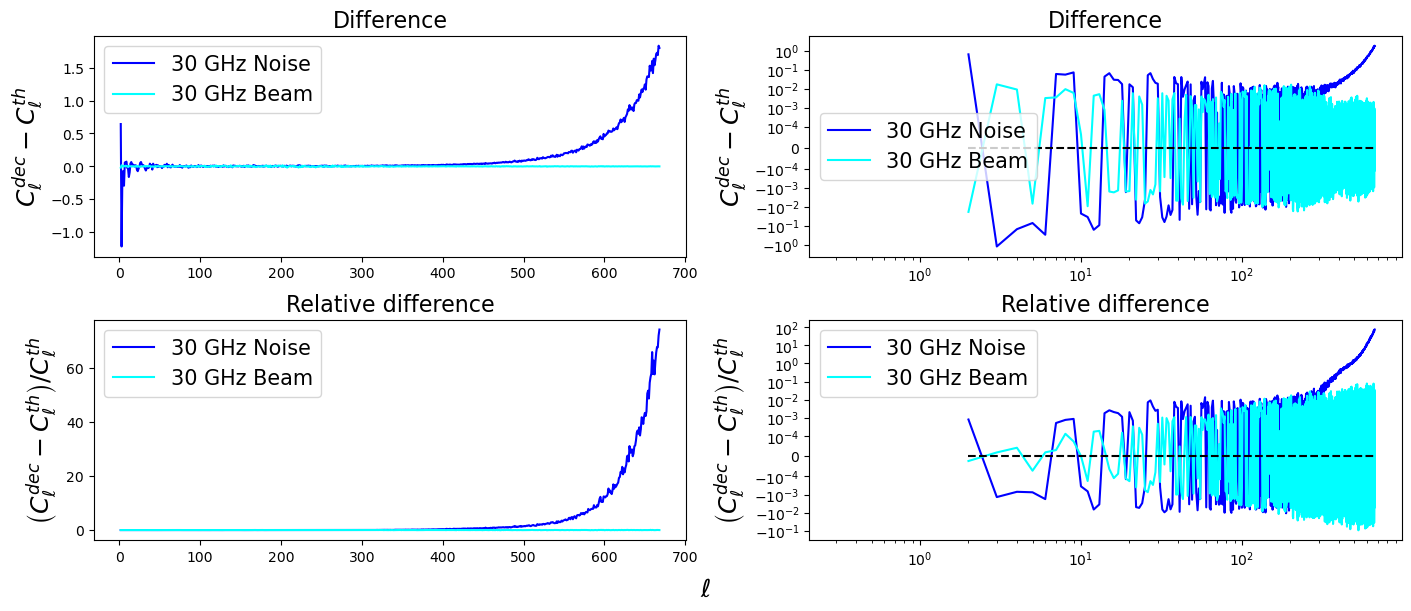

In [ ]:
## 30 GHz channel - DIFFERENCE from original realization - blue) deconvolved Cls with symm beam +  noise

lab_names=['th', 'dec'] #'- 30 GHz - realistic beam vs symmetric beam'
leg_names=['30 GHz Noise', '30 GHz Beam']
colors=['blue', 'cyan']
plot_diff([Cls_map_cmb, Cls_map_cmb], [Cls_map0symm_n_dec, Cls_map0_dec], 2, lmax_cut0, lab_names, leg_names, colors )

'\ncheck error in beam normalization\n\ntry to look at the alms directly\n\ncheck consistrency between epsilon_lm real part average and epslilon_lm squared (other notebook)\n'

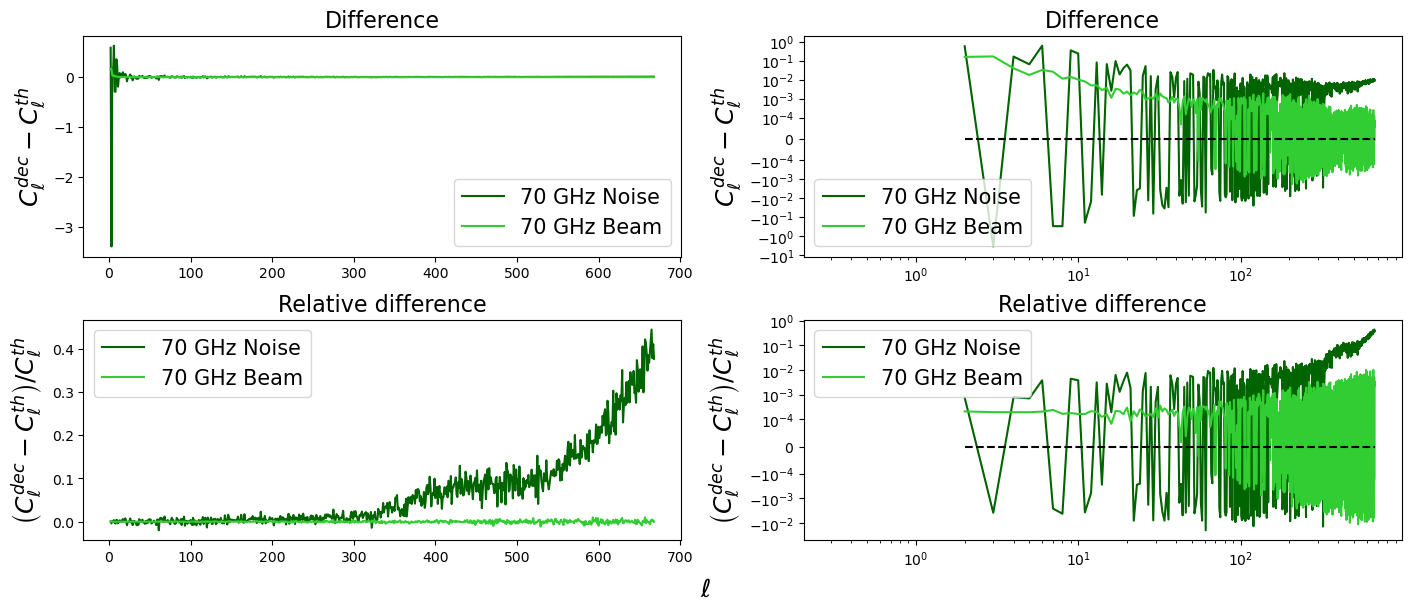

In [ ]:
## 70 GHz channel - DIFFERENCE from original realization - blue) deconvolved Cls with symm beam +  noise

lab_names=['th', 'dec'] #'- 30 GHz - realistic beam vs symmetric beam'
leg_names=['70 GHz Noise', '70 GHz Beam']
colors=['darkgreen', 'limegreen']
plot_diff([Cls_map_xi, Cls_map_xi],[Cls_map1symm_n_dec, Cls_map1_dec], 2, lmax_cut0, lab_names, leg_names, colors)

'''
check error in beam normalization

try to look at the alms directly

check consistrency between epsilon_lm real part average and epslilon_lm squared (other notebook)
'''

In [ ]:
##### CHECK DECONVOLUTION: deconvolve manually
lmax = 3 * nside - 1
print('lmax deconvolved maps = ', lmax, '\tlmax_beam=', len(Cls_beam0))
alm_map0_n = hp.map2alm(map0_n, lmax=lmax_cut0-1)
alm_map1_n = hp.map2alm(map1_n, lmax=lmax_cut0-1)

bl0=1/np.sqrt(Cls_beam0_cut)  #beam transfer functions
bl1=1/np.sqrt(Cls_beam1_cut)

alm_map0_n_dec= hp. almxfl(alm_map0_n,bl0, mmax=lmax_cut0-1)  ###POSSIBLE PROBLEM: lmax beam and alms from map is different
alm_map1_n_dec=hp.almxfl(alm_map1_n,bl1, mmax=lmax_cut0-1) 

map0_n_dec2=hp.alm2map(alm_map0_n_dec, nside=nside, lmax=lmax_cut0-1)
map1_n_dec2=hp.alm2map(alm_map1_n_dec, nside=nside, lmax=lmax_cut0-1)
map10_n_diff2=map1_n_dec2 - map0_n_dec2

#check Cls
Cls_map0_n_dec2=hp.anafast(map0_n_dec2, lmax=lmax_cut0-1)
Cls_map1_n_dec2=hp.anafast(map1_n_dec2, lmax=lmax_cut0-1)
Cls_diff2=hp.anafast(map10_n_diff2, lmax=lmax_cut0-1)

lmax deconvolved maps =  3071 	lmax_beam= 3072


In [ ]:
print(np.min(Cls_map0_n_dec2 - Cls_map0_n_dec), np.max(Cls_map0_n_dec2 - Cls_map0_n_dec))
print(np.min(Cls_map1_n_dec2 - Cls_map1_n_dec), np.max(Cls_map1_n_dec2 - Cls_map1_n_dec))

0.0 0.0
0.0 0.0


In [ ]:
## get alms
alm_map0_dec = hp.map2alm(map0_dec, lmax=lmax_cut0-1)
alm_map1_dec = hp.map2alm(map1_dec, lmax=lmax_cut0-1)
alm_10=hp.map2alm(map10, lmax=lmax_cut0-1)

alm_cmb=hp.map2alm(map_cmb, lmax=lmax_cut0-1)
alm_xi=hp.map2alm(map_xi, lmax=lmax_cut0-1)

In [ ]:
## check alm_xi:
alm_xi_=alm_cmb-hp.almxfl(alm_cmb,tau_arrrr[:lmax_cut0])
check=alm_xi_-alm_xi
print(np.min(check), np.max(check))

(-7.427940929005672e-09+0j) (6.38173958122934e-11+3.357933636011223e-11j)


## Beam residuals

1) compute $\epsilon_{\ell m}$ directly from $a_{\ell m}\!$ s of the convolved maps:  ${a_{\ell m}^{30,\rm{dec}}=a_{\ell m}^{\rm{CMB}}(1+\epsilon_{\ell m}^{30})}\quad,\quad a_{\ell m}^{70,\rm{dec}} = a_{\ell m}^{X_i}(1+\epsilon_{\ell m}^{70})\;\: \text{with} \;\: a_{\ell m}^{X_i}=(1-\tau_{\ell}) a_{\ell m}^{\rm{CMB}}$ 

- $\epsilon_{\ell m}^{30}= \frac{a_{\ell m}^{30,\rm{dec}}}{a_{\ell m}^{\rm{CMB}}}-1 \qquad \qquad \epsilon^{70}_{\ell m}= \frac{a_{\ell m}^{70,\rm{dec}}}{a_{\ell m}^{\rm{X}_i}}-1 $ 

- $| \epsilon_{\ell m}^{30}|^2 = \langle\epsilon_{\ell m}^{30\,*} \epsilon_{\ell m}^{30}\rangle $ is not the full 2-point correlation function, since there it should also have off-diagonal elements.

2) difference map residuals 

<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_10589/359419980.py:27: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$', fontsize=18)


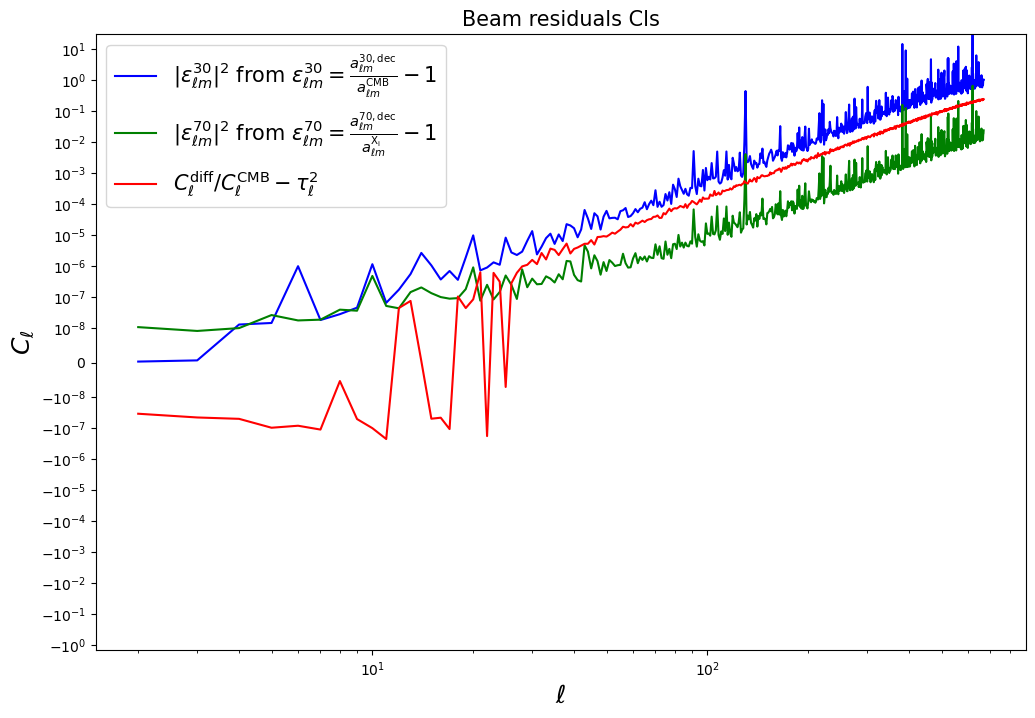

		 l=0 			 l=1 			 l=2
Cls_cmb th:  1.3288855834808194e-12 	 4.322476741658385e-15 	 783.0793573855366
Cls_diff:  1.47906435805216e-07 	 6.39584388402793e-08 	 7.758135628343198e-06


In [ ]:
epslm_0=alm_map0_dec/alm_cmb-1
epslm_1=alm_map1_dec/alm_xi-1

Cls_eps0 = hp.alm2cl(epslm_0)
Cls_eps1 = hp.alm2cl(epslm_1)


plt.figure(figsize=(12,8))
plt.plot(ll_cut[2:], Cls_eps0[2:] , color='blue', ls='-', label=r'$|\epsilon_{\ell m}^{30}|^2$ from $\epsilon_{\ell m}^{30}=\frac{a_{\ell m}^{30,\rm{dec}}}{a_{\ell m}^{\rm{CMB}}}-1 $') 
plt.plot(ll_cut[2:],Cls_eps1[2:] , color='green', ls='-', label=r'$|\epsilon_{\ell m}^{70}|^2$ from $\epsilon_{\ell m}^{70}= \frac{a_{\ell m}^{70,\rm{dec}}}{a_{\ell m}^{\rm{X}_i}}-1$') 

plt.plot(ll_cut[2:], Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0]-tau_arr[2:lmax_cut0]**2, color='red', ls='-',  label=r'$C_\ell^{\rm{diff}}/C_\ell^{\rm{CMB}}-\tau_\ell^2$') 
#plt.plot(ll_cut, Cls_map10/Cls_map_cmb[:lmax_cut0]-tau_arr[:lmax_cut0]**2, color='red', ls='-',  label=r'$C_\ell^{\rm{diff}}/C_\ell^{\rm{CMB}}-\tau_\ell^2$') 


#plt.plot(ll_cut, Cls_map10, color='magenta', ls='-', label=r'$C_\ell^{\rm{diff}} $')  

#plt.plot(ll_cut, Cls_map_cmb[:lmax_cut0], color='dodgerblue', ls='-', label=r'$C_\ell^{\rm{CMB-th}}$') 
# r'diff: $ |\epsilon_{lm}^1|^2 + |\epsilon_{lm}^0|^2 - 2\rm{Re}(\epsilon_{lm}^0\epsilon_{lm}^1) - 2\tau\rm{Re}(\delta\epsilon_{lm})$'
'''
plt.plot(ll_cut[2:], tau_arr[2:lmax_cut0]**2, color='black', ls='--', label=r'70 GHz $\tau_arr^2$') 
plt.plot(ll_cut[2:], tau_arr[2:lmax_cut0], color='gray', ls=':', label=r'70 GHz $\tau_arrrr$') 
'''
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-8)
#plt.ylim(-1e-6,40)
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell$', fontsize=18)
plt.title('Beam residuals Cls', fontsize=15)
plt.legend(fontsize=15)
plt.show()


print('\t\t l=0 \t\t\t l=1 \t\t\t l=2')
print('Cls_cmb th: ', Cls_map_cmb[0] ,'\t',Cls_map_cmb[1] , '\t', Cls_map_cmb[2] )
print('Cls_diff: ', Cls_map10[0] ,'\t',Cls_map10[1] , '\t', Cls_map10[2] )


## CROSS SPECTRUM

In [ ]:
Cl01cross=hp.anafast(map_diff, map0_dec, lmax=lmax_tau-1)     #THEORY
# BEAM ONLY
# NOISE ONLY
# BOTH


In [ ]:
#### other case with the right template: assuming to use CMB frequency independet anisotropies obtained with some component separation method. 

noise introduces a bias // 
noiseless results are not biased

### Check cross - Cls

In [ ]:
## compute cross-scpectrum (neede for matched filtering)
Cls_cross_th = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_cut0-1)
Cls_cross_real_n = hp.anafast(map10_n, map0_n_dec, lmax=lmax_cut0-1)
Cls_cross_real = hp.anafast(map10, map0_dec, lmax=lmax_cut0-1)
Cls_cross_symm_n = hp.anafast(map10symm_n, map0symm_n_dec, lmax=lmax_cut0-1)
Cls_cross_symm = hp.anafast(map10symm, map0symm_dec, lmax=lmax_cut0-1)

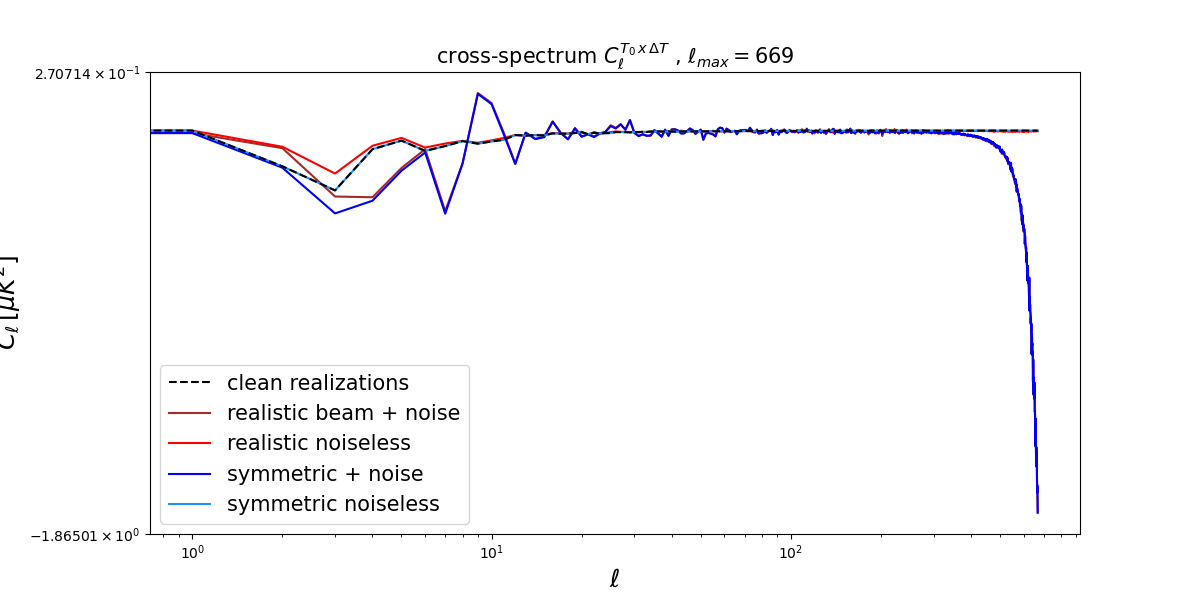

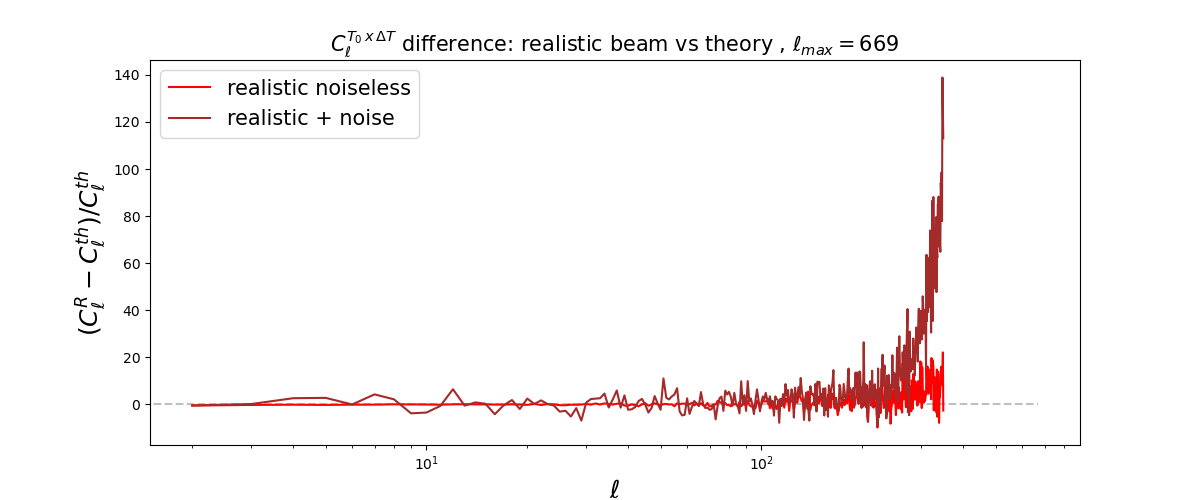

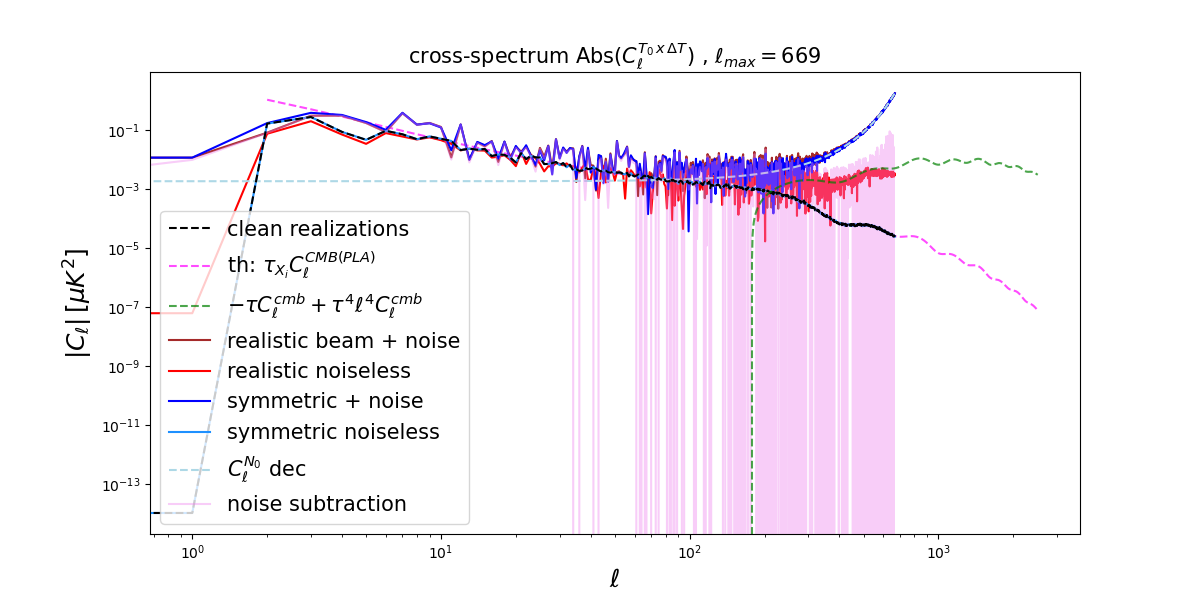

In [ ]:
# PLOT CROSS SPECTRA
plt.figure(figsize=(12,6))
plt.plot(ll_cut, Cls_cross_th, color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(ll_cut, Cls_cross_real_n, color='brown', ls='-',  label='realistic beam + noise') 
plt.plot(ll_cut, Cls_cross_real, color='red', ls='-',  label='realistic noiseless') 
plt.plot(ll_cut, Cls_cross_symm_n, color='blue', ls='-',  label='symmetric + noise') 
plt.plot(ll_cut, Cls_cross_symm, color='dodgerblue', ls='-',  label='symmetric noiseless') 

#plt.plot(ll_cut,  Cls_cross_real_n+Cls_noise0_dec_th, color='violet', ls='-',  label='noise subtraction') 


#plt.plot(ll_cut, Cls_map_noise0_dec, color='gray', ls='--',  label='30 GHz noise dec') 
#plt.plot(ll_cut, Cls_map_noise10_dec, color='gray', alpha=0.5, ls='-',  label='Diff. map noise dec') 


#plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum $C_\ell^{T_0\,x\,\Delta T}$ , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


#BEAM REASIDUALS: PLOT difference: realistic noiseless vs theory
cut2=350
plt.figure(figsize=(12,5))
plt.plot(ll_cut[2:cut2], (Cls_cross_real[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='red', ls='-', label='realistic noiseless', zorder=3) 
plt.plot(ll_cut[2:cut2], (Cls_cross_real_n[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='brown', ls='-', label='realistic + noise', zorder=3) 
plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
#plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^R-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('$C_\ell^{T_0\,x\,\Delta T}$ difference: realistic beam vs theory , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


### CHECK theoretical
plt.figure(figsize=(12,6))
plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

plt.plot(lPLA, (-tau_th+tau_th**4*lPLA**4)*ClPLA ,color='green', alpha=0.7,  ls='--', label=r'$-\tau C_\ell^{cmb}+\tau^4\ell^4C_\ell^{cmb}$', zorder=10)


plt.plot(ll_cut,  np.abs(Cls_cross_real_n), color='brown', ls='-',  label='realistic beam + noise') 
plt.plot(ll_cut,  np.abs(Cls_cross_real), color='red', ls='-',  label='realistic noiseless') 
plt.plot(ll_cut,  np.abs(Cls_cross_symm_n), color='blue', ls='-',  label='symmetric + noise') 
plt.plot(ll_cut,  np.abs(Cls_cross_symm), color='dodgerblue', ls='-',  label='symmetric noiseless') 

plt.plot(ll_cut,  Cls_noise0_dec_th, color='lightblue', ls='--',  label='$C_\ell^{N_0}$ dec') 

plt.plot(ll_cut,  np.abs(Cls_cross_real_n)-Cls_noise0_dec_th, color='violet', alpha=0.4, ls='-',  label='noise subtraction') 



#plt.plot(ll_cut, Cls_map10, color='green', ls='-',  label='70-30 GHz') 


plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|C_\ell|\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum Abs($C_\ell^{T_0\,x\,\Delta T}$) , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()



##plot Cls of Noise 1


### check that 


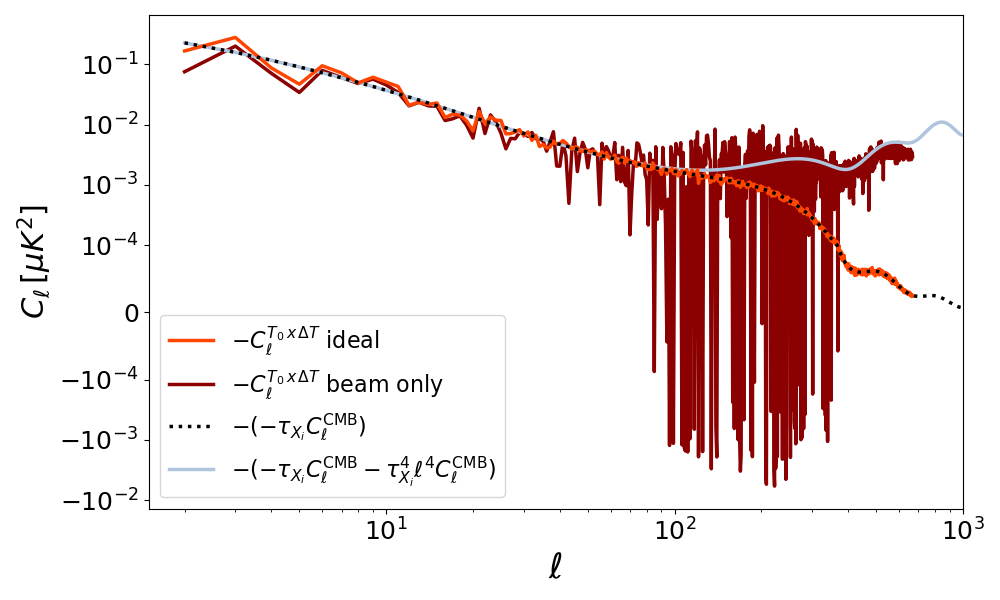

In [ ]:
### PLOT FOR PAPER
fig = plt.figure(figsize=(10, 6))

plt.plot(ll_cut[2:], -Cls_cross_symm[2:], color='orangered', ls='-', lw=2.5 , label=r'$-C_\ell^{T_0\,x\,\Delta T}$ ideal', zorder=9) # ideal 
plt.plot(ll_cut[2:], -Cls_cross_real[2:], color='darkred', ls='-', lw=2.5, label=r'$-C_\ell^{T_0\,x\,\Delta T}$ beam only') # realistic beam, noiseless
#plt.plot(ll_cut[2:], -Cls_cross_symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$ noise only')  #noise only, summ beam
#plt.plot(ll_cut[2:], -Cls_cross_real_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{T_0\,x\,\Delta T}$ realistic')  #realistic beam + noise
#plt.plot(ll_cut[2:], Cls_map10_n[2:]-Cls_noise10_dec_th[2:], color='navy', alpha=0.3, ls='-', lw=1.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$  realistic - noise ', zorder=0)  # realistic beam + noise, with noise model subtraction

#attempt of modeling beam residuals
#plt.plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='blue', ls=':',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT of beam res. modeling
plt.plot(lPLA, tau_arr[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls=':', lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}})$', zorder=10)  #theoretical from PLA

fit_attempt2=tau_arr[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4*tau_arr[2:int(lPLA[-1]+1)]**4*ClPLA
plt.plot(lPLA, fit_attempt2 ,color='lightsteelblue', alpha=1., ls='-', zorder=8, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''
fit_attempt3=tau_arr[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4.5*tau_arr[2:int(lPLA[-1]+1)]**4.5*ClPLA
plt.plot(lPLA, fit_attempt3 ,color='tab:purple', alpha=1., ls='-', zorder=7, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''

#plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')

plt.yscale('symlog', linthresh=1e-4)
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='lower left')
plt.tight_layout()

plt.savefig("/home/evanetti/BEAMS/paper_figures/Clscross.pdf", format="pdf", bbox_inches="tight")

plt.show()

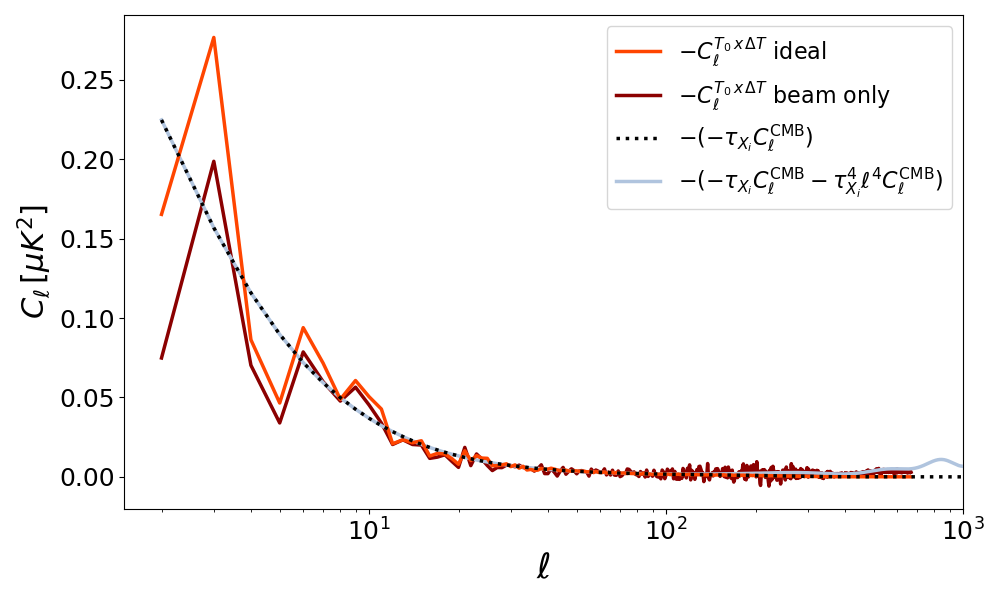

In [ ]:
### PLOT FOR PAPER
fig = plt.figure(figsize=(10, 6))
plt.plot(ll_cut[2:], -Cls_cross_symm[2:], color='orangered', ls='-', lw=2.5 , label=r'$-C_\ell^{T_0\,x\,\Delta T}$ ideal', zorder=9) # ideal 
plt.plot(ll_cut[2:], -Cls_cross_real[2:], color='darkred', ls='-', lw=2.5, label=r'$-C_\ell^{T_0\,x\,\Delta T}$ beam only') # realistic beam, noiseless
#plt.plot(ll_cut[2:], -Cls_cross_symm_n[2:], color='deepskyblue', ls='-', lw=2.5, label=r'$C_\ell^{T_0\,x\,\Delta T}$ noise only')  #noise only, summ beam
#plt.plot(ll_cut[2:], -Cls_cross_real_n[2:], color='darkblue', ls='--', lw=2.5,  label=r'$C_\ell^{T_0\,x\,\Delta T}$ realistic')  #realistic beam + noise


#attempt of modeling beam residuals
#plt.plot(ll_cut,  (tau_th**4)*(ll_cut**4)*Cls_map_cmb[:lmax_cut0], color='blue', ls=':',  label=r'$\tau^4\ell^4 C_l^{cmb}$')  ### ATTEMPT of beam res. modeling
plt.plot(lPLA, tau_arr[2:int(lPLA[-1]+1)]*ClPLA,color='black', ls=':', lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}})$', zorder=10)  #theoretical from PLA

fit_attempt2=tau_arr[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4*tau_arr[2:int(lPLA[-1]+1)]**4*ClPLA
plt.plot(lPLA, fit_attempt2 ,color='lightsteelblue', alpha=1., ls='-', zorder=8, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''
fit_attempt3=tau_arr[2:int(lPLA[-1]+1)]*ClPLA  +  lPLA**4.5*tau_arr[2:int(lPLA[-1]+1)]**4.5*ClPLA
plt.plot(lPLA, fit_attempt3 ,color='tab:purple', alpha=1., ls='-', zorder=7, lw=2.5, label=r'$-(-\tau_{X_i} C_\ell^{\rm{CMB}} -\tau_{X_i}^4 \ell^4 C_\ell^{\rm{CMB}})$')  #theoretical from PLA
'''

#plt.ylim(1e-9, 10)
plt.xlim(1.5, 1e3)
plt.xscale('log')
plt.xlabel('$\ell$', fontsize=25)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=22)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=16, loc='upper right')
plt.tight_layout()
plt.show()

Cross theoretical cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle a_{lm}^{cmb*}[(-\tau+\delta \epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle \delta\epsilon_{lm}\rangle C_l^{cmb}$ 


Cross deconvolved cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle [(1+\epsilon_{lm}^0)a_{lm}^{cmb}]^*[(-\tau+\delta\epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle\delta\epsilon_{lm}\rangle C_l^{cmb}-\tau\langle\epsilon_{lm}^0\rangle C_l^{cmb} +\langle\epsilon_{lm}^0\delta\epsilon_{lm}\rangle C_l^{cmb}$ 

--> dominant term: $\langle\epsilon_{lm}^0\delta\epsilon_{lm}\rangle C_l^{cmb}= (\langle  \epsilon_{lm}^0 \epsilon_{lm}^1\rangle - |\epsilon_{lm}^0|^2 ) C_l^{cmb} \sim - \tau^4 \ell^4 C_l^{cmb} $


Noisy case:

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=\langle [a_{lm}^{cmb}+N_1]^*[(-\tau+\delta\epsilon_{lm})a_{lm}^{cmb}+N_2-N_1]\rangle = -\tau C_l^{cmb} +\langle\delta\epsilon_{lm}\rangle C_l^{cmb}-C_\ell^{N_1}$ 

+ negliglible terms: $\langle N_2 a_{lm}^{cmb}\rangle+ \langle N_1a_{lm}^{cmb}\rangle-\tau\langle N_1a_{lm}^{cmb}\rangle+ \langle N_1N_2\rangle$        !! one of these seems to not be negliglible!!  Try all of these separately 

!! Include deconvolution in the calculation !!

- Symmetric beam, noiseless: $C_l^{T_0\times\delta T}=-\tau C_l^{cmb}$
- Symmetrci beam + noise: $C_l^{T_0\times\delta T}=-\tau C_l^{cmb}-C_\ell^{N_1}$
- Realistic beam, noiseless: $C_l^{T_0\times\delta T}=(-\tau +\langle\delta\epsilon_{lm}\rangle) C_l^{cmb}$
- Realistic beam + noise: $C_l^{T_0\times\delta T}=(-\tau +\langle\delta\epsilon_{lm}\rangle) C_l^{cmb}-C_\ell^{N_1}$



ERROR: ALSO THE 1ST MAP HAS BEAM RESIDUALS + deconvolution aplification is not considered 
- compare beam residuals before and after deconvolution
- compute beam residual difference from plot above 
- do the same as plot below but with theoretical CMB map ---> isolate actual delta epsilon

Isolate $\langle \delta \epsilon_{lm}\rangle$ from Cross Cls of relistic noiseless case: $\langle\delta\epsilon_{lm}\rangle =\tau+C_l^{T_0\times\delta T}/C_l^{cmb}$

1) why are the cross Cls beam residuals more scattered than in the difference map

2) residual behaviour on large scales 

3) noise subtraction: compute the average every 10 ells and see if it follows the right expected curve

4) see if the beam residuals model can be modified to include the beam residuals

5) rederive matched filtering eq. for this case + understand beam residuals better 

In [ ]:
## compute cross-scpectrum (neede for matched filtering)
Cls_cross_th_ = hp.anafast(mapdiff_th, map_cmb, lmax=lmax_cut0-1)
Cls_cross_real_ = hp.anafast(mapdiff_th, map0_dec, lmax=lmax_cut0-1)

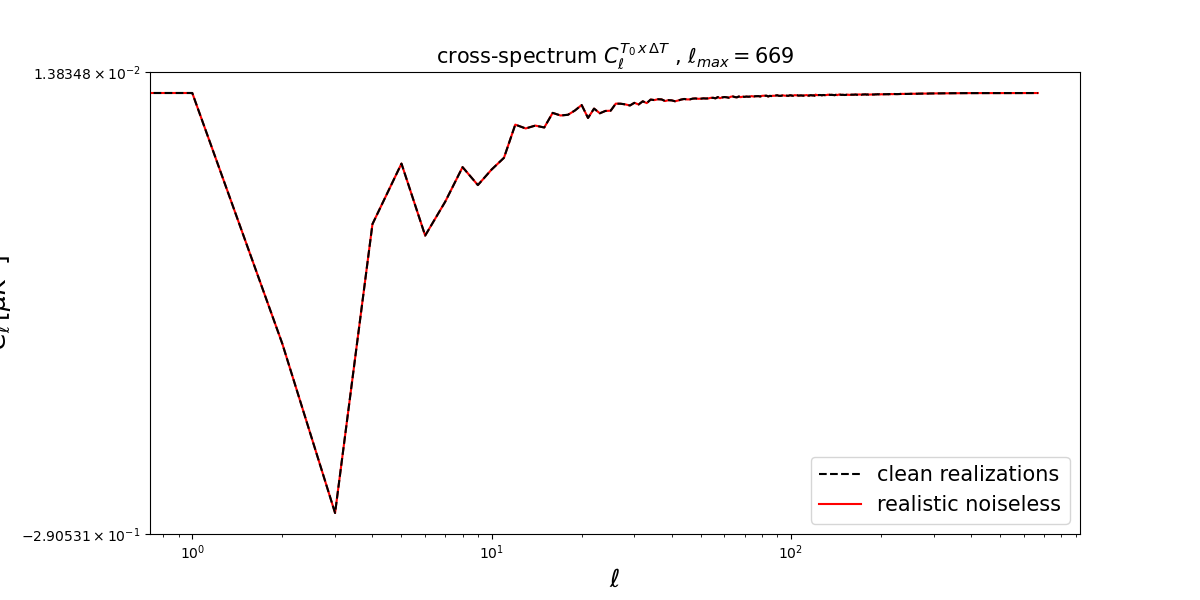

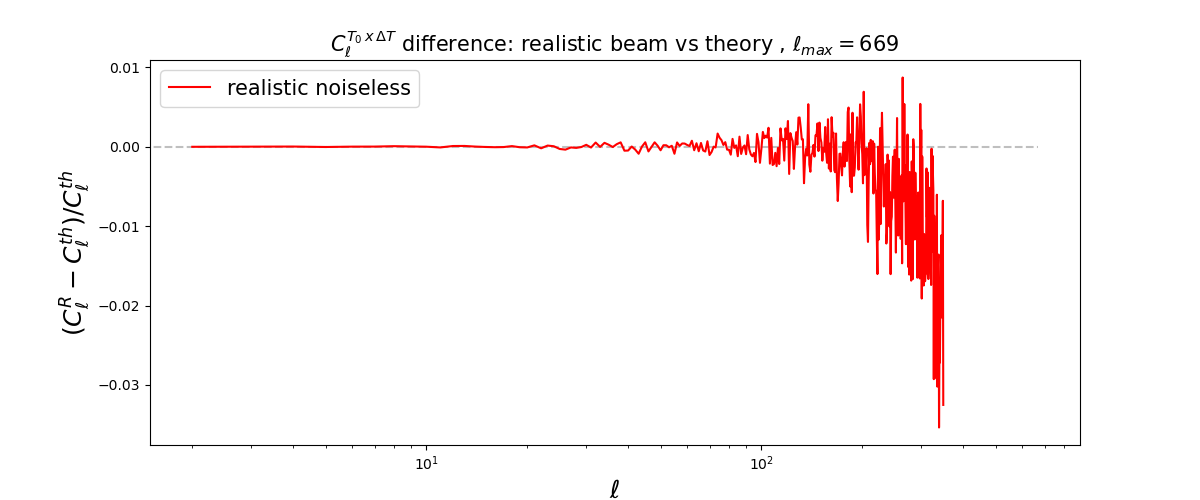

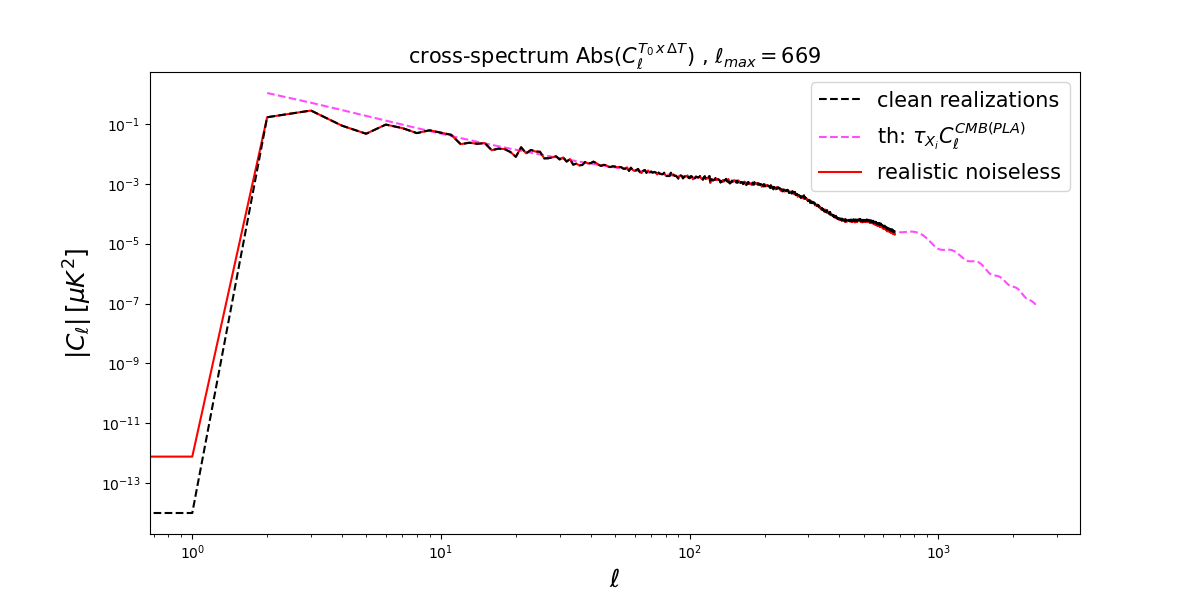

In [ ]:
# PLOT CROSS SPECTRA
plt.figure(figsize=(12,6))
plt.plot(ll_cut, Cls_cross_th, color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(ll_cut, Cls_cross_real_, color='red', ls='-',  label='realistic noiseless') 


#plt.plot(ll_cut,  Cls_cross_real_n+Cls_noise0_dec_th, color='violet', ls='-',  label='noise subtraction') 


#plt.plot(ll_cut, Cls_map_noise0_dec, color='gray', ls='--',  label='30 GHz noise dec') 
#plt.plot(ll_cut, Cls_map_noise10_dec, color='gray', alpha=0.5, ls='-',  label='Diff. map noise dec') 


#plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$C_\ell\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum $C_\ell^{T_0\,x\,\Delta T}$ , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


#BEAM REASIDUALS: PLOT difference: realistic noiseless vs theory
cut2=350
plt.figure(figsize=(12,5))
plt.plot(ll_cut[2:cut2], (Cls_cross_real_[2:cut2]-Cls_cross_th[2:cut2])/Cls_cross_th[2:cut2], color='red', ls='-', label='realistic noiseless', zorder=3) 
plt.hlines(0., ll_cut[0], ll_cut[-1], color='gray', alpha=0.5, ls='--', zorder=0)

plt.xscale('log')
#plt.yscale('symlog')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$(C_\ell^R-C_\ell^{th})/C_\ell^{th}$', fontsize=18)
plt.title('$C_\ell^{T_0\,x\,\Delta T}$ difference: realistic beam vs theory , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


### CHECK theoretical
plt.figure(figsize=(12,6))
plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

plt.plot(ll_cut,  np.abs(Cls_cross_real_), color='red', ls='-',  label='realistic noiseless') 

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|C_\ell|\,[\mu K^2]$', fontsize=18)
plt.title('cross-spectrum Abs($C_\ell^{T_0\,x\,\Delta T}$) , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


## BEAM residuals

In [ ]:
## isolated beam residuals: 
Cls_T0xdiff_th=hp.anafast(mapdiff_th, map0_dec, lmax=lmax_cut0-1)
Cls_T1xdiff_th=hp.anafast(mapdiff_th, map1_dec, lmax=lmax_cut0-1)

Cls_T0xT0_th=hp.anafast(map_cmb, map0_dec, lmax=lmax_cut0-1)
Cls_T1xT0_th=hp.anafast(map_cmb, map1_dec, lmax=lmax_cut0-1)


In [ ]:
## 30 GHz beam residuals averaged
#beam_res0=Cls_T0xdiff_th[2:]/(-tau_arr[2:lmax_cut0]*Cls_map_cmb[2:lmax_cut0])-1 #from diff map
beam_res0=Cls_T0xT0_th[2:]/Cls_map_cmb[2:lmax_cut0]-1 #from single map

#30 GHz beam residuals averaged
#beam_res1=(Cls_T1xdiff_th[2:]/Cls_map_cmb[2:lmax_cut0]+tau_arr[2:lmax_cut0]-tau_arr[2:lmax_cut0]**2)/(-tau_arr[2:lmax_cut0])
beam_res1=Cls_T1xT0_th[2:]/Cls_map_cmb[2:lmax_cut0]-1+tau_arr[2:lmax_cut0]


#squared residuals: 
beam_res0_sq=Cls_map0_dec/Cls_map_cmb[:lmax_cut0]-1
beam_res1_sq=Cls_map0_dec/Cls_map_cmb[:lmax_cut0]-1-tau_arr[:lmax_cut0]**2+2*tau_arr[:lmax_cut0]

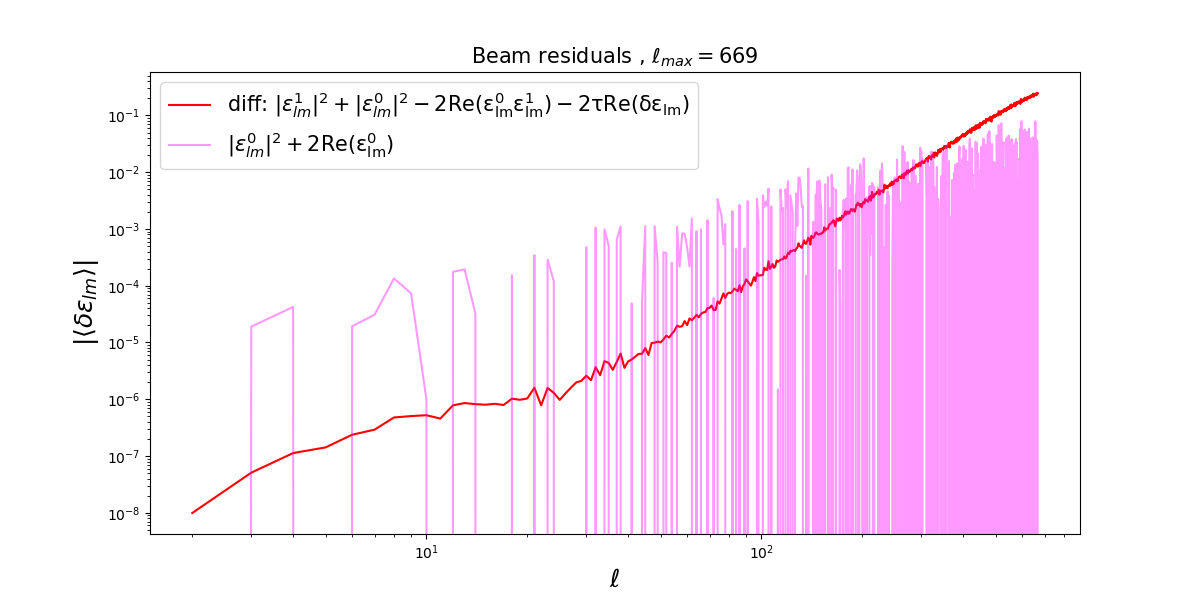

In [ ]:
plt.figure(figsize=(12,6))
#plt.plot(ll_cut, np.abs(Cls_cross_th), color='black', ls='--', label='clean realizations', zorder=3) 
#plt.plot(lPLA, tau_th*ClPLA,color='magenta', alpha=0.7,  ls='--', label=r'th: $\tau_{X_i}C_\ell^{CMB(PLA)}$')

beam_res_=tau_arr[:lmax_cut0]+Cls_cross_real_/Cls_map_cmb[:lmax_cut0] #cross Cls: ideal T0 x realistic diff
beam_res=tau_arr[:lmax_cut0]+Cls_cross_real/Cls_map_cmb[:lmax_cut0] #cross Cls: realistic T0 x realistic diff map
beam_res_diff=Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0]-tau_arr[2:lmax_cut0]**2 #realistic diff map

#plt.plot(ll_cut[2:], beam_res_[2:] , color='limegreen', ls='-',  label=r'cross_th: $\langle\epsilon_{lm}^1\rangle - \langle\epsilon_{lm}^0\rangle = \langle\delta\epsilon_{lm}\rangle $') 
#plt.plot(ll_cut[2:], -beam_res[2:]  , color='blue', ls='-', zorder=0,  label=r'cross: $-[- |\epsilon_{lm}^0|^2 + \langle  \epsilon_{lm}^0 \epsilon_{lm}^1\rangle + \langle\epsilon_{lm}^1\rangle - (1-\tau)\langle\epsilon_{lm}^0\rangle ]$') 

plt.plot(ll_cut[2:], Cls_map10[2:]/Cls_map_cmb[2:lmax_cut0], color='red', ls='-',  label=r'diff: $ |\epsilon_{lm}^1|^2 + |\epsilon_{lm}^0|^2 - 2\rm{Re}(\epsilon_{lm}^0\epsilon_{lm}^1) - 2\tau\rm{Re}(\delta\epsilon_{lm})$') 


#plt.plot(ll_cut[2:], beam_res1  , color='limegreen', ls='-',  label=r'$\langle\epsilon_{lm}^1\rangle$', zorder=6) 
#plt.plot(ll_cut[2:], - beam_res0  , color='orange', alpha=0.4, ls='-',  label=r'$- \langle\epsilon_{lm}^0\rangle$') 


#plt.plot(ll_cut[2:], beam_res1_sq[2:]  , color='magenta', ls='-',  label=r'$|\epsilon_{lm}^1|^2+2(1-\tau)\rm{Re}(\epsilon_{lm}^1)$') 
plt.plot(ll_cut[2:], beam_res0_sq[2:]  , color='magenta', alpha=0.4, ls='-',  label=r'$|\epsilon_{lm}^0|^2+2\rm{Re}(\epsilon_{lm}^0)$') 


#plt.plot(ll_cut[2:], (tau_th)**4*(ll_cut[2:])**4  , color='black', ls='--',  label=r'$\tau^4\ell^4 $') 
#plt.plot(ll_cut[2:], (tau_th)**5*(ll_cut[2:])**4  , color='gray', ls='--',  label=r'$\tau^5\ell^4 $') 


#plt.plot(ll_cut[2:], Cls_eps0[2:] , color='blue', ls='-', label='$|\epsilon_{lm}^0|^2$') 
#plt.plot(ll_cut[2:],Cls_eps1[2:] , color='green', ls='-', label='$|\epsilon_{lm}^1|^2$')
#plt.plot(ll_cut[2:],Cls_eps1[2:]+Cls_eps0[2:] , color='orange', ls='--', label='$|\epsilon_{lm}^0|^2+|\epsilon_{lm}^1|^2$')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('$\ell$', fontsize=18)
plt.ylabel(r'$|\langle\delta\epsilon_{lm}\rangle|$', fontsize=18)
plt.title('Beam residuals , $\ell_{max}=$'+str(lmax_cut0), fontsize=15)
plt.legend(fontsize=15)
plt.show()


Cross theoretical cmb map x realistic noiseless difference map: 

$C_l^{T_0\times\delta T}=\langle a_{lm}^{*0}\delta a_{lm}\rangle=
\langle a_{lm}^{cmb*}[(-\tau+\delta \epsilon_{lm})a_{lm}^{cmb}]\rangle = -\tau C_l^{cmb} +\langle \delta\epsilon_{lm}\rangle C_l^{cmb}$ 

# Noise subtraction 

Noise is amplified on small scales by the deconvolution: 
- noise of the deconvolved map: $C_\ell^{(N_1)\rm{dec}}=C_\ell^{N_1}/C_\ell^1$ (for both maps)
- noise of the difference map: $C_\ell^{(N_1+N_2)\rm{dec}}=C_\ell^{N_1}/C_\ell^1+C_\ell^{N_2}/b_\ell^2$


Strategies to remove noise: 
0) WIENER FILTER?? 
1) subtract $C_\ell^{(N_1+N_2)\rm{dec}}$ from the difference map 1) use noise estimate  2) use actual noise Cls  --> similar results: coincides with noiseless realistic case so I think the noise is subtracted correctly, even with the fitted model (neglects noise x signal correlation) 
 
2) subtract noise estimate from each deconvolved map, then take the difference $C_\ell^{(N_1)\rm{dec}}=C_\ell^{N_1}/b_\ell^1$
3) same as 1,2 but fit the noise with a constant and use that
4) subtract noise Cls before deconvolution (I don't think this will work)

Real case: 
- could subtract noise at the level of $C_\ell$s, like here
- could also subtract a noise map in advance. Then only noise residuals would get amolified 


DOUBT: how to model the noise Cls that go in the match filter if I subtract the noise? They should account for the noise residuals

PROBLEM?? why are the subtraction Cls not going to zero on large scales? They should


try: compute difference map from cleaned maps and then take the Cls

checked that $C_\ell^N/b_\ell$ is exactly the same as $C_\ell$ from the deconvolved noise map



data map: dm --> $C_\ell^m$ = data Cls

foreground template map: dS --> $C_\ell^S$ = foreground Cls

$\alpha=\frac{1}{f_{\rm{sky}}}\frac{\sum_\ell^{\ell_{\rm{max}}} (2\ell+1)C_\ell^{m\times S} / C_\ell^m }{\sum_\ell^{\ell_{\rm{max}}} C_\ell^s/C_\ell^m}$ 

### Code execution time in slurm

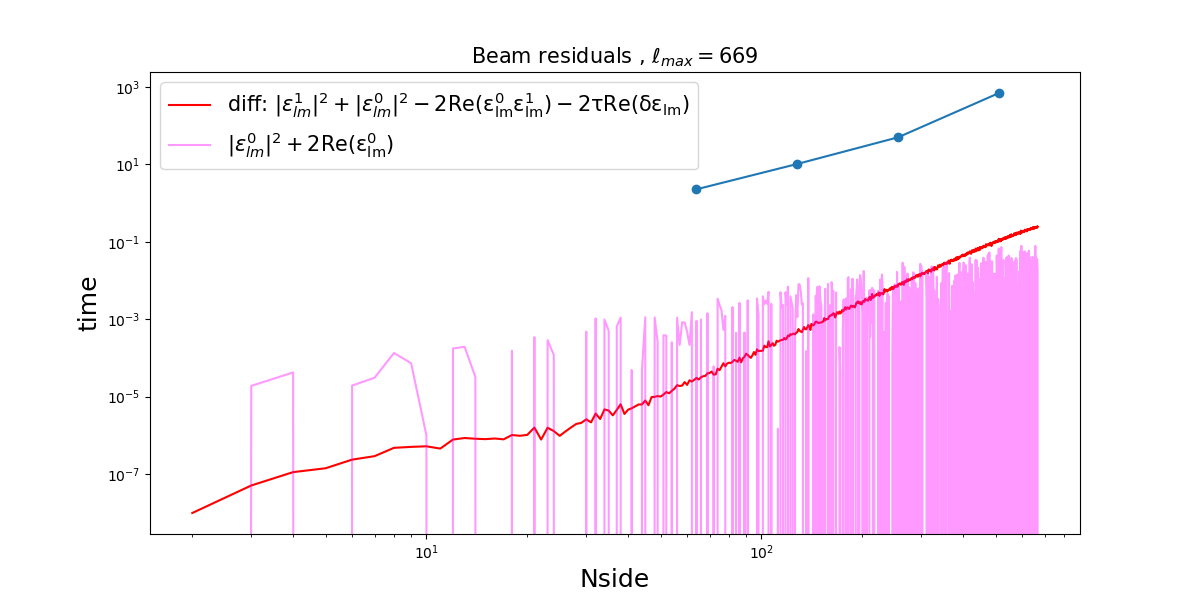

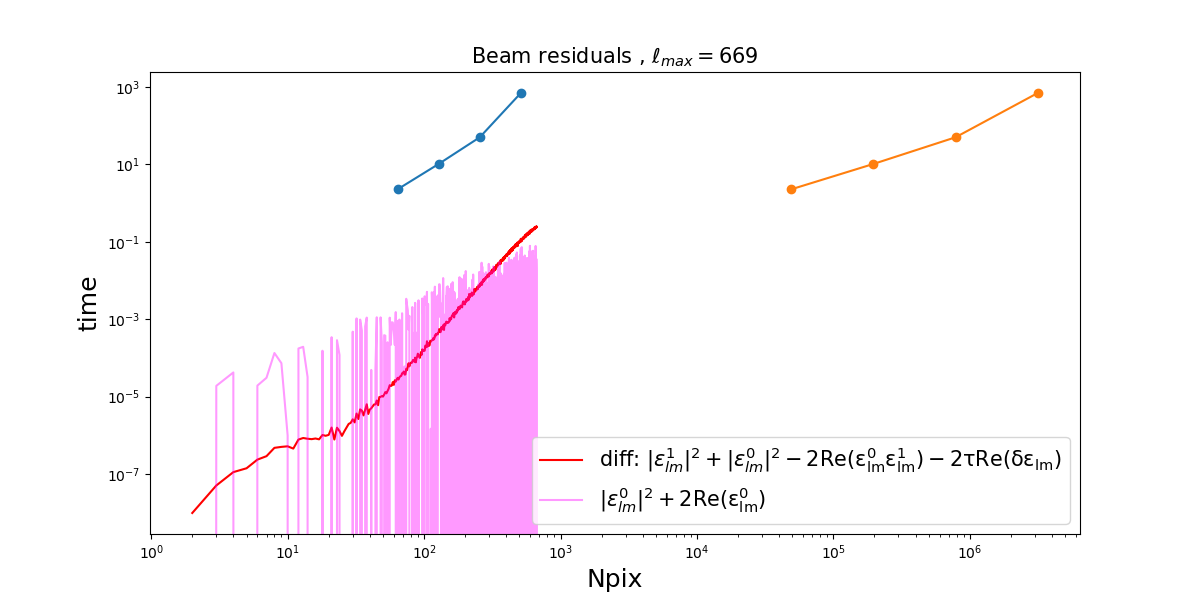

In [ ]:
## time for convolution loop - Ncores=10
#Nside=64   npix=49152      t=2.275 s       iteration time=4.628e-05    conv_test.o128551
#Nside=128  npix=196608     t=10.277 s      iteration time=5.227e-05    conv_test.o128421
#Nside=256  npix=786432     t=50.188 s      iteration time=6.381e-05     conv_test.o128423
#Nside=512  npix=12582912   t=      iteration time=

nside_run=np.array([64, 128, 256, 512, 1024])
npix=12*nside_run**2
time=np.array([2.275, 10.277, 50.188, 698.540, 0.0])

plt.plot(nside_run[:-1], time[:-1], marker='o')
plt.xlabel('Nside')
plt.ylabel('time')
plt.xscale('log')
plt.yscale('log')
plt.show()


plt.plot(npix[:-1], time[:-1], marker='o')
plt.xlabel('Npix')
plt.ylabel('time')
plt.xscale('log')
plt.yscale('log')
plt.show()